In [3]:
# Ran with predictors_simple kernel
# Python 3.10.8

import numpy as np # 1.26.4
import pandas as pd # 2.2.3
import tensorflow as tf # 2.10.0
import matplotlib # 3.10.3
import torch # 2.0.0

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.sans-serif'] = 'Arial'
from matplotlib import pyplot as plt

from joblib import load
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import auc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import re

import os
from tqdm import tqdm 

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_act import ADModel_act
from ADModel_abund import ADModel_abund
from ADModel_three_state import ADModel_three_state_abund
from ADModel_two_state import ADModel_two_state_abund
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode


os.chdir("/Users/claireleblanc/Documents/tools_software/adhunter")
from actpred.models import ActCNNSystem

# Set Numpy to display floats with 3 decimal places
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction")

In [4]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams['pdf.fonttype'] = 42

In [6]:
model_results = pd.read_csv('results/results_two_state_test_leakyrelu.csv')
model_results['seed'] = [int(re.search("seed(\d+)", model.removeprefix("../../"))[1]) for model in  model_results["model_name"]]
model_results['abund_k'] = [int(re.search("ak(\d+)", model.removeprefix("../../"))[1]) for model in  model_results["model_name"]]
# model_results = model_results[model_results['abund_k'] == 30]
model_results = model_results[(model_results['activity_fun'] == "Hill") & (model_results['hill_value'] == 1) & (model_results['negative_pen'] == 0.5)].drop_duplicates()

bootstrap_results = pd.read_csv('results/results_two_state_bootstraps_leakyrelu.csv')
bootstrap_results = bootstrap_results[bootstrap_results['activity_fun'] == "Hill"]
bootstrap_results['bootstrap_number'] = [int(re.search("BOOTSTRAP_(\d+)", model.removeprefix("../../"))[1]) for model in  bootstrap_results["model_name"]]
bootstrap_results['seed'] = [int(re.search("seed(\d+)", model.removeprefix("../../"))[1]) for model in  bootstrap_results["model_name"]]
bootstrap_results['abund_k'] = [int(re.search("ak(\d+)", model.removeprefix("../../"))[1]) for model in  bootstrap_results["model_name"]]

In [10]:
model_results

,model_name,model_type,kernel_size,activity_fun,negative_pen,weight_pen,hill_value,spearman_abund_test,spearman_act_test,spearman_abund_val,...,pearson_act_val,pearson_abund_train,pearson_act_train,K1_negative,K2_negative,abund_negative,relu,total_params,seed,abund_k
6,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,1,Hill,0.5,0.1,1,0.519428,0.770326,0.574596,...,0.761651,0.587565,0.766691,True,NaN,True,False,202,830655019,5
7,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,2,Hill,0.5,0.1,1,0.519428,0.776131,0.574596,...,0.796117,0.587565,0.789415,True,NaN,True,False,221,830655019,5
8,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,3,Hill,0.5,0.1,1,0.519428,0.787389,0.574596,...,0.809510,0.587565,0.806531,True,NaN,True,False,240,830655019,5
9,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,4,Hill,0.5,0.1,1,0.519428,0.771744,0.574596,...,0.745523,0.587565,0.766772,True,NaN,True,False,259,830655019,5
10,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,5,Hill,0.5,0.1,1,0.519428,0.765385,0.574596,...,0.793383,0.587565,0.797420,True,NaN,True,False,278,830655019,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,20,Hill,0.5,0.1,1,0.564631,0.766061,0.593873,...,0.763801,0.664159,0.784951,True,NaN,False,False,1228,1298091,40
722,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,25,Hill,0.5,0.1,1,0.564631,0.768517,0.593873,...,0.766969,0.664159,0.794732,True,NaN,False,False,1323,1298091,40
723,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,30,Hill,0.5,0.1,1,0.564631,0.770012,0.593873,...,0.778482,0.664159,0.828512,True,NaN,False,False,1418,1298091,40
724,../../model_data/two_state_abundmodel_b10_e200...,two_state_abund,35,Hill,0.5,0.1,1,0.564631,0.771321,0.593873,...,0.789762,0.664159,0.826636,True,NaN,False,False,1513,1298091,40


In [9]:
# Running the two-state biophysical model on the data

# Biophysical model parameters
size = (1,40,20)
hill_value = 1
relu = False
# relu = True
outchannel = 1

# Function to read in weights
def load_model_get_weights(row, layer1='conv1.weight', layer2="linear1.weight", two_state=False, abund_k = False): 
    """
    Parameters
    ----------

    row : row of results data frame
    layer1 : name of convolutional layer
    layer2 : name of linear layer
    two_state : whether this is a simple or two state model (TO DO: ADD abundance)
    abund_k : if this is two state, whether we are reading in the abundance weights
    """

    model = row["model_name"].removeprefix("../../")
    kernel_size = row["kernel_size"]

    if two_state: 
        abund_k_two = row["abund_k"]
        activity_fun = row["activity_fun"]
        loaded_model = ADModel_two_state_abund(size,activity_fun, kernel_size, relu=relu, abund_k=abund_k_two)
    else: 
        loaded_model = ADModel_abund(size, kernel_size)
    loaded_model.load_state_dict(torch.load(f"{model}.pth"))

    loaded_model.eval()
    model_state_dict = loaded_model.state_dict()
    width = model_state_dict[layer1].shape[0] * model_state_dict[layer1].shape[2]
    conv_weight = model_state_dict[layer1].detach().numpy().reshape(width,20)

    if abund_k:
        linear_weights_size = (40 - abund_k_two + 1)
    else:
        linear_weights_size = (40 - kernel_size + 1)
    linear_weights = model_state_dict[layer2].detach().numpy().reshape(linear_weights_size)

    return loaded_model, conv_weight, linear_weights

def get_weights_array(results_table, k_size, num_bootstraps=25, num_seeds=30, two_state=False, layer1=None, layer2=None, abund_k=False):
    """
    After we read in our weights, we want to store them in a numpy array where:
    - first dimension = number of shuffles
    - second dimension = number of seeds
    - third/fourth dimension = shape of the weights
    """

    # Defining our table of interest: If we want to look at the abundance weights
    if abund_k:
        index_col = 'abund_k'
    else:
        index_col = 'kernel_size'
    results_table = results_table[results_table[index_col] == k_size].copy()
    
    # Creating arrays to save weights
    conv_weight_arr = np.zeros((num_bootstraps, num_seeds, k_size, 20))
    linear_weight_arr = np.zeros((num_bootstraps, num_seeds, (40 - k_size + 1)))

    # If there is more than one bootstrap (i.e. not real weights), sort by bootstrap number and seed
    # Else sort by seeds
    if num_bootstraps > 1:
        results_table = results_table.sort_values(["seed", "bootstrap_number"]).reset_index()
        seeds_dict = {s : {a : i} for i, (s, a) in enumerate(results_table[['seed', 'abund_k']].drop_duplicates().values)}
    else:
        results_table = results_table.sort_values("seed").reset_index()

        # Assign an index to each seed
        # THIS IS NOT WORKING 
        seeds_dict = {}
        for i, (s, a) in enumerate(zip(results_table['seed'], results_table['abund_k'])): 
            if s in seeds_dict.keys():
                curr_dict = seeds_dict[s]
                if a in curr_dict.keys():
                    print(curr_dict)
                    print(a, i)
                    print("Uh oh")
                else: 
                    curr_dict[a] = i
            else:
                seeds_dict[s] = {a : i}

    # Loop through every model in the table of the correct size
    for index in tqdm(results_table.index):

        # Get correct row
        row = results_table.loc[index]
        
        # Check if there is a bootstrap column
        if num_bootstraps > 1:    
            shuffle_number = row['bootstrap_number']
        else:
            shuffle_number = 1
        
        if shuffle_number > num_bootstraps:
            print("here")
            break

        # Get seed index
        seed_index = seeds_dict[row['seed']][row['abund_k']]
        
        # Default to conv1 and linear1
        if (layer1 == None) and (layer2 == None):
            _, weights, linear_weights = load_model_get_weights(row, two_state=two_state)

        # Can pass specific layers
        else:
            _, weights, linear_weights = load_model_get_weights(row, layer1, layer2, two_state=two_state, abund_k=abund_k)

        # Save in the correct array 
        # First dim : bootstrap
        # Second dim : Seed
        # Third/fourth dim : Weights
        conv_weight_arr[shuffle_number -1, seed_index, :, :] = weights #.reshape(100, )
        linear_weight_arr[shuffle_number - 1, seed_index, :] = linear_weights

    return conv_weight_arr, linear_weight_arr

# Need to define our test statistics

# A. Cosine similarity between weights
# def cosine_similarity(shuffled_conv_arr, real_conv_arr, real_linear_arr):
#     num_shuffles, num_seeds, kernel_size, aa_nums = shuffled_conv_arr.shape
#     # aa_num = 1

#     num_iterations = int(num_seeds * (num_seeds-1) / 2)
#     shuffle_cos_similarities = np.zeros((num_shuffles, num_iterations, aa_nums))
    

#     for aa in range(aa_nums): 
#         for shuffle_num in range(num_shuffles):
#             a = 0
#             for i in range(num_seeds - 1):
#                 for j in range(i+1, num_seeds):
#                     vector1 = shuffled_conv_arr[shuffle_num, i, :, aa]#.flatten()
#                     vector2 = shuffled_conv_arr[shuffle_num, j, :, aa]#.flatten()
                    
#                     sim = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))  
#                     shuffle_cos_similarities[shuffle_num, a, aa] = sim
#                     a += 1


#     similarities_real = np.zeros((1, 435, aa_nums))

#     # Which seeds had negative weights
#     neg_weight_filter = (real_linear_arr > 0).all(axis=2)

#     # Options: Flip sign or analyze separately
#     real_conv_arr_flipped = real_conv_arr.copy()
#     real_conv_arr_flipped[~ neg_weight_filter, :, :] = -1 * real_conv_arr_flipped[~ neg_weight_filter, :, :]

#     for aa in range(aa_nums): 
#         a=0
#         for i in range(num_seeds - 1):
#             for j in range(i+1, num_seeds):
#                 vector1 = real_conv_arr_flipped[0, i, :, aa] #.flatten()
#                 vector2 = real_conv_arr_flipped[0, j, :, aa] #.flatten()
                
#                 sim = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))  
#                 similarities_real[0, a, aa] = sim
#                 a+=1
        
#     return shuffle_cos_similarities, similarities_real


# B. Sum of weights
def weight_sum(shuffled_conv_arr, real_conv_arr, real_linear_arr):
    num_shuffles, num_seeds, kernel_size, aa_nums = shuffled_conv_arr.shape
    # aa_num = 1

    shuffled_row_sums = shuffled_conv_arr[:, :, :, :].sum(axis=2)

    # Which seeds had negative weights
    neg_weight_filter = (real_linear_arr > 0).all(axis=2)
    print(neg_weight_filter)

    # Options: Flip sign or analyze separately
    real_conv_arr_flipped = real_conv_arr.copy()
    real_conv_arr_flipped[~ neg_weight_filter, :, :] = -1 * real_conv_arr_flipped[~ neg_weight_filter, :, :]
    shuffled_real_sums = real_conv_arr_flipped[:, :, :, :].sum(axis=2)

    return shuffled_row_sums, shuffled_real_sums

# PLOTTING FUNCTIONS
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Blue, White, Red
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Looking at the weight sums for K=5 --> Repeat for all convolutional filters
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}


def boxplot_linear_weights(seed_linear_arr, bootstrap_linear_arr):
    fig, ax = plt.subplots(figsize=(5, 2.5))

    # For varried seed
    bplot1 = ax.boxplot(seed_linear_arr[0],
                        widths=0.3,
                        positions=np.arange(0.85, bootstrap_linear_arr.shape[-1] + .85, 1),
                        patch_artist=True, 
                        boxprops=dict(facecolor='orange', color='orange'), 
                        flierprops=dict(markersize=2, marker='.'),
                        medianprops=dict(color='black'), 
                        label="")

    # For varried 
    bplot2 = ax.boxplot(bootstrap_linear_arr[:, 0], 
                        widths=0.3,
                        positions=np.arange(1.15, bootstrap_linear_arr.shape[-1] + 1.15, 1), 
                        patch_artist=True, 
                        boxprops=dict(facecolor='teal', color='teal'), 
                        flierprops=dict(markersize=2, marker='.'), 
                        medianprops=dict(color='black')
                        )

    ax.set_ylabel("Linear weight")
    ax.hlines(0, 0.5, 1.5, color='black', linestyles='--')

    ax.set_xticks(np.arange(1, bootstrap_linear_arr.shape[-1] + 1, 2), np.arange(1, bootstrap_linear_arr.shape[-1] + 1, 2))

    sns.despine()

def boxplot_conv_weights(seed_test_stat_arr, bootstrap_test_stat_arr):

    fig, ax = plt.subplots(figsize=(5, 2.5))

    means = np.mean(seed_test_stat_arr, axis=1)
    sorted_indicies = np.argsort(means)[0]

    # For varried seed
    bplot1 = ax.boxplot(seed_test_stat_arr.squeeze(0)[:, sorted_indicies],
                        patch_artist=True, 
                        boxprops=dict(facecolor='orange', color='orange'), 
                        flierprops=dict(markersize=2, marker='.'),
                        medianprops=dict(color='black'))

    # For varried 
    bplot2 = ax.boxplot(bootstrap_test_stat_arr.squeeze(1)[:, sorted_indicies], 
                positions=np.arange(1.5, 21.5, 1), 
                patch_artist=True, 
                boxprops=dict(facecolor='teal', color='teal'), 
                flierprops=dict(markersize=2, marker='.'), 
                medianprops=dict(color='black')
                )

    new_order = [aa_order[i] for i in sorted_indicies]
    ax.set_xticks(range(1, 21), new_order)

    for xtic in ax.get_xticklabels():
        if xtic.get_text() in colors.keys(): 
            xtic.set_color(colors[xtic.get_text()])

    ax.set_ylabel("Convolutional filter weight sum")
    ax.hlines(0, 0.5, 20.5, color='black', linestyles='--')

    sns.despine()

def seed_conv_confidence_interval_plot(seed_conv_arr):
    low = np.percentile(seed_conv_arr, (100-95)/2, axis=1)
    median = np.mean(seed_conv_arr,axis=1)
    high = np.percentile(seed_conv_arr, 100- (100-95)/2, axis=1)

    mean = np.mean(seed_conv_arr,axis=1)
    variance = np.var(seed_conv_arr, axis=1)

    print(mean.shape, variance.shape)
    lim = 1
    fig, axs = plt.subplots(1, 3, figsize=(10, 10), sharey=True)
    im1 = axs[0].imshow(low.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    axs[1].imshow(median.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    axs[2].imshow(high.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)

    # im1 = axs[0].imshow((mean - variance).squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    # axs[1].imshow(mean.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    # axs[2].imshow((mean + variance).squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)

    axs[0].set_yticks(range(len(aa_order)), aa_order)  # Label x-axis with column names


    for ytic in axs[0].get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])

    axs[0].tick_params(axis='x', which='major', labelsize=15) 
    axs[0].tick_params(axis='y', which='major', labelsize=15) 

    axs[1].tick_params(axis='x', which='major', labelsize=15)
    axs[2].tick_params(axis='x', which='major', labelsize=15)

    fig.colorbar(im1, ax=axs, location='bottom')

def bootstrap_conv_confidence_interval_plot(boostrap_conv_arr):
    low = np.percentile(boostrap_conv_arr, (100-95)/2, axis=0)
    mean = np.mean(boostrap_conv_arr,axis=0)
    high = np.percentile(boostrap_conv_arr, 100- (100-95)/2, axis=0)

    lim = 1
    fig, axs = plt.subplots(1, 3, figsize=(10, 10), sharey=True)
    im1 = axs[0].imshow(low.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    axs[1].imshow(mean.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    axs[2].imshow(high.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)

    axs[0].set_yticks(range(len(aa_order)), aa_order)  # Label x-axis with column names


    for ytic in axs[0].get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])

    axs[0].tick_params(axis='x', which='major', labelsize=15) 
    axs[0].tick_params(axis='y', which='major', labelsize=15) 

    axs[1].tick_params(axis='x', which='major', labelsize=15)
    axs[2].tick_params(axis='x', which='major', labelsize=15)

    fig.colorbar(im1, ax=axs, location='bottom')




In [12]:
def run_analysis(k, seed=None, outfile_name = ""):
    seed_conv_arr, seed_linear_arr = get_weights_array(model_results, k_size=k, num_bootstraps=1, num_seeds=60, two_state=True, abund_k=False)

    if seed is not None: 
        boostrap_conv_arr, bootstrap_linear_arr = get_weights_array(bootstrap_results[bootstrap_results['seed'] == seed], k_size=k, num_bootstraps=200, num_seeds=1, two_state=True, abund_k=False)
    else:
        boostrap_conv_arr, bootstrap_linear_arr = get_weights_array(bootstrap_results, k_size=k, num_bootstraps=200, num_seeds=1, two_state=True, abund_k=False)

    np.save(f"saved_weights/two_state_{outfile_name}_bootstrap_conv_arr.npy", boostrap_conv_arr)
    np.save(f"saved_weights/two_state_{outfile_name}_bootstrap_linear_arr.npy", bootstrap_linear_arr)

    bootstrap_test_stat_arr = boostrap_conv_arr.sum(axis=2) 
    seed_test_stat_arr = seed_conv_arr.sum(axis=2)

    print("Bootstrap variance", np.var(boostrap_conv_arr, axis=0).mean())
    print("Seed variance", np.var(seed_conv_arr, axis=1).mean())

    # PLOTTING THE LINEAR WEIGHTS
    boxplot_linear_weights(seed_linear_arr, bootstrap_linear_arr)
    plt.savefig(f"figures/for_revision/{outfile_name}_two_state_boxplot_linear_weights.pdf", format='pdf', bbox_inches='tight')
    
    # Plotting boxplot for conv weight sum
    boxplot_conv_weights(seed_test_stat_arr, bootstrap_test_stat_arr)
    plt.savefig(f"figures/for_revision/{outfile_name}_two_state_boxplot_conv_weights.pdf", format='pdf', bbox_inches='tight')

    # Plotting 95% CI
    seed_conv_confidence_interval_plot(seed_conv_arr)
    plt.savefig(f"figures/for_revision/{outfile_name}_two_state_seed_conv_percentile.pdf", format='pdf', bbox_inches='tight')

    # Plotting 95% CI
    bootstrap_conv_confidence_interval_plot(boostrap_conv_arr)
    plt.savefig(f"figures/for_revision/{outfile_name}_two_state_bootstrap_conv_percentile.pdf", format='pdf', bbox_inches='tight')


In [152]:
# Need to reformat to work with repeated seeds but diff abund kernels
seed_conv_arr, seed_linear_arr = get_weights_array(model_results, k_size=5, num_bootstraps=1, num_seeds=60, two_state=True, abund_k=False)

boostrap_conv_arr, bootstrap_linear_arr = get_weights_array(bootstrap_results, k_size=5, num_bootstraps=200, num_seeds=1, two_state=True, abund_k=False)

100%|██████████| 200/200 [00:00<00:00, 382.93it/s]


In [14]:
k = 5

seed_conv1_arr, seed_linear1_arr = get_weights_array(model_results, k_size=k, num_bootstraps=1, num_seeds=60, two_state=True, abund_k=False, layer1='conv1.weight', layer2='linear1.weight')
# seed_conv2_arr, seed_linear2_arr = get_weights_array(model_results, k_size=k, num_bootstraps=1, num_seeds=60, two_state=True, abund_k=False, layer1='conv2.weight', layer2='linear2.weight')

# if seed is not None: 
#     boostrap_conv1_arr, bootstrap_linear1_arr = get_weights_array(bootstrap_results[bootstrap_results['seed'] == seed], k_size=k, num_bootstraps=200, num_seeds=1, two_state=True, abund_k=False, layer1='conv1.weight', layer2='linear1.weight')
#     boostrap_conv2_arr, bootstrap_linear2_arr = get_weights_array(bootstrap_results[bootstrap_results['seed'] == seed], k_size=k, num_bootstraps=200, num_seeds=1, two_state=True, abund_k=False, layer1='conv2.weight', layer2='linear2.weight')
# else:
#     boostrap_conv1_arr, bootstrap_linear1_arr = get_weights_array(bootstrap_results, k_size=k, num_bootstraps=200, num_seeds=1, two_state=True, abund_k=False, layer1='conv1.weight', layer2='linear1.weight')
#     boostrap_conv2_arr, bootstrap_linear2_arr = get_weights_array(bootstrap_results, k_size=k, num_bootstraps=200, num_seeds=1, two_state=True, abund_k=False, layer1='conv2.weight', layer2='linear2.weight')

# Calculating test stat array for K1
# bootstrap1_test_stat_arr = boostrap_conv1_arr.sum(axis=2) 
seed1_test_stat_arr = seed_conv1_arr.sum(axis=2)

# Calculating test stat array for K2
# bootstrap2_test_stat_arr = boostrap_conv2_arr.sum(axis=2) 
# seed2_test_stat_arr = seed_conv2_arr.sum(axis=2)

100%|██████████| 60/60 [00:00<00:00, 506.81it/s]


(array([6.000, 8.000, 14.000, 13.000, 10.000, 2.000, 4.000, 1.000, 1.000,
        1.000]),
 array([-0.082, -0.036, 0.009, 0.054, 0.099, 0.144, 0.189, 0.235, 0.280,
        0.325, 0.370]),
 <BarContainer object of 10 artists>)

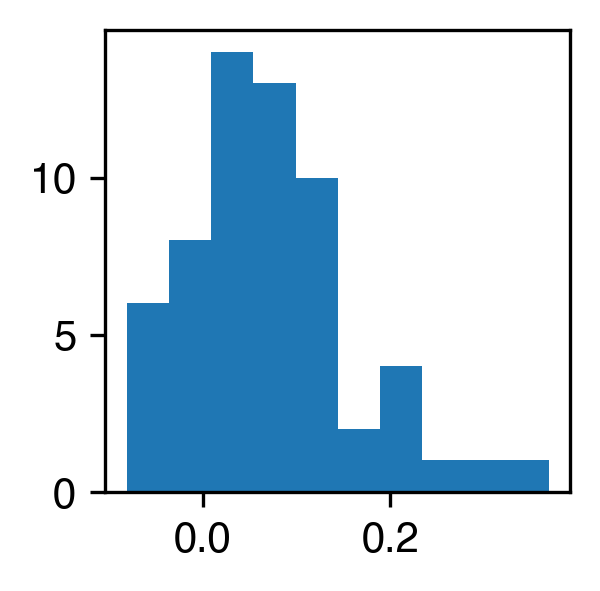

In [17]:
plt.figure(figsize=(2,2))
plt.hist(seed1_test_stat_arr[0, :, 3])
# plt.hist(seed2_test_stat_arr[0, :, 3])

# K = 5

100%|██████████| 200/200 [00:00<00:00, 409.13it/s]


Bootstrap variance 0.009441710280430525
Seed variance 0.016912156730831174


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(1, 5, 20) (1, 5, 20)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


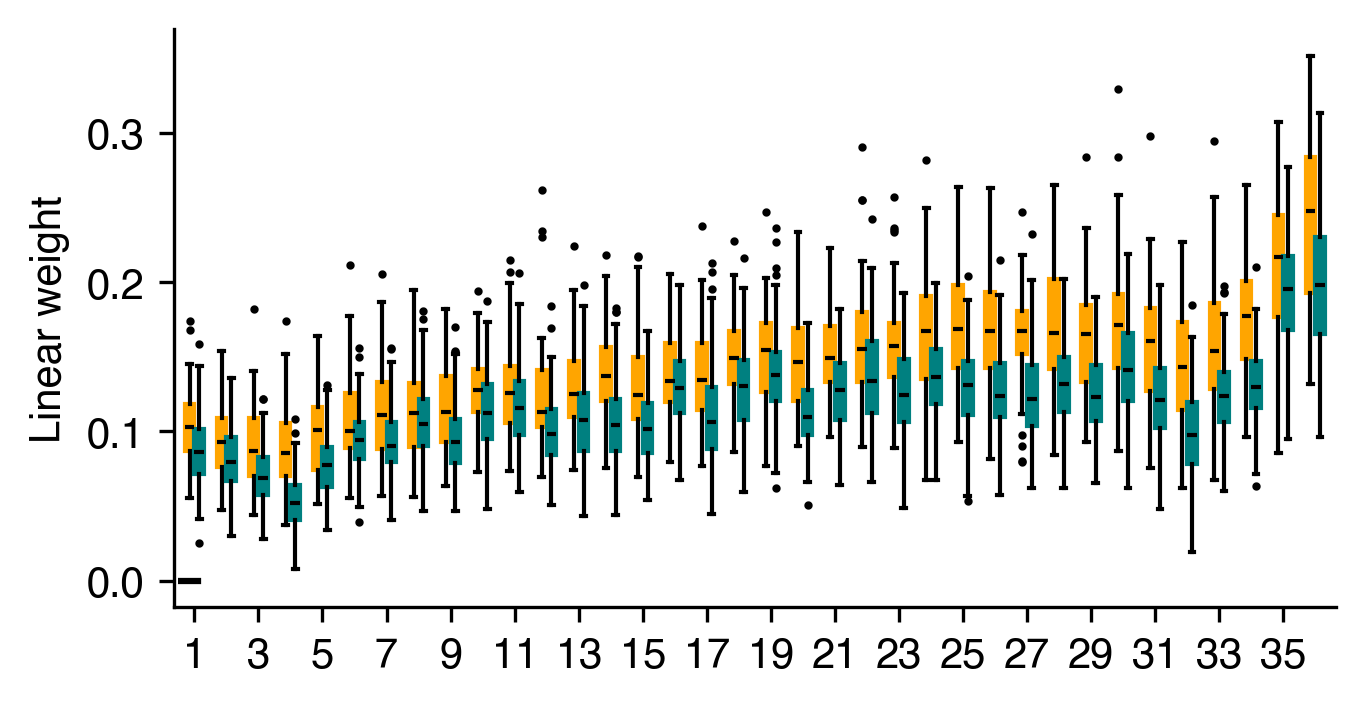

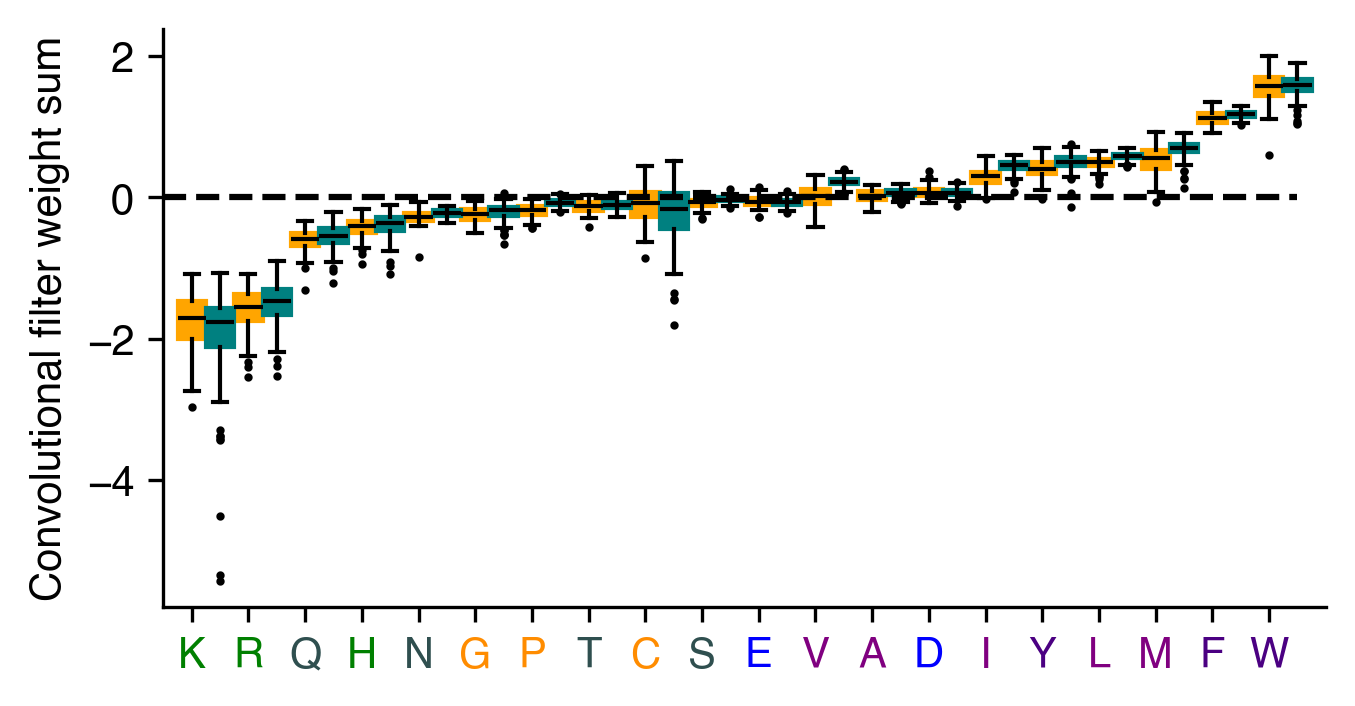

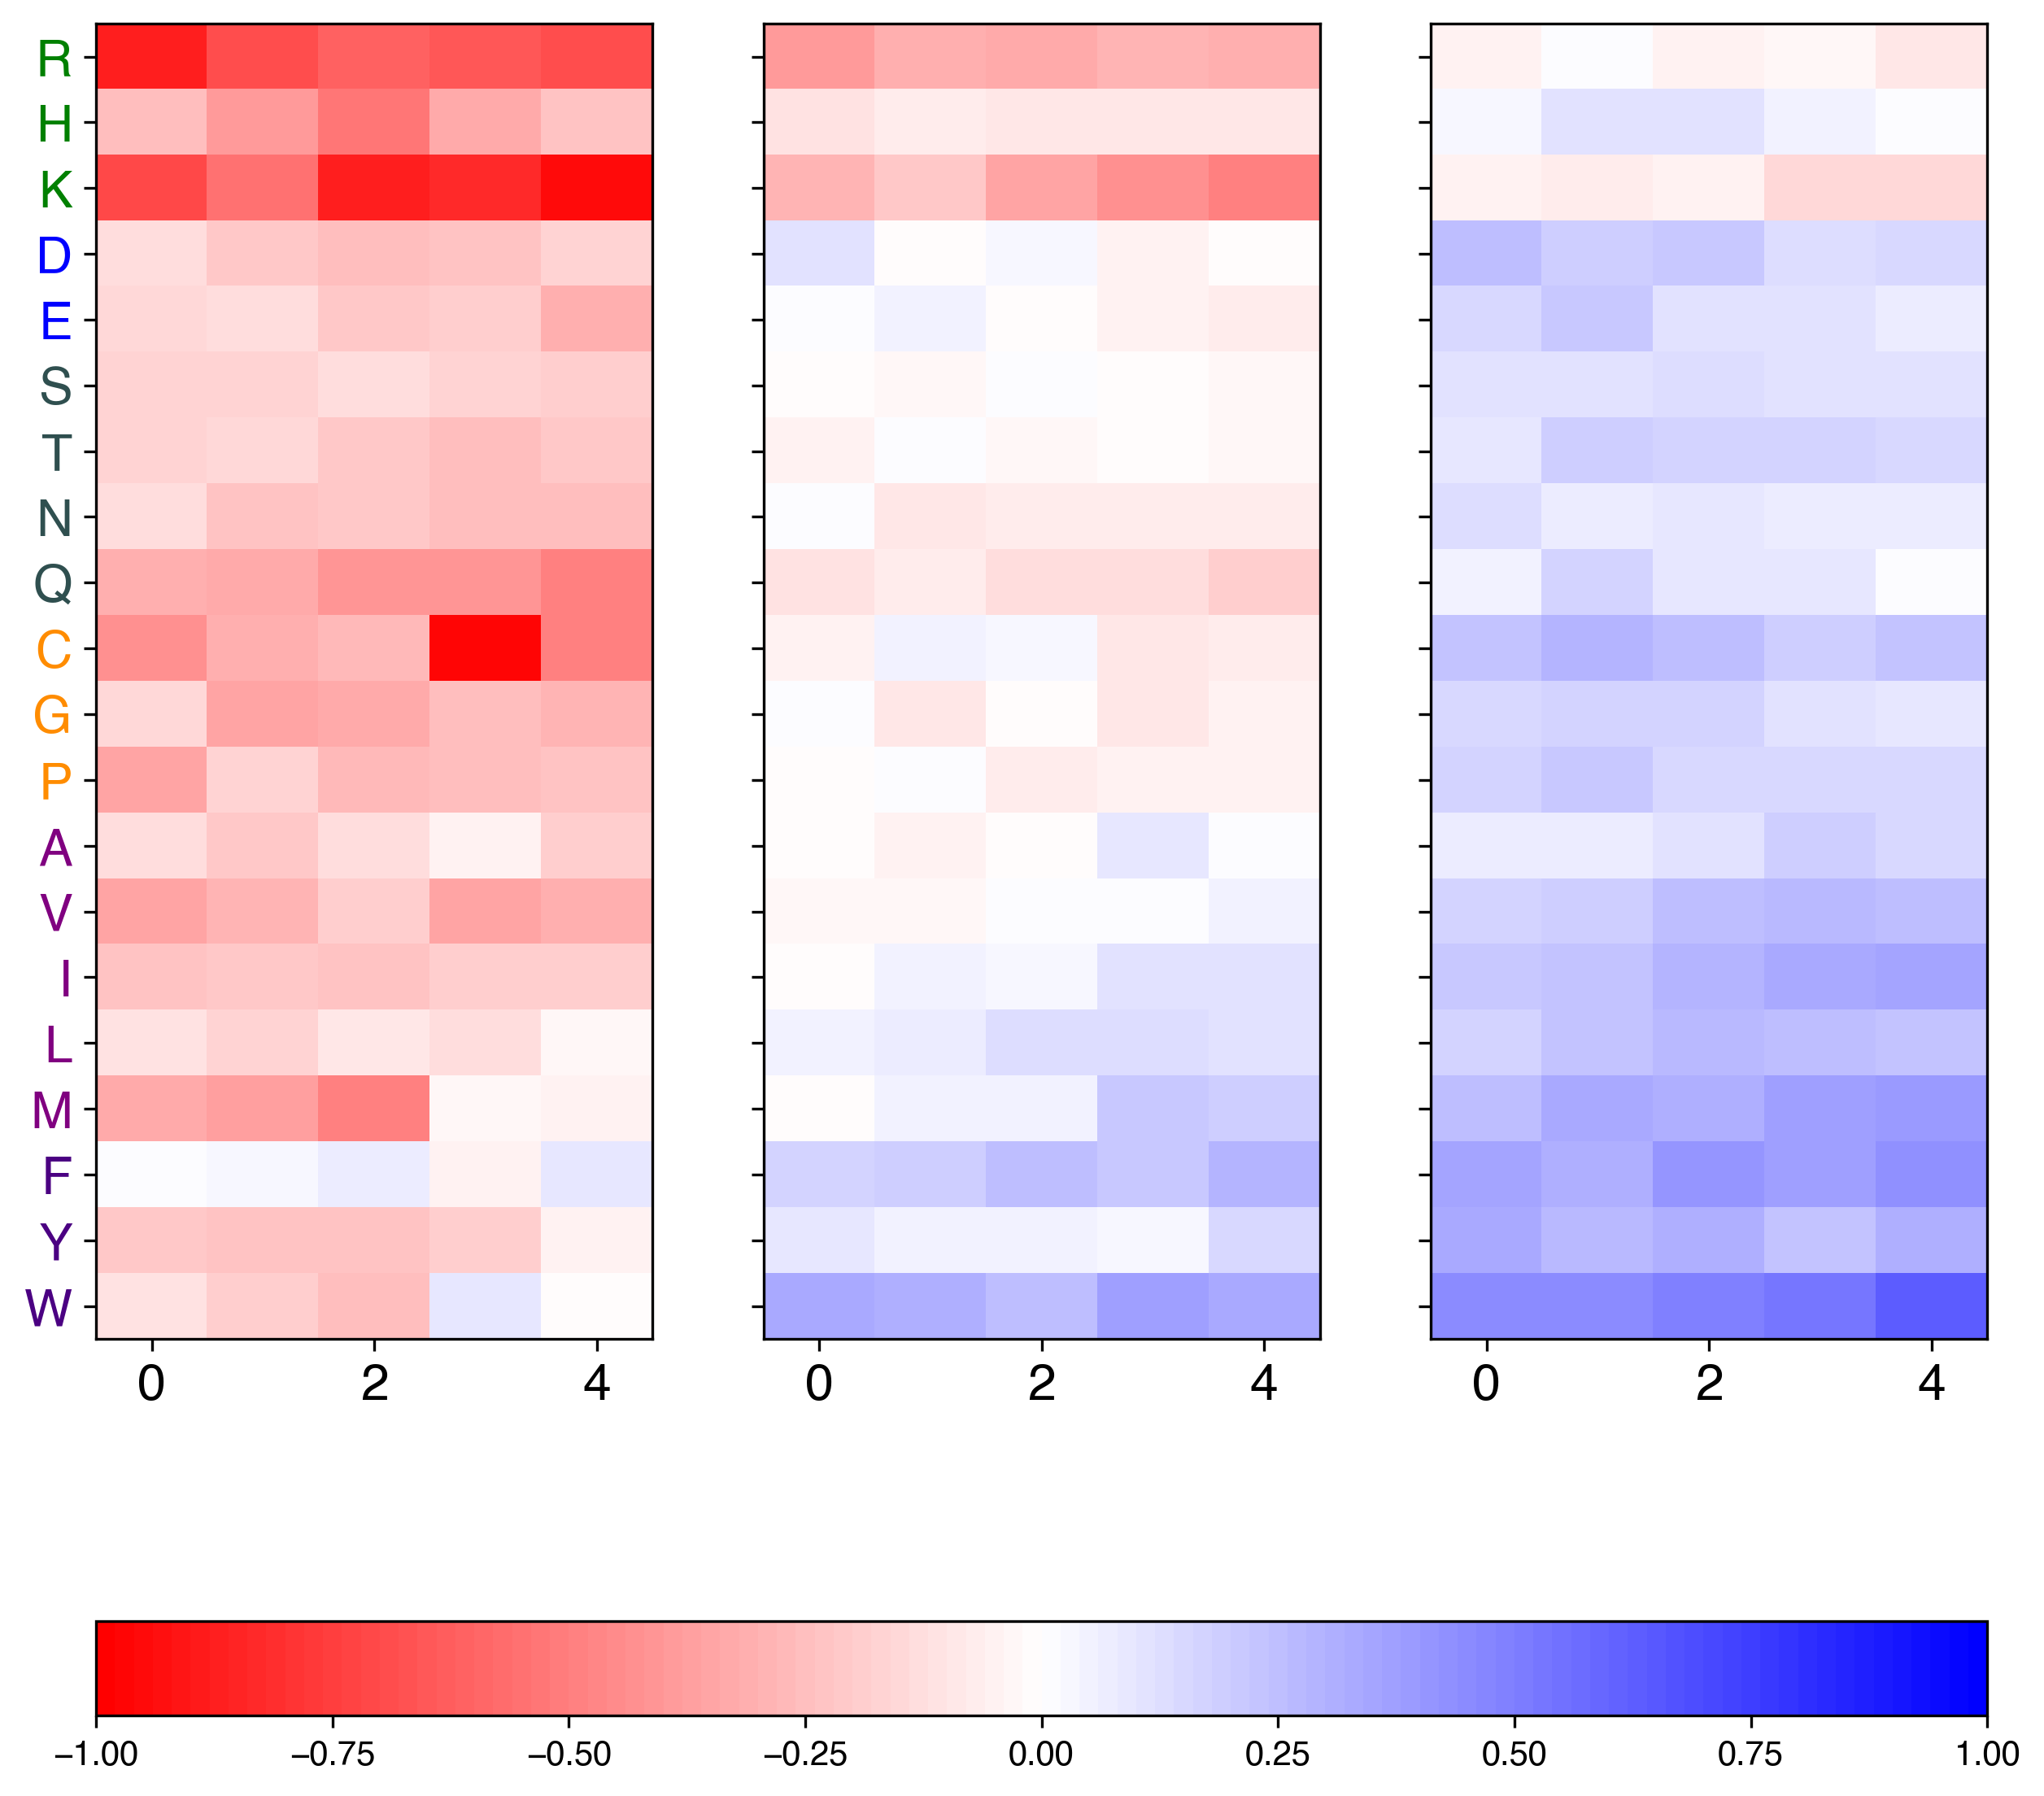

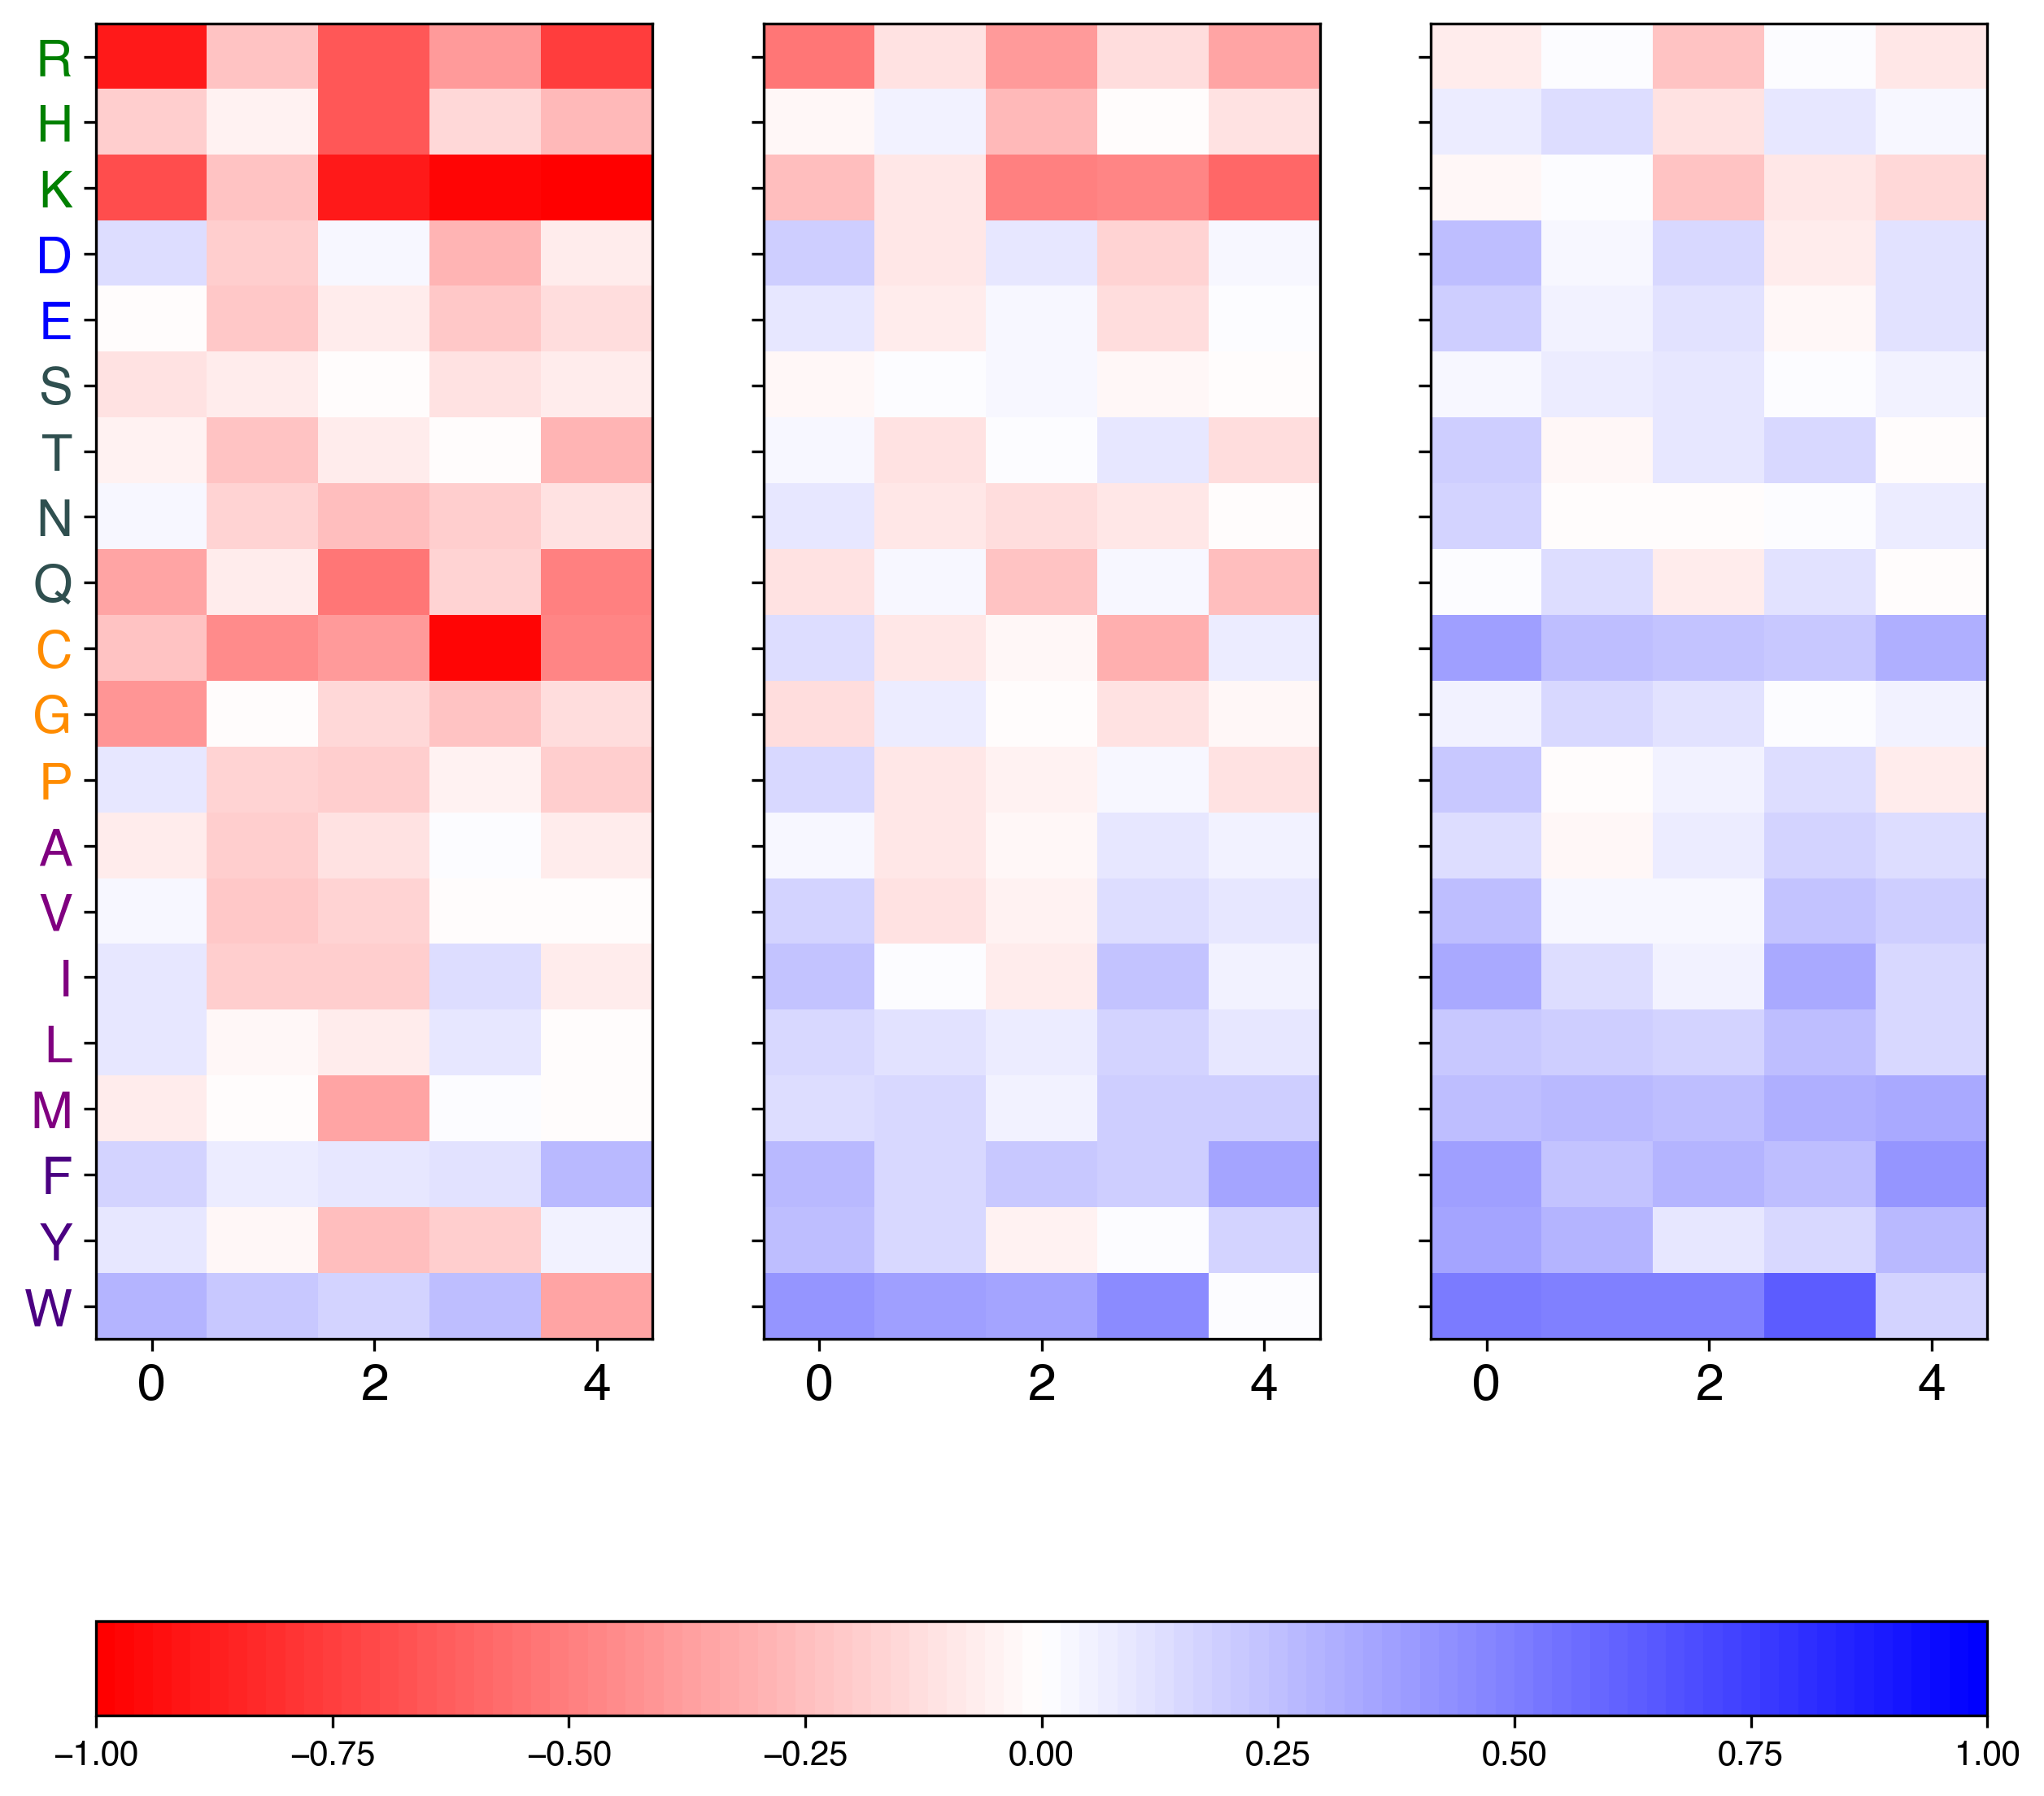

In [154]:
# comparison_subset
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

run_analysis(5, outfile_name="k5")

# K = 10

100%|██████████| 200/200 [00:00<00:00, 373.67it/s]


Bootstrap variance 0.006321467286260691
Seed variance 0.0108321797250392


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(1, 10, 20) (1, 10, 20)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


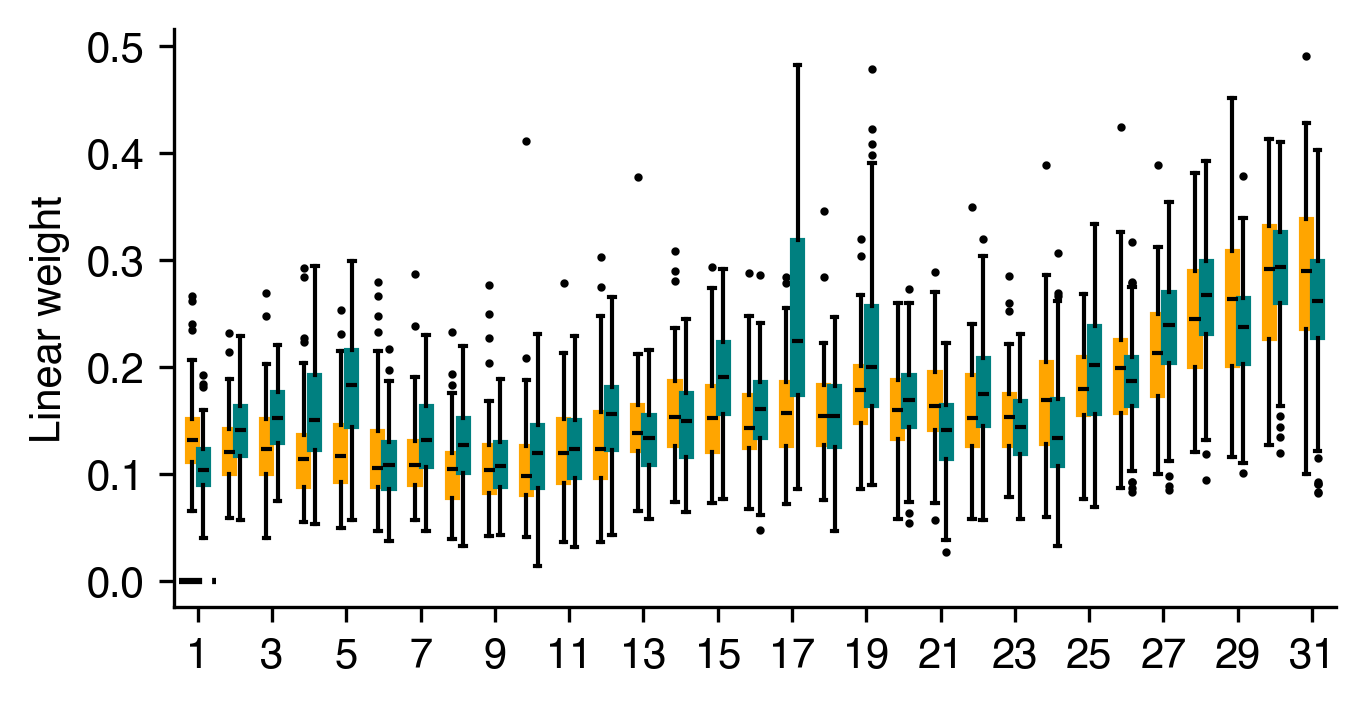

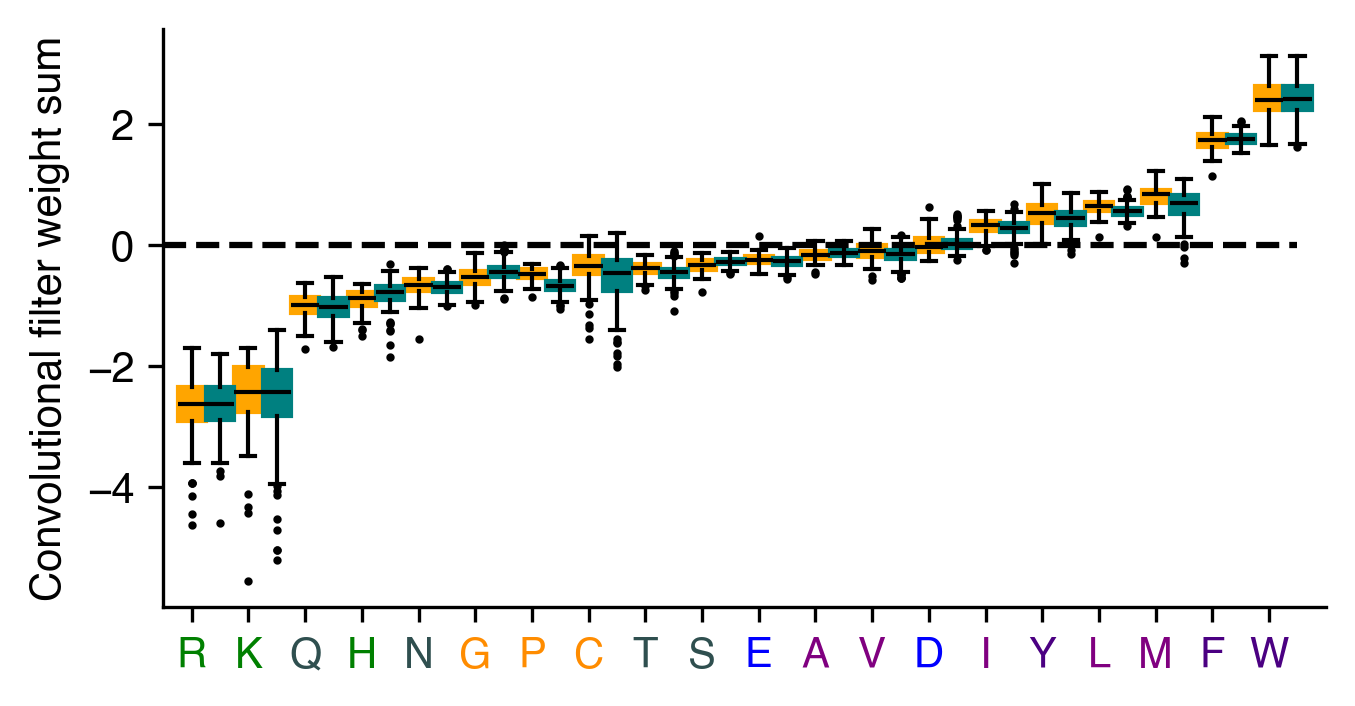

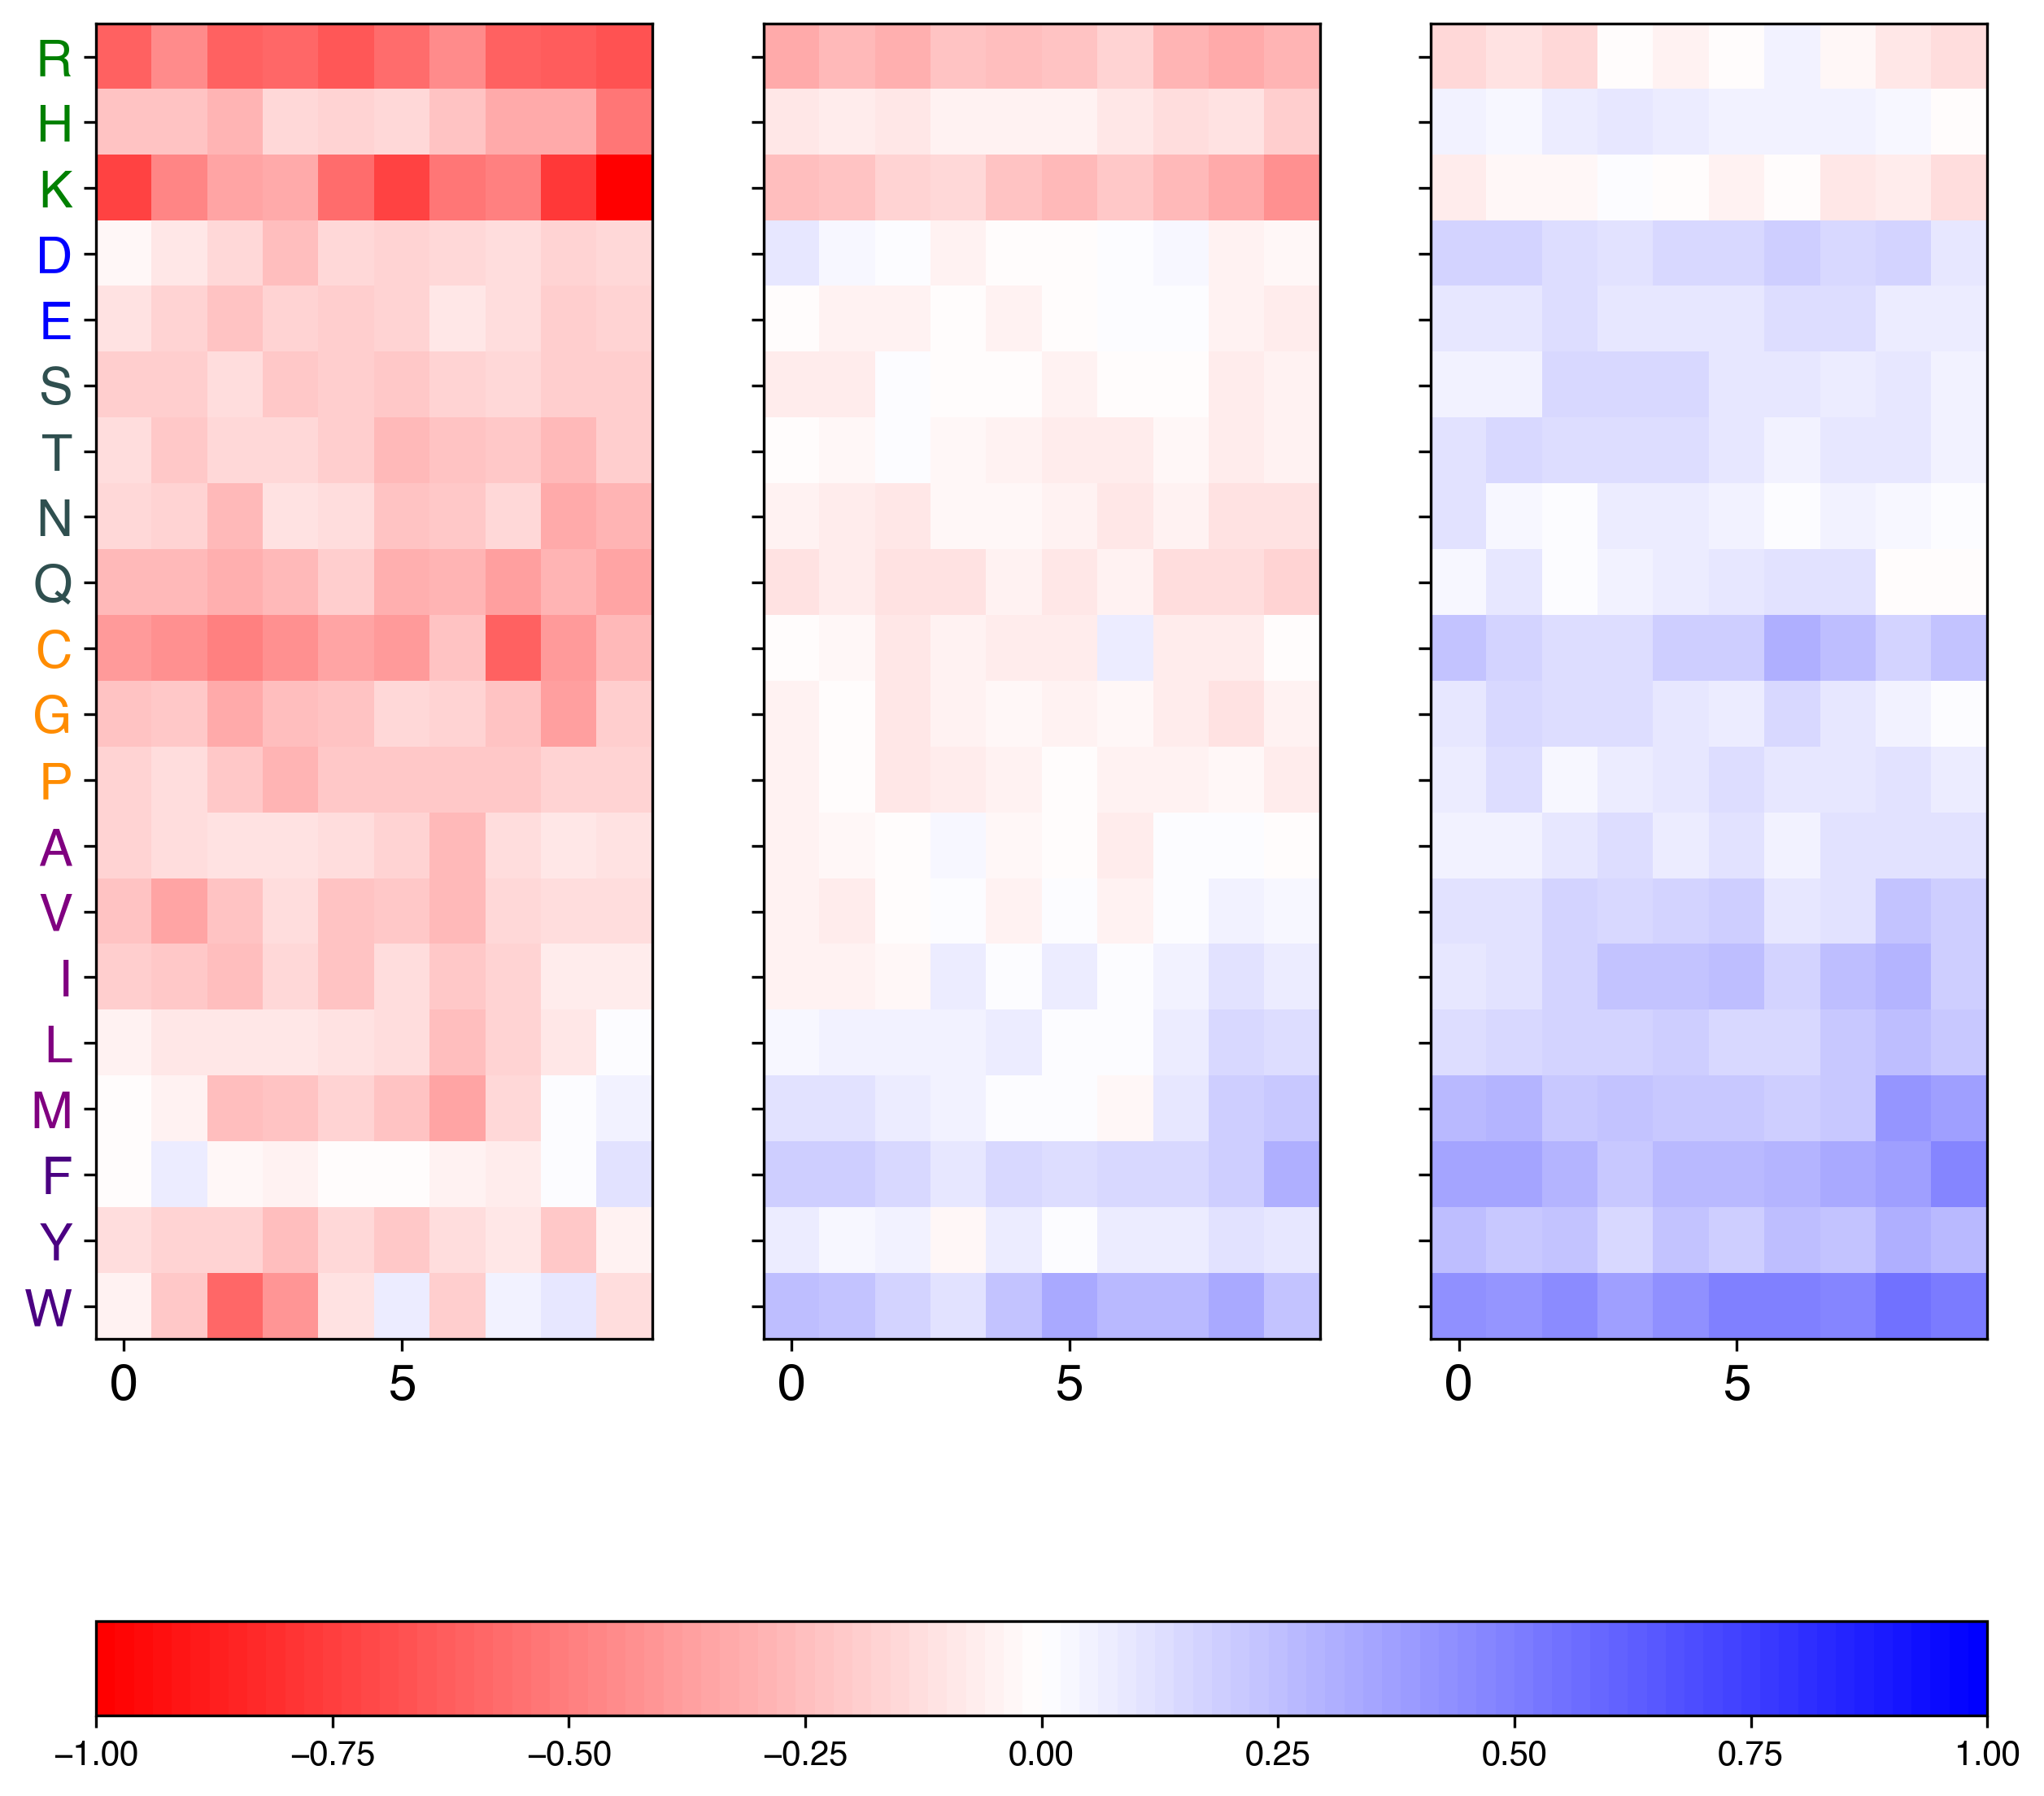

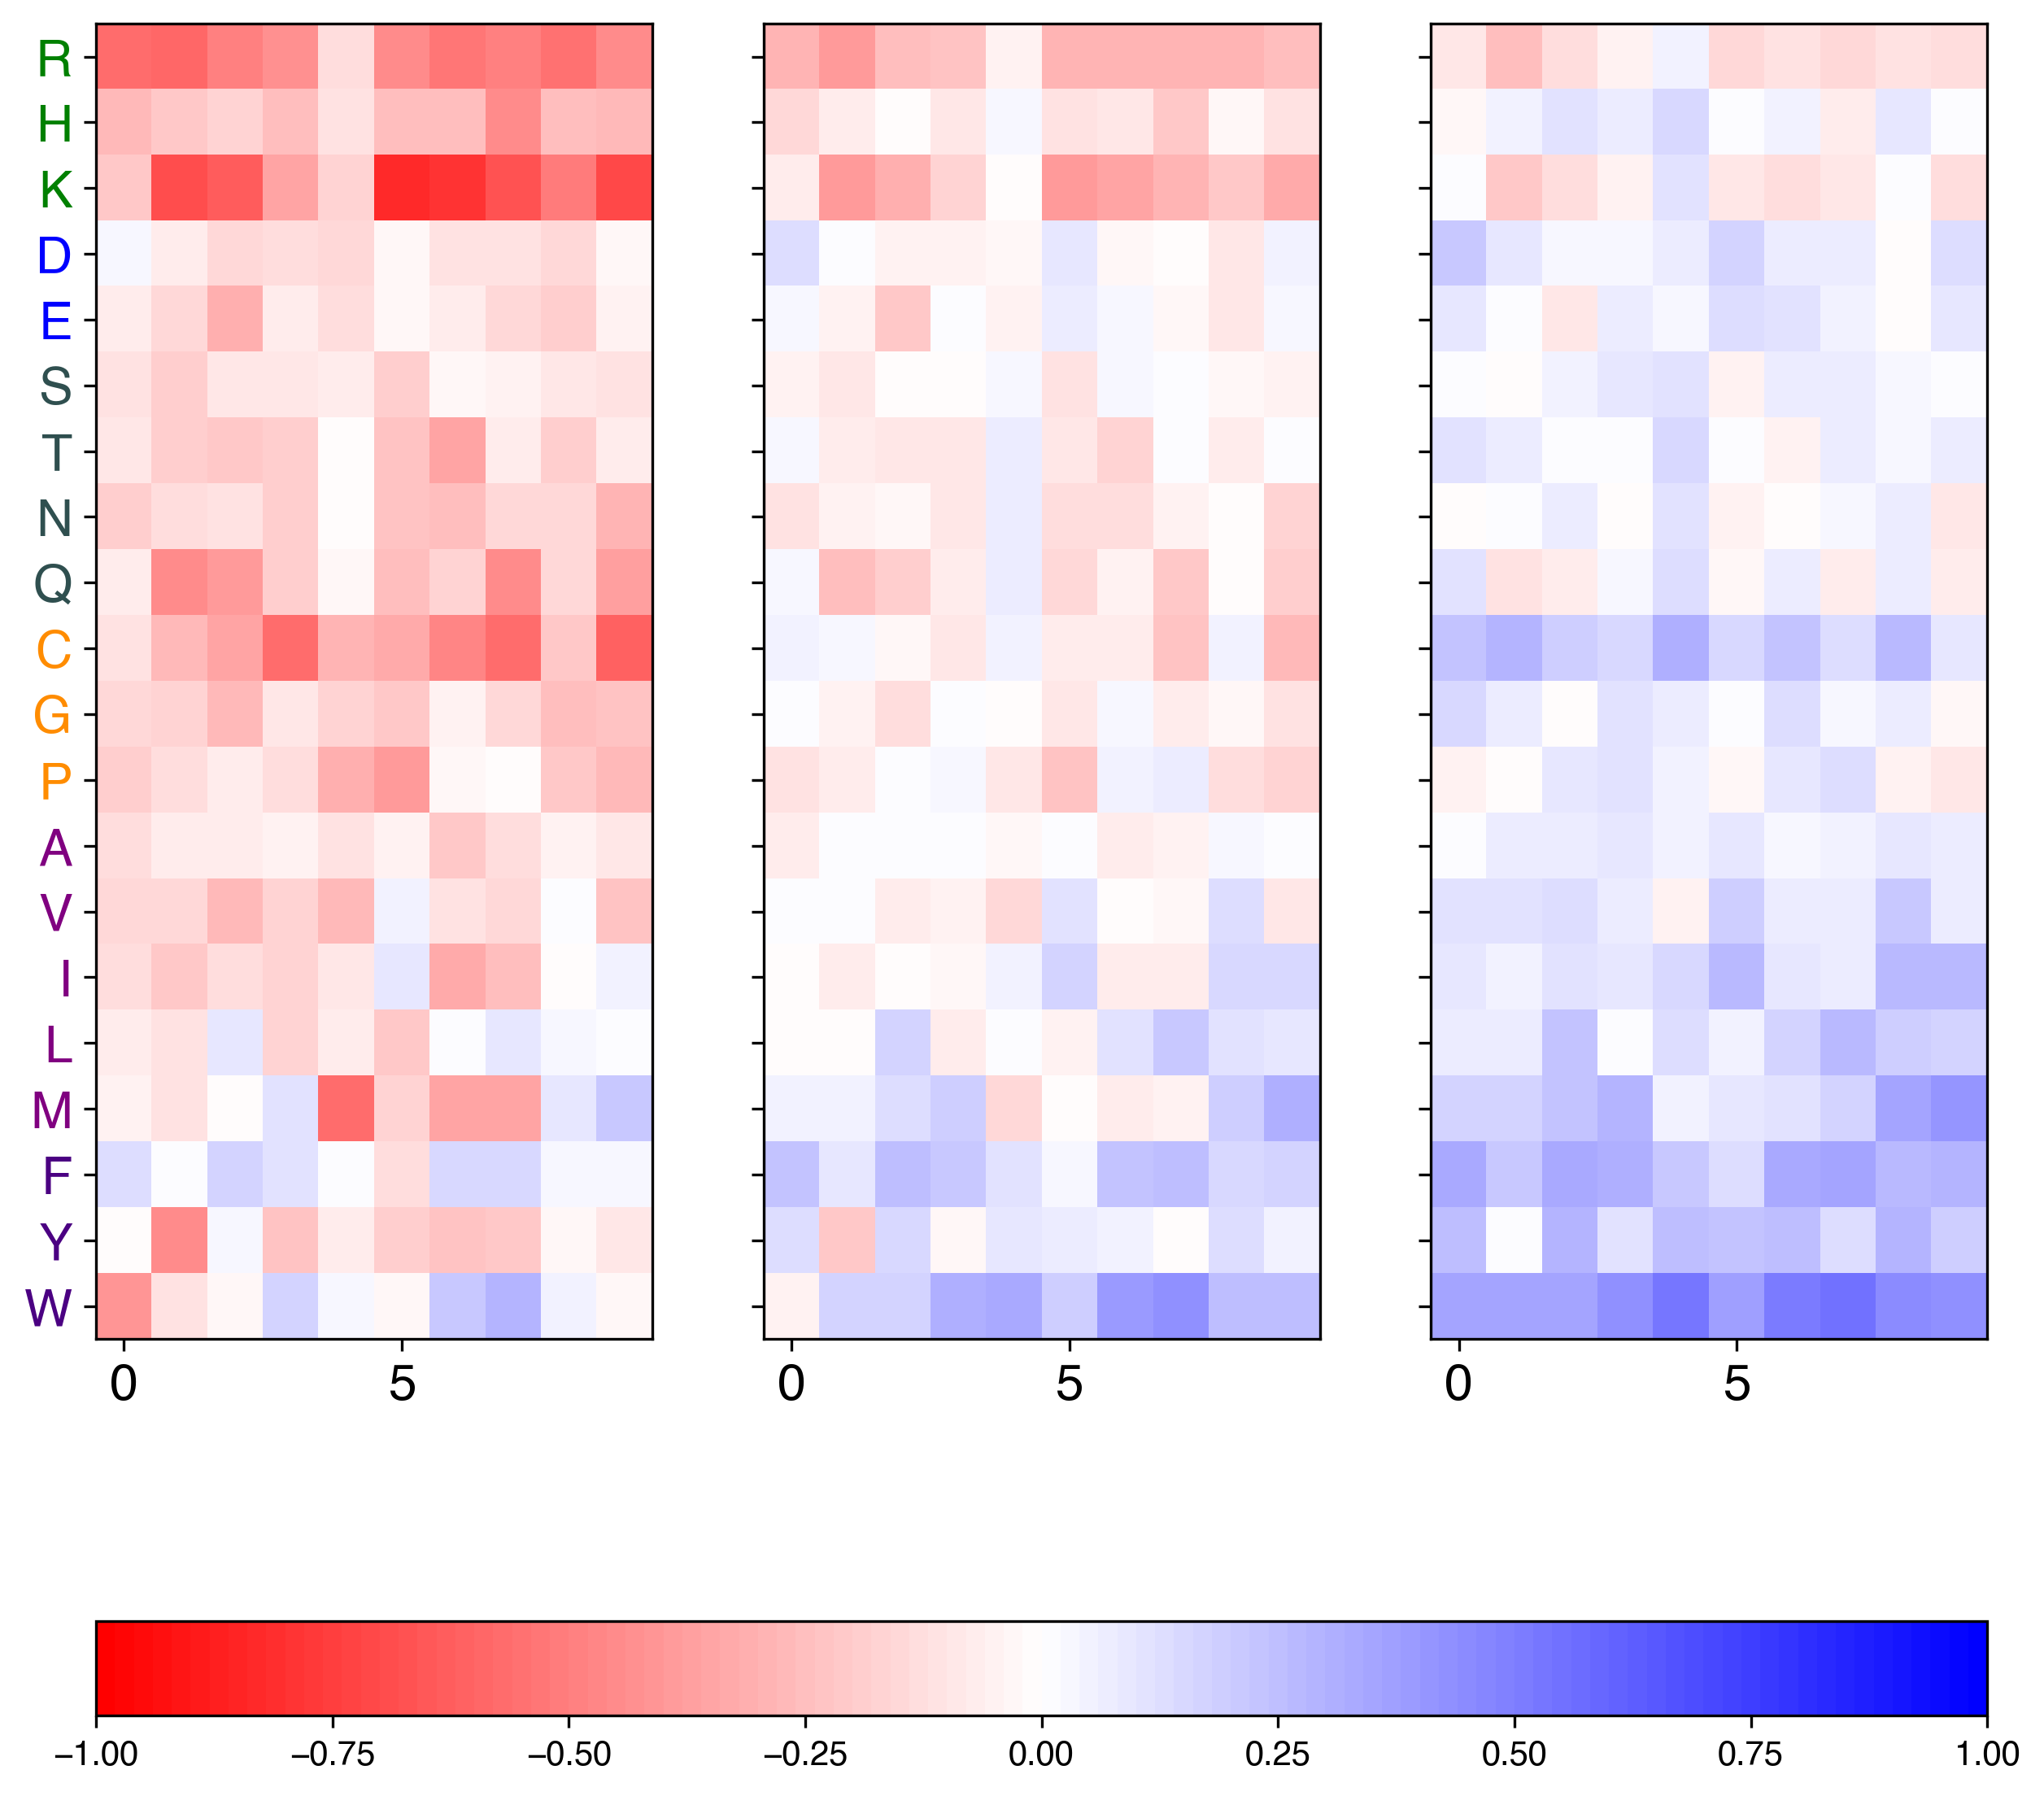

In [160]:
# comparison_subset
run_analysis(10, outfile_name="k10")

# Kernel size 15

100%|██████████| 200/200 [00:00<00:00, 291.55it/s]


Bootstrap variance 0.004298624494165443
Seed variance 0.0066549489566065335


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(1, 15, 20) (1, 15, 20)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


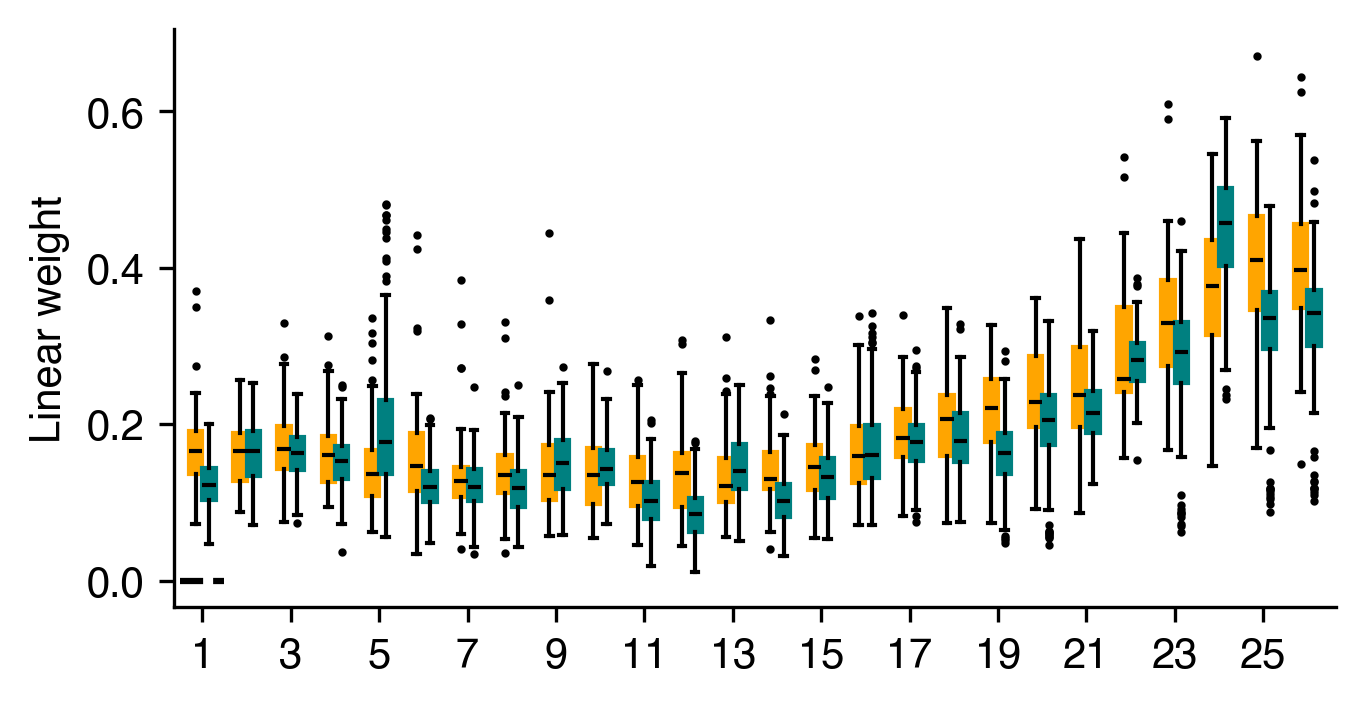

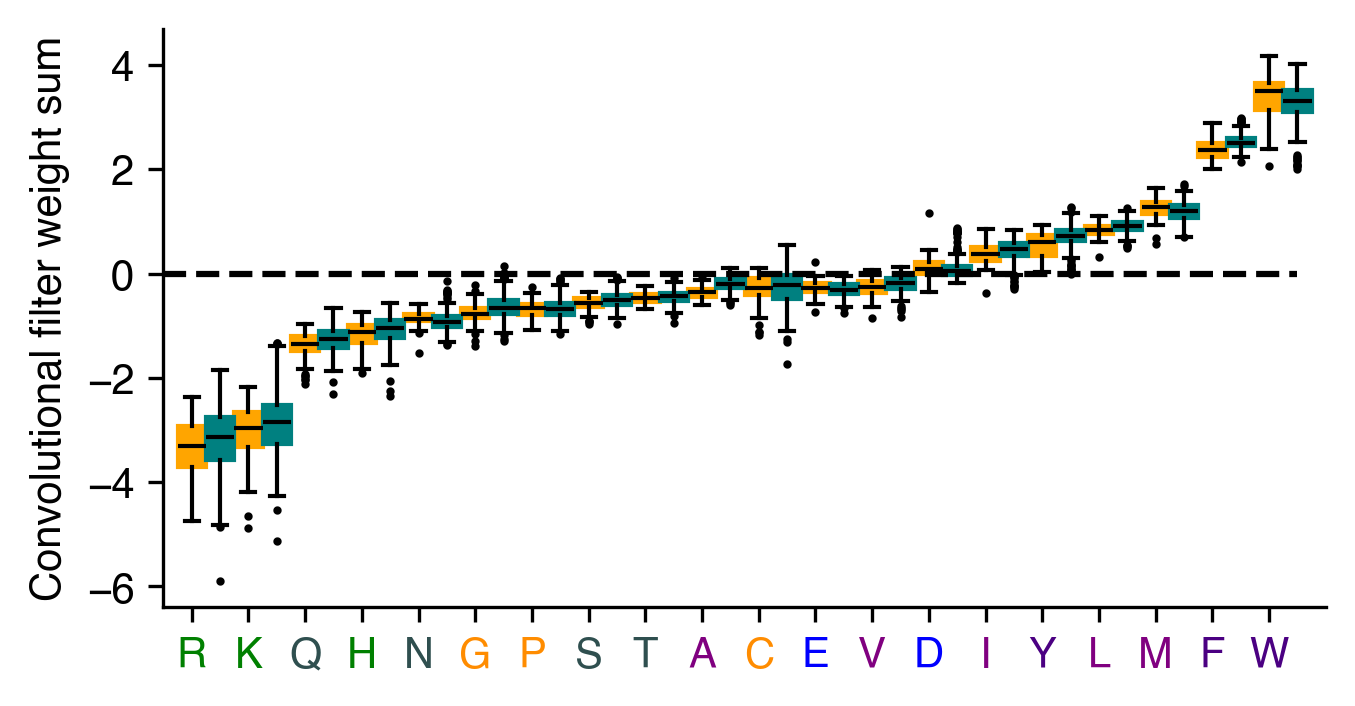

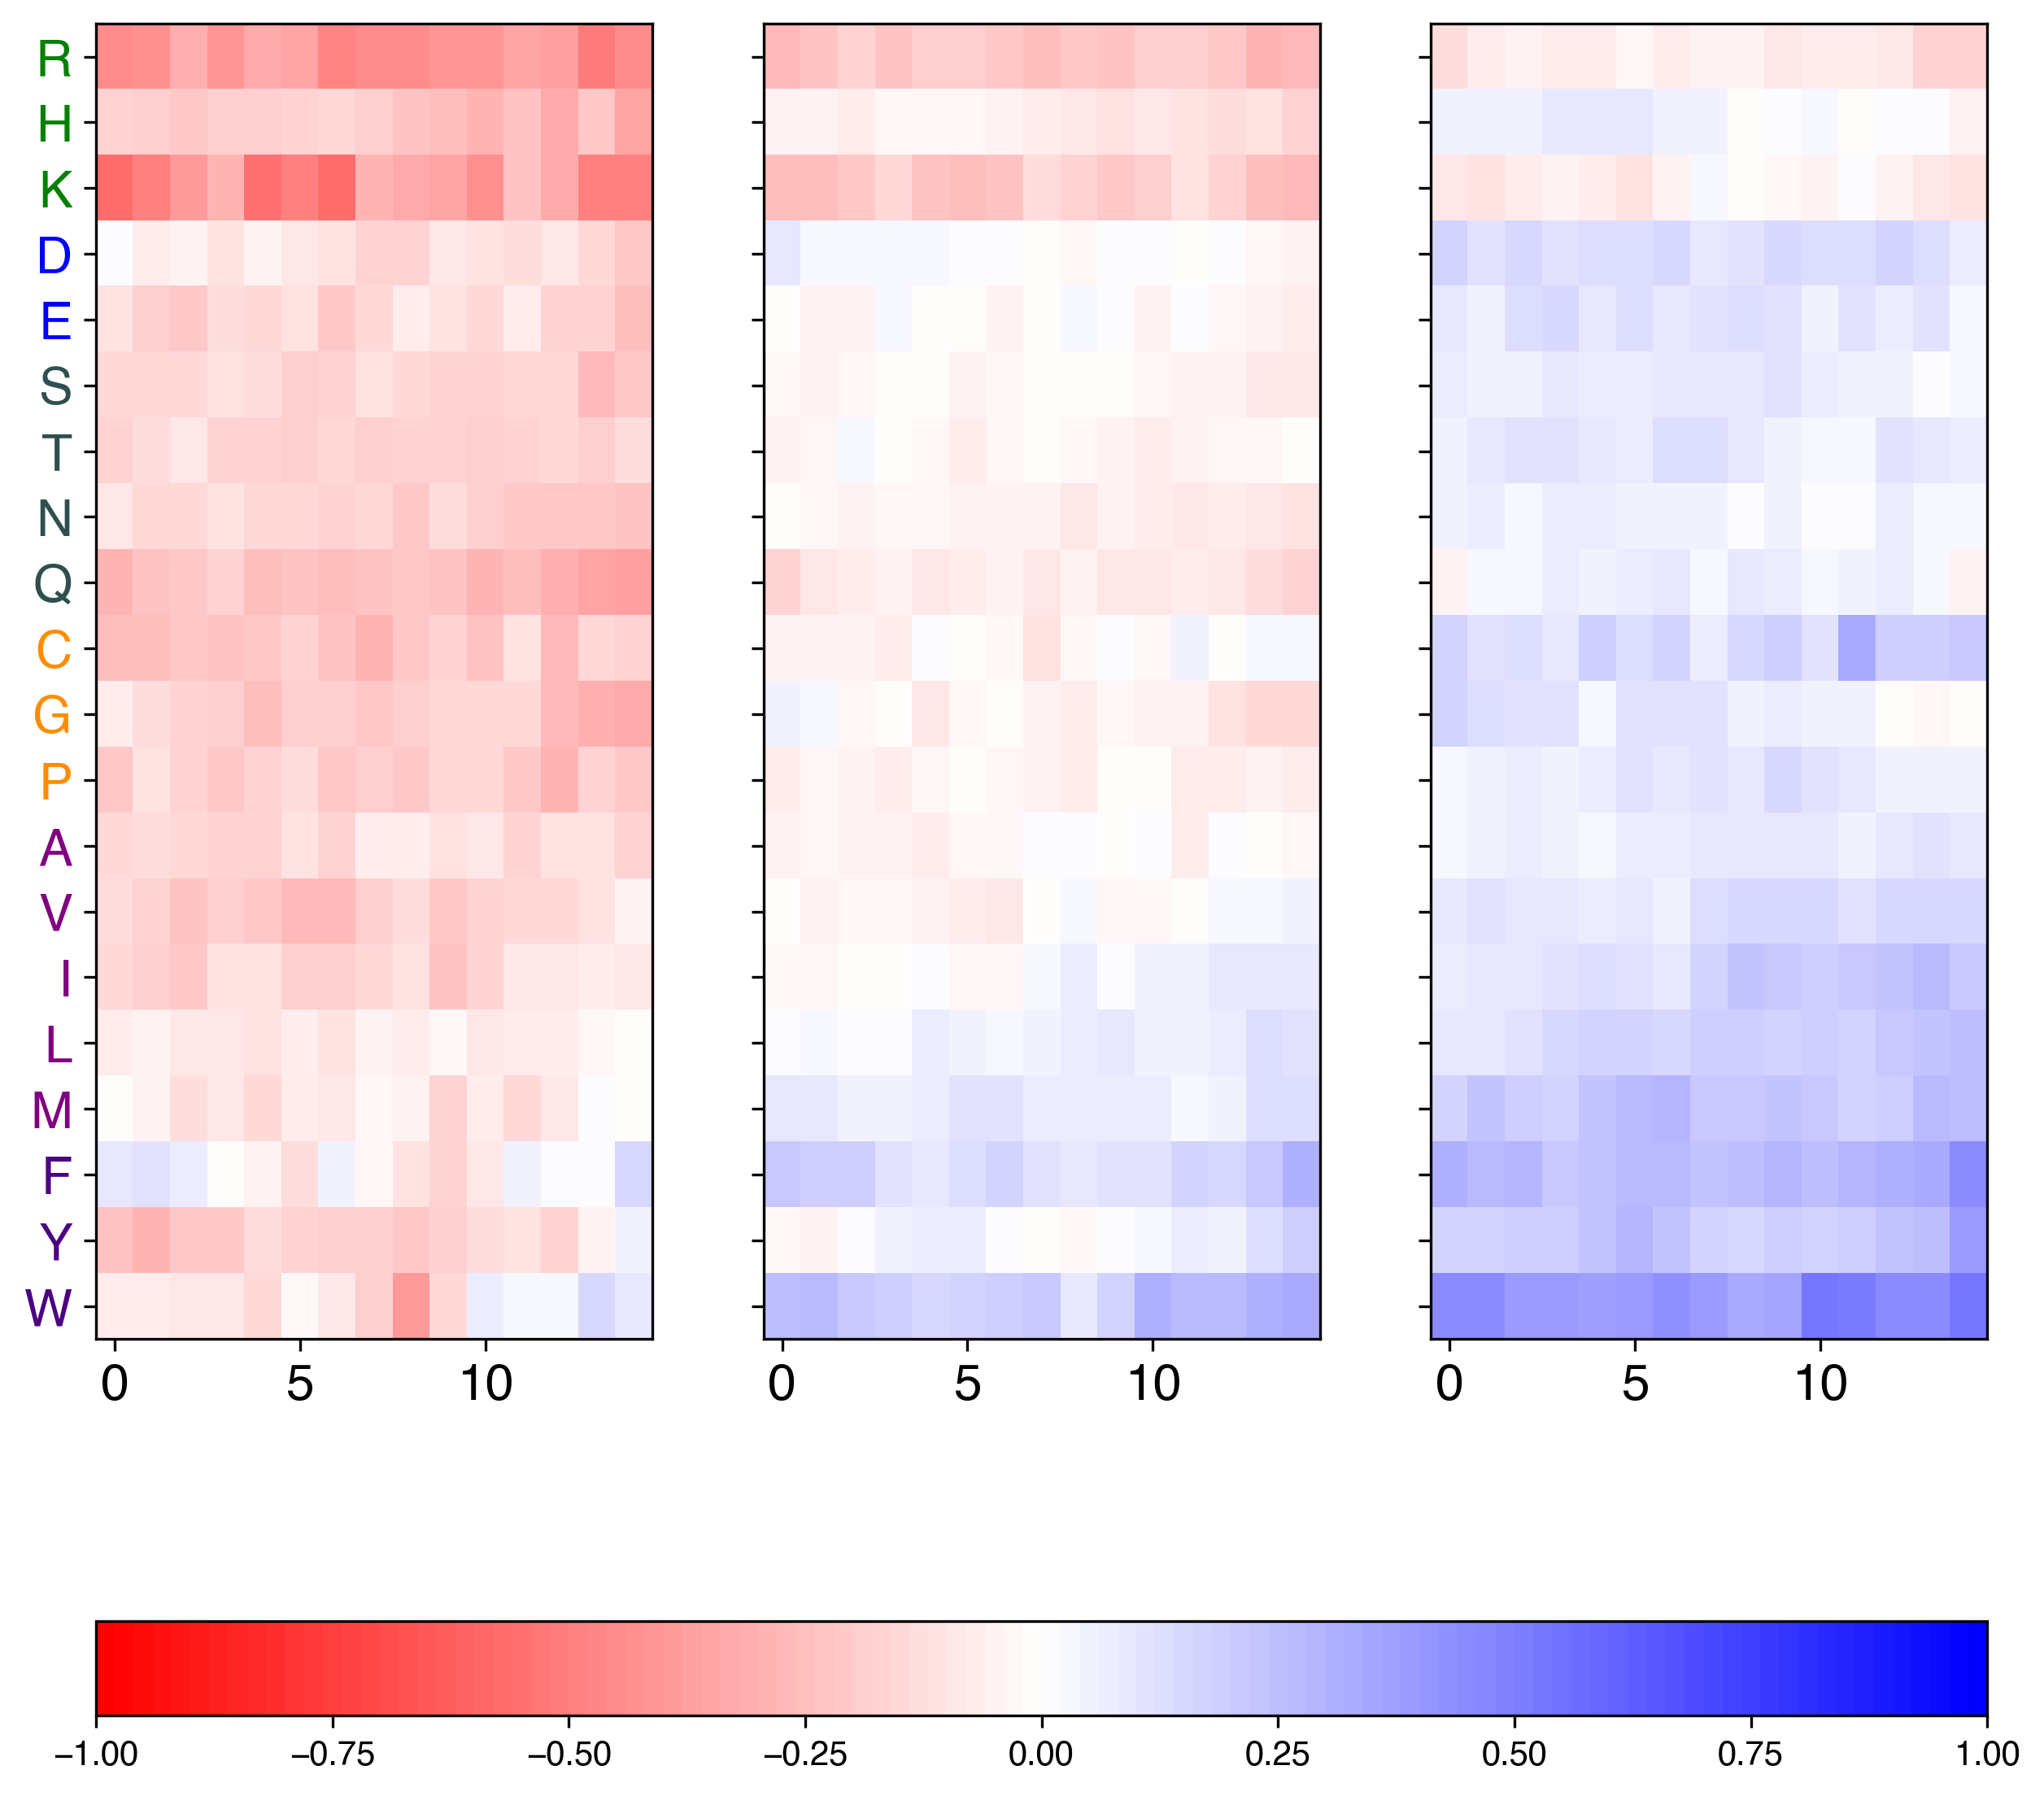

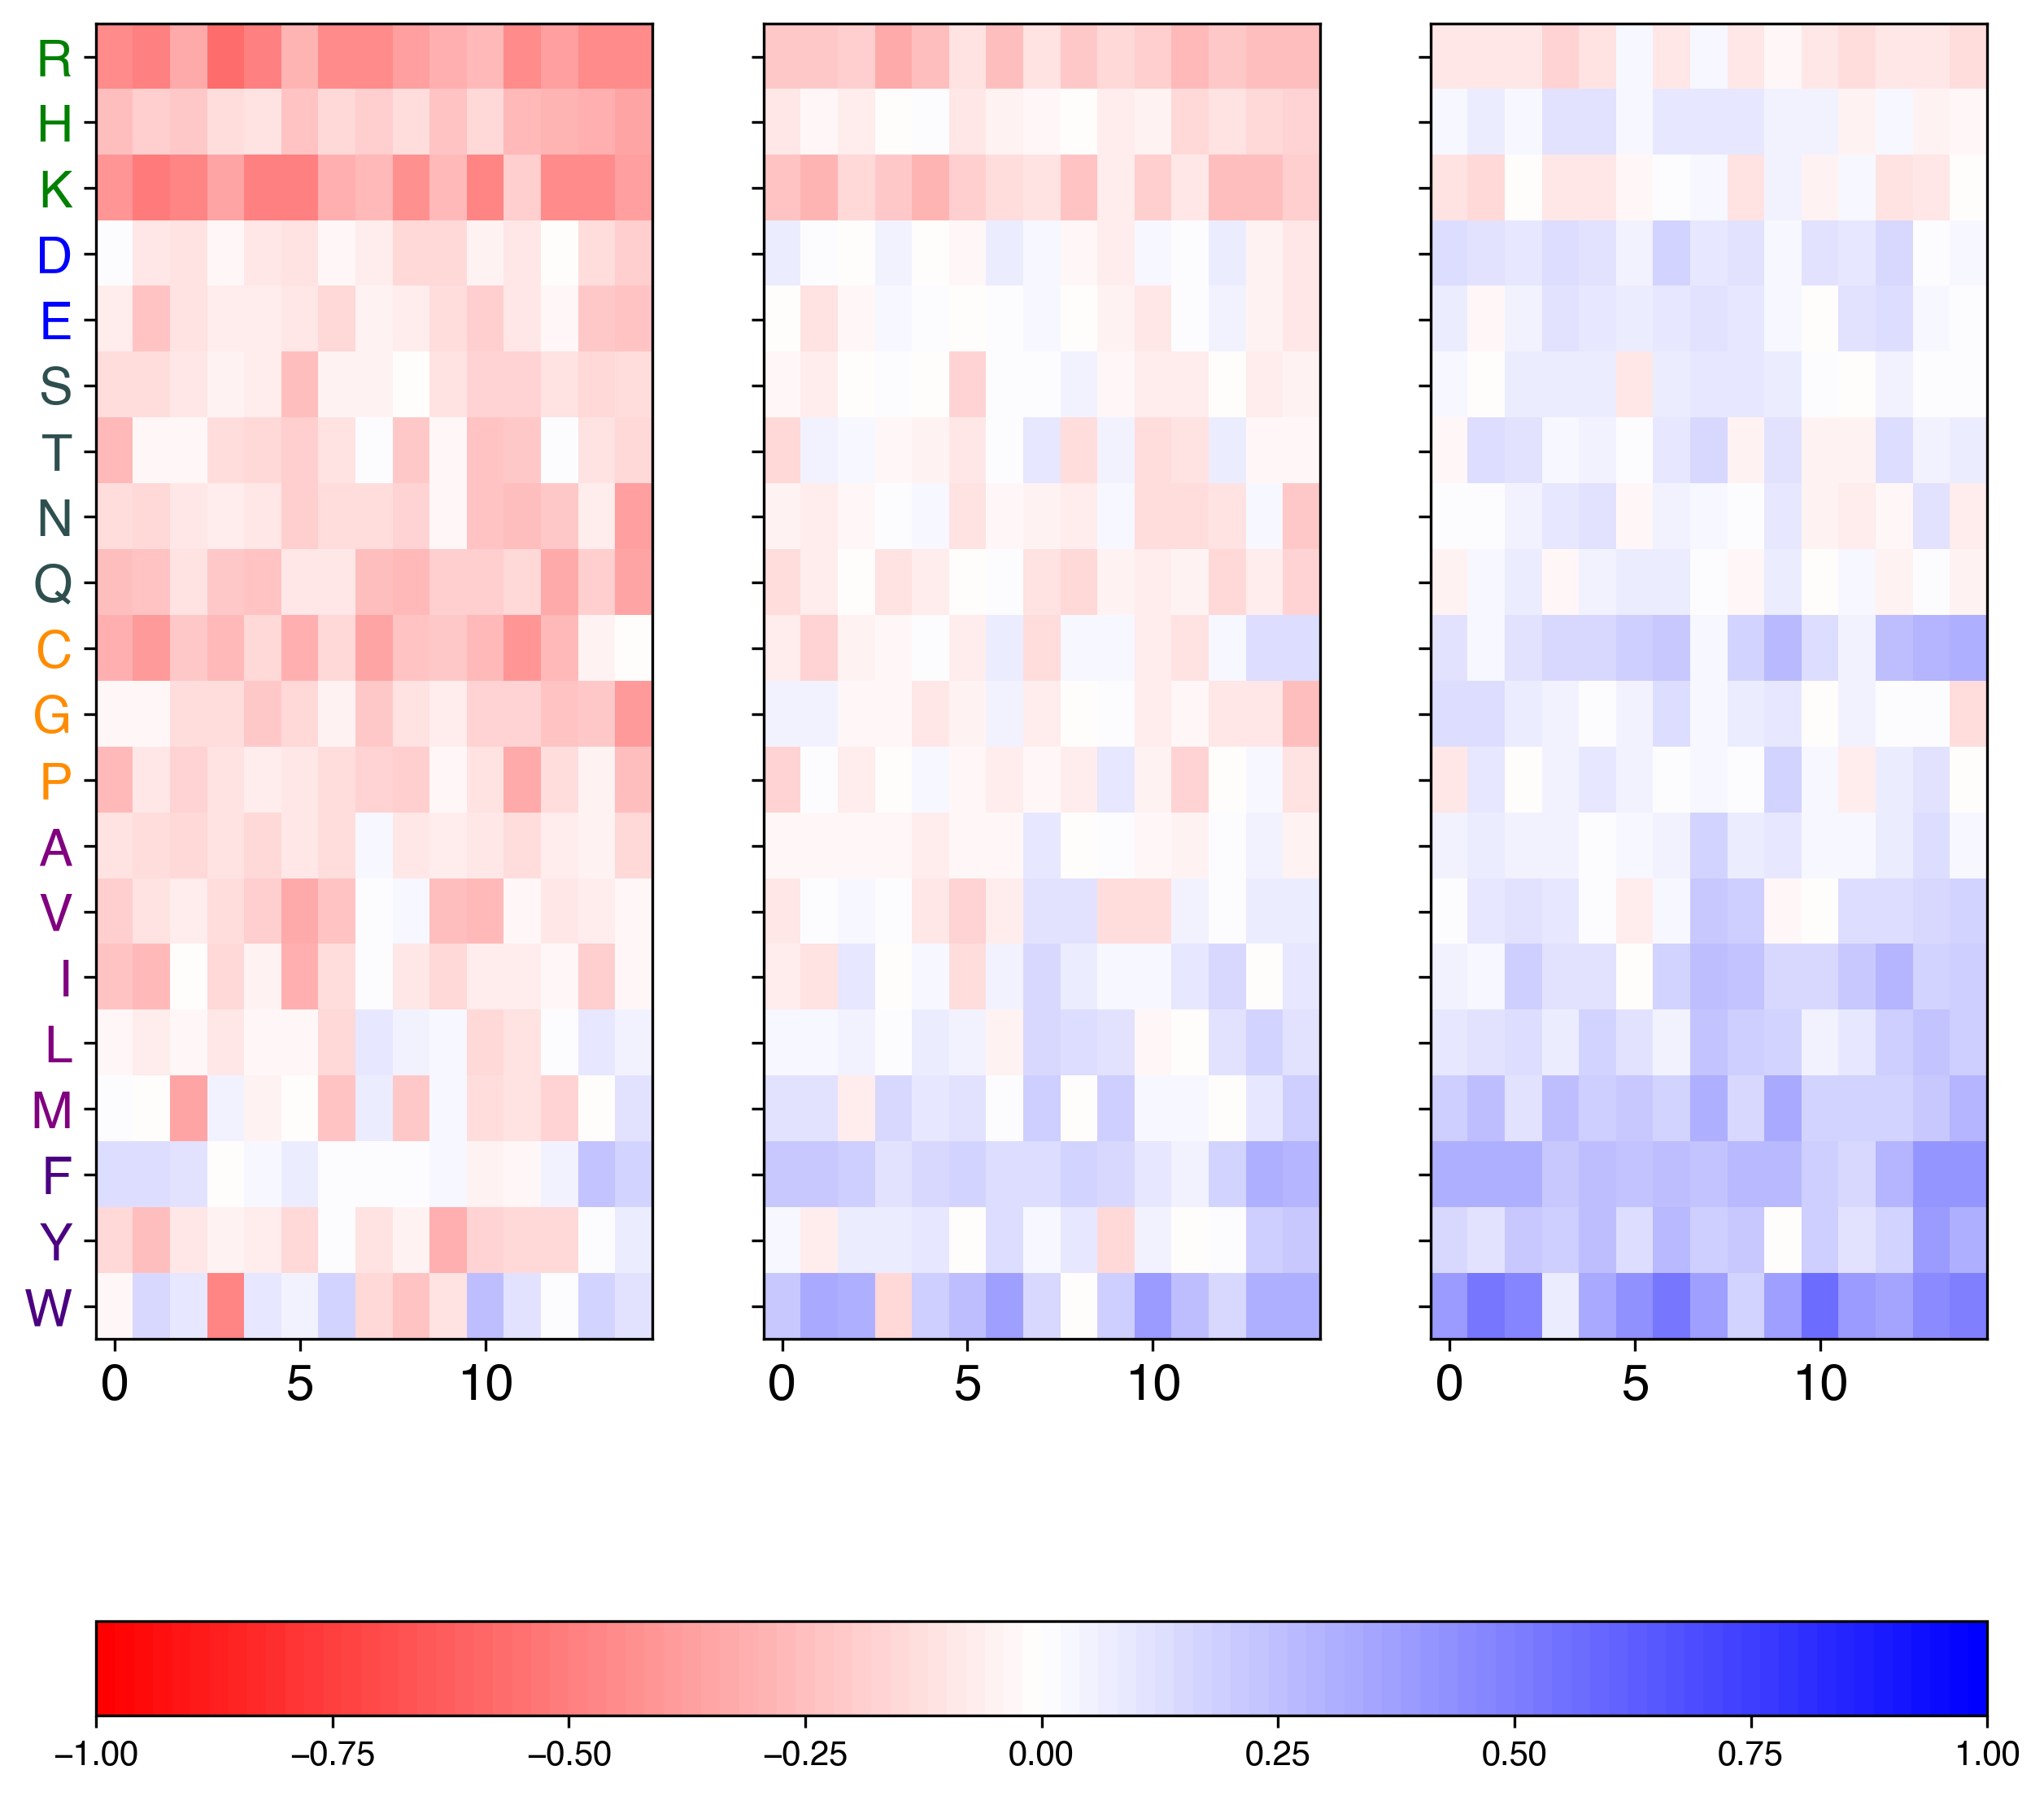

In [156]:
run_analysis(15, outfile_name="k15")

# Kernel size 20

100%|██████████| 200/200 [00:00<00:00, 339.36it/s]


Bootstrap variance 0.003908876726082309
Seed variance 0.00570774616292402


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(1, 20, 20) (1, 20, 20)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


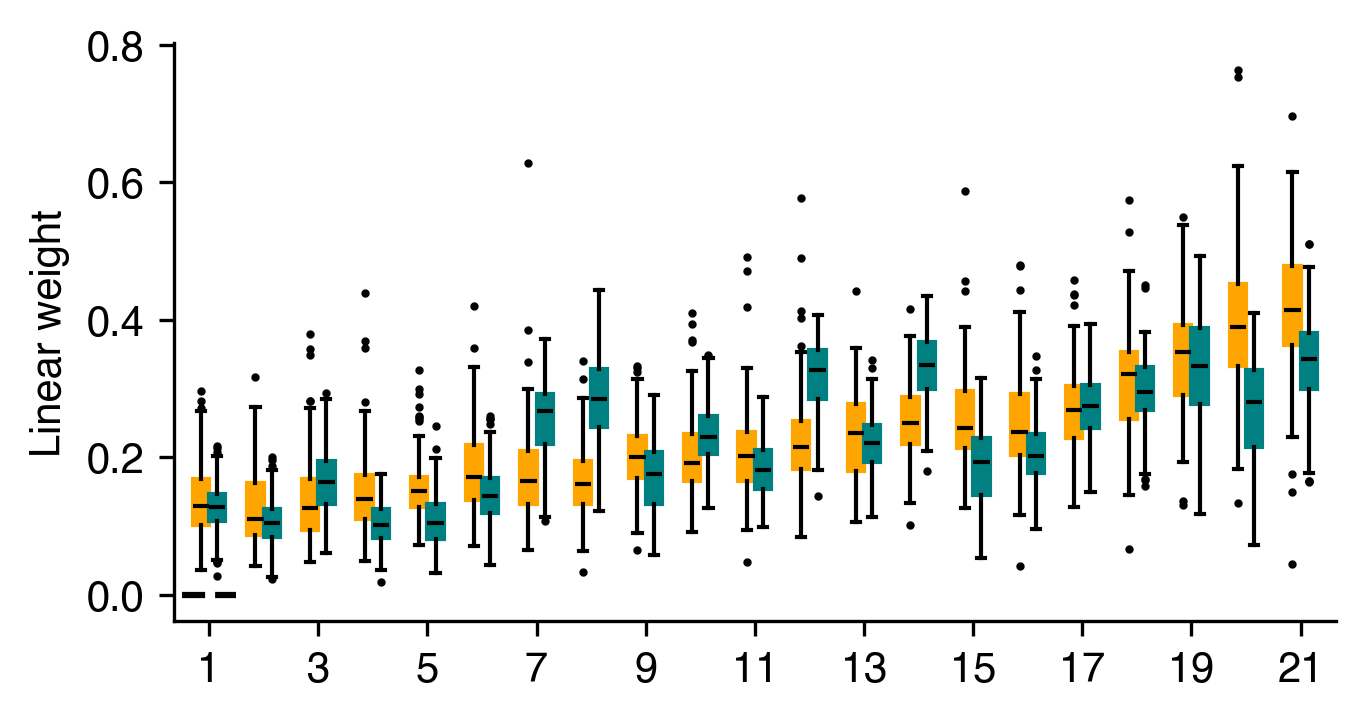

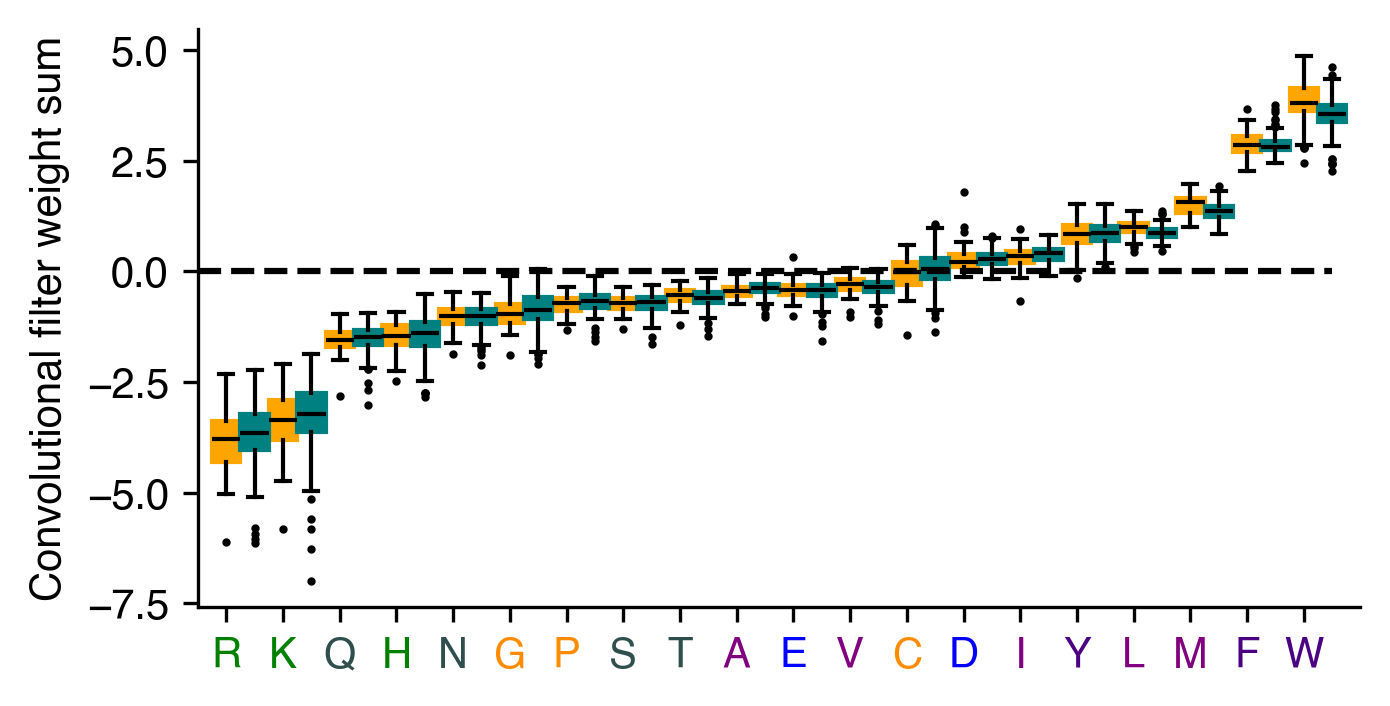

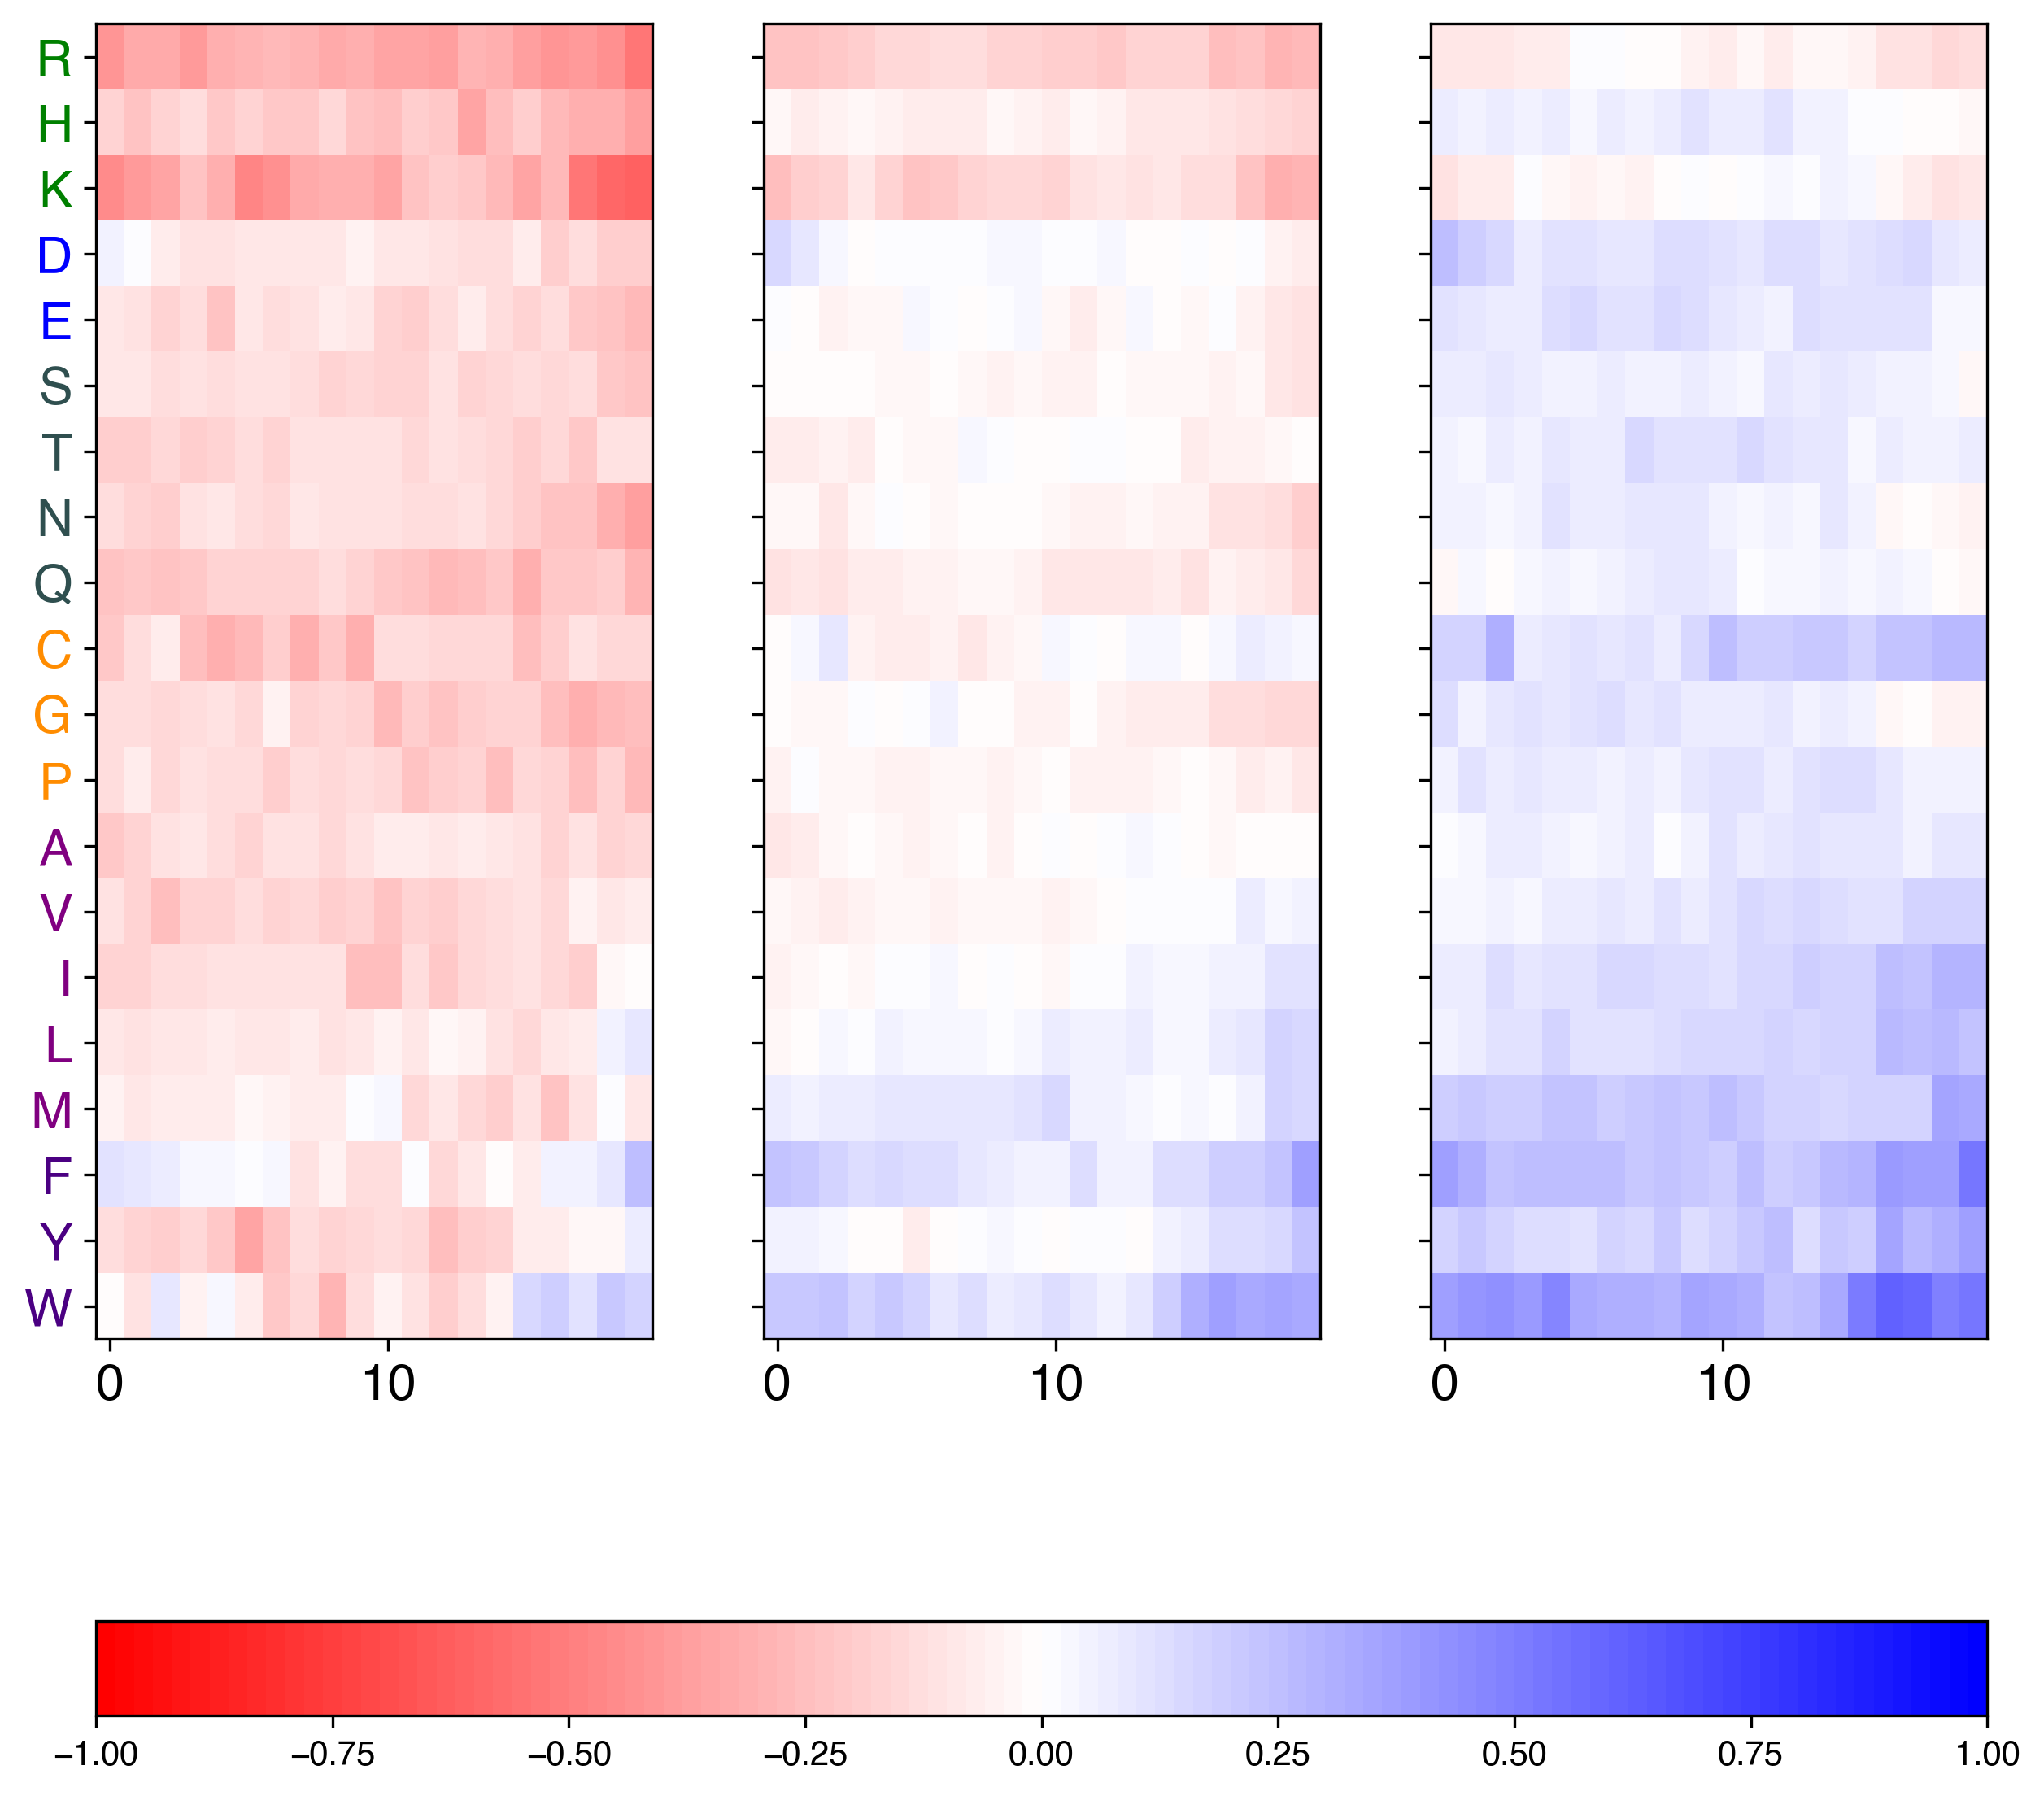

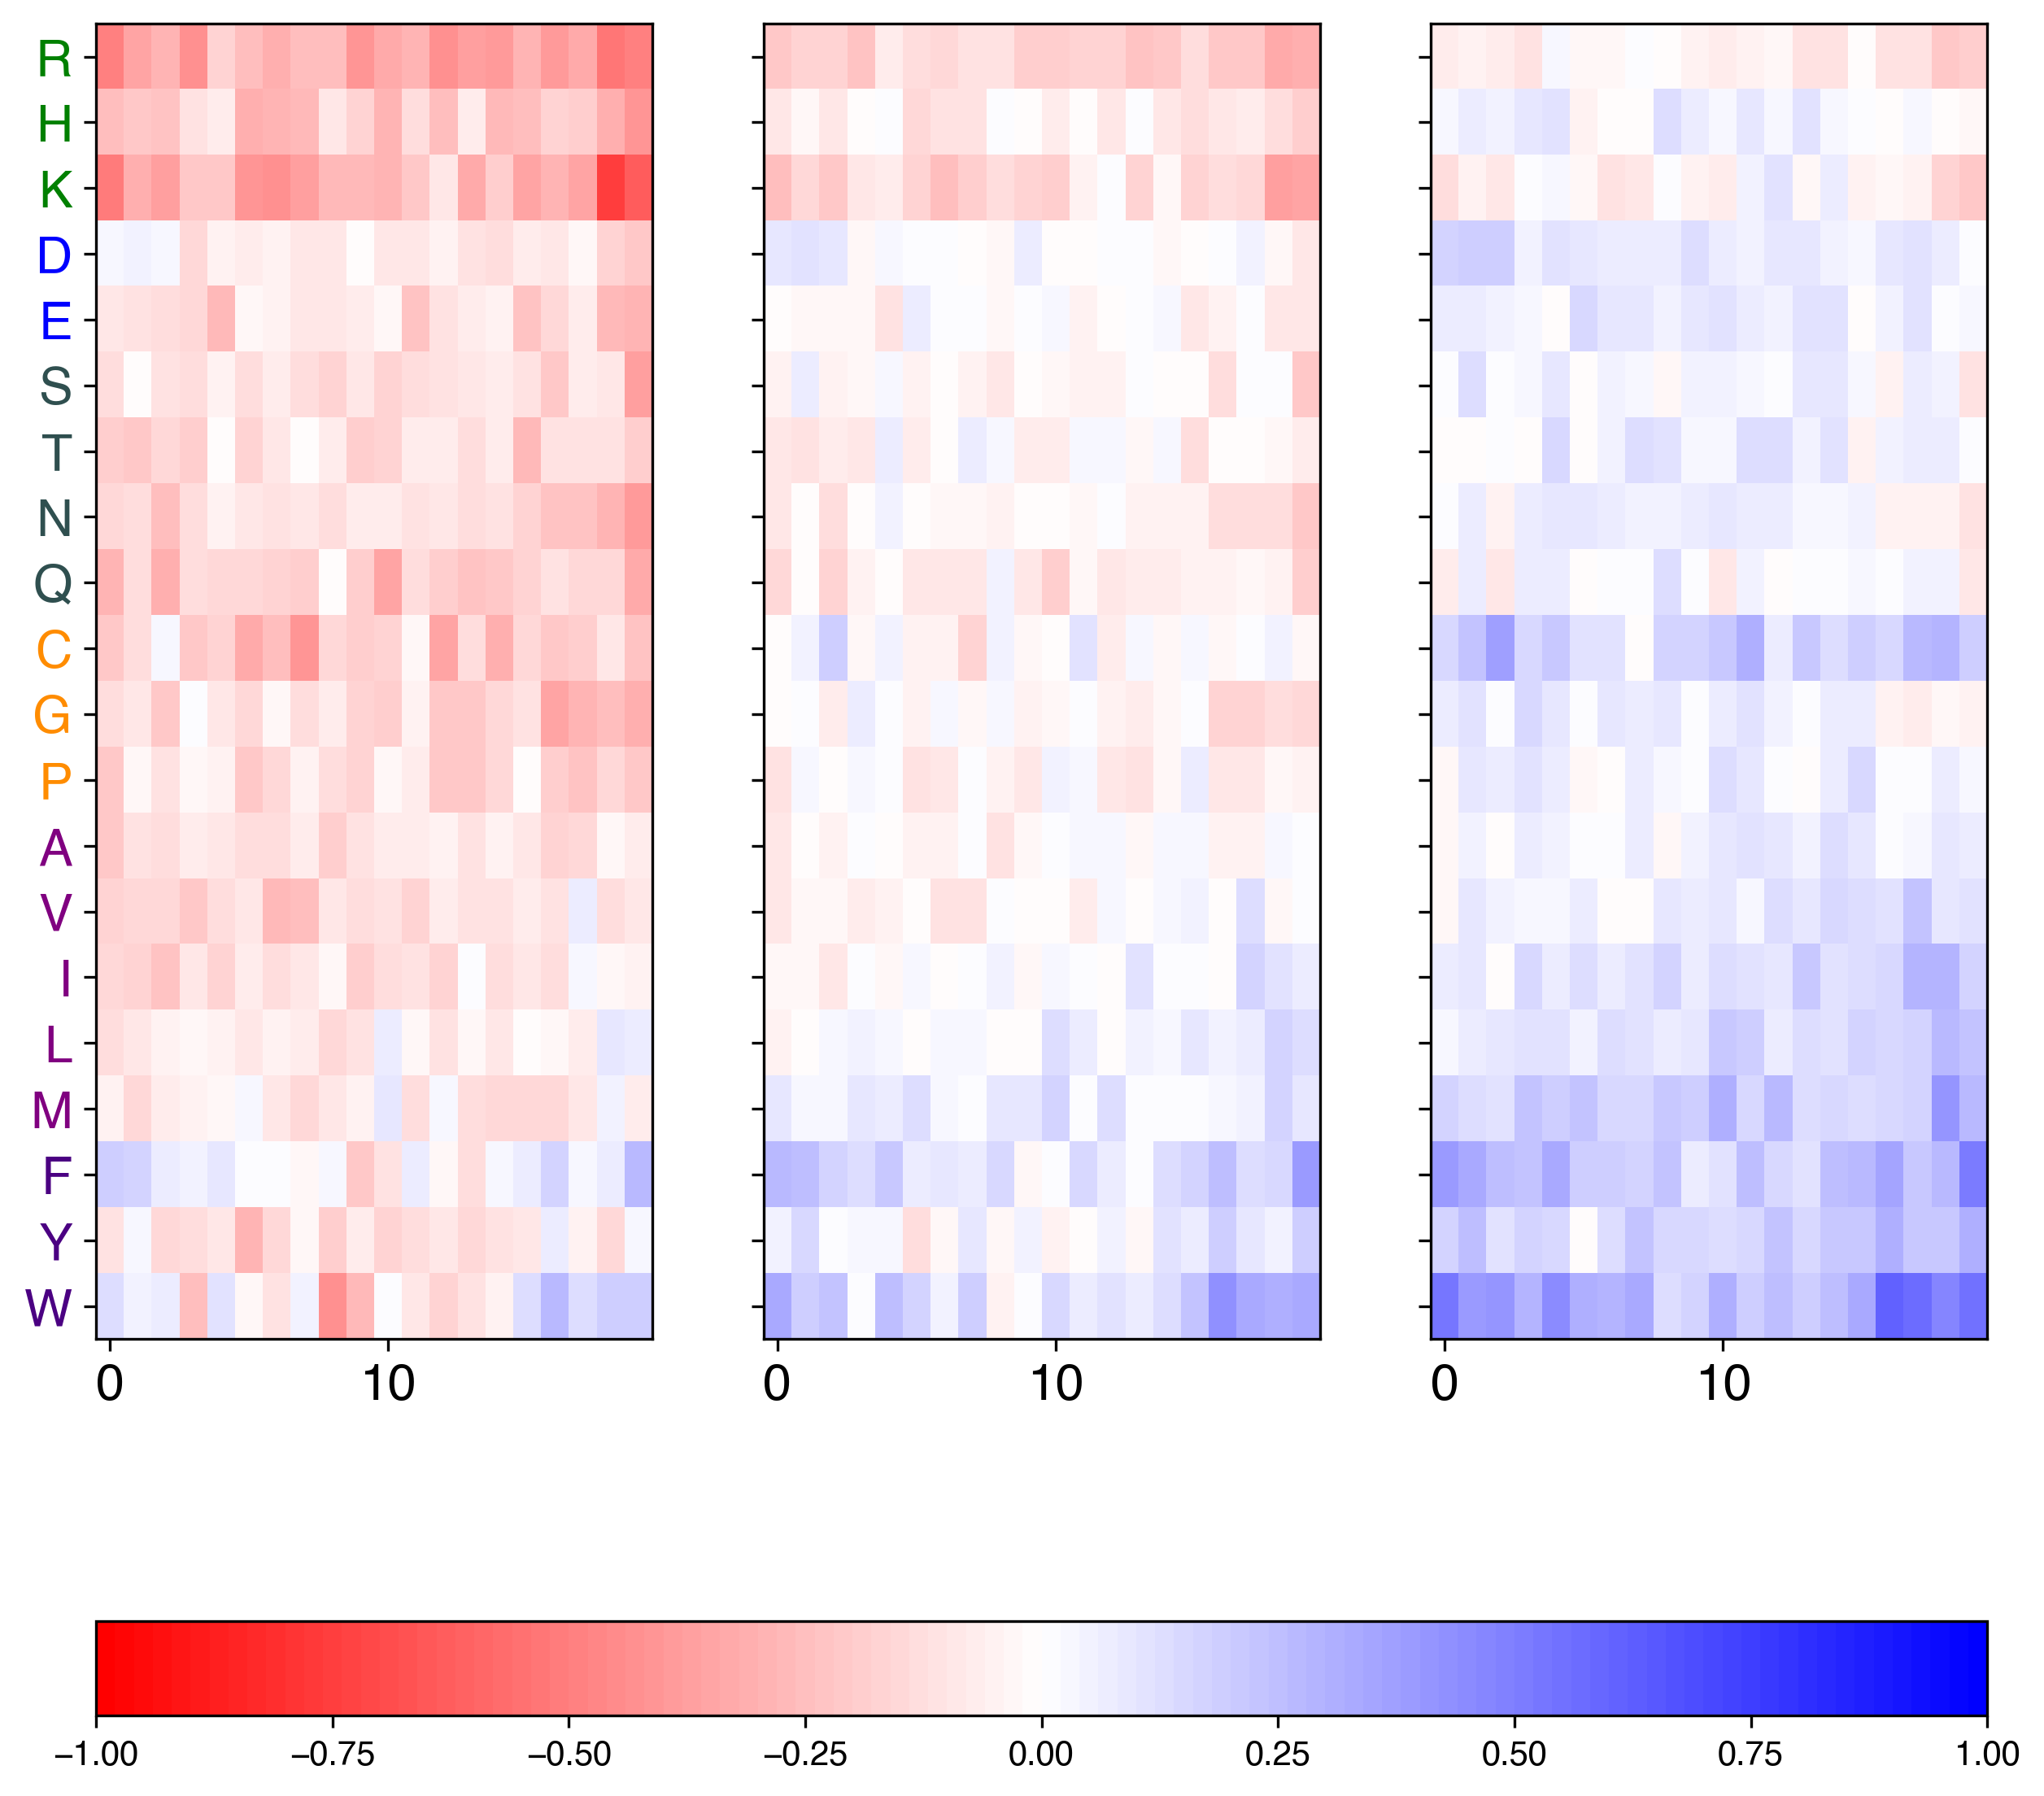

In [161]:
run_analysis(20, outfile_name="k20")

# Kernel size of 30

100%|██████████| 200/200 [00:00<00:00, 323.69it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


Bootstrap variance 0.005020671242410721
Seed variance 0.0041841967573904675


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(1, 30, 20) (1, 30, 20)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


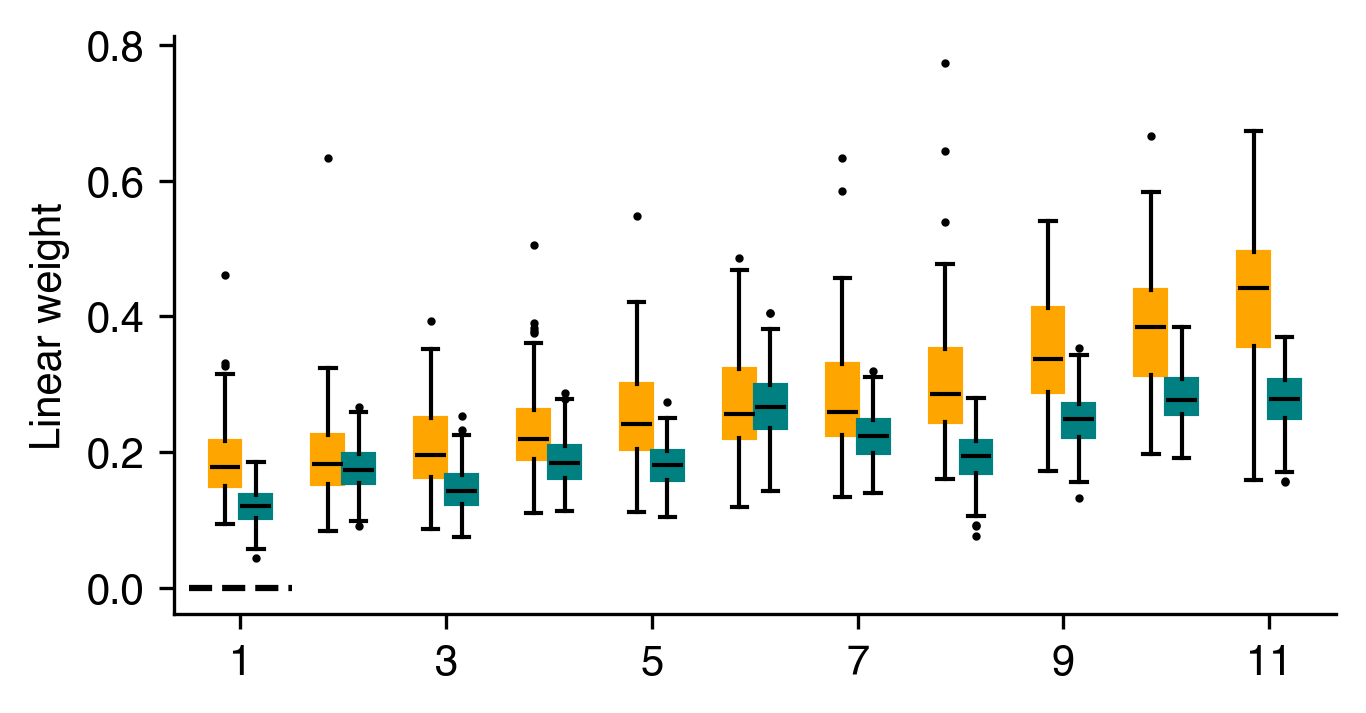

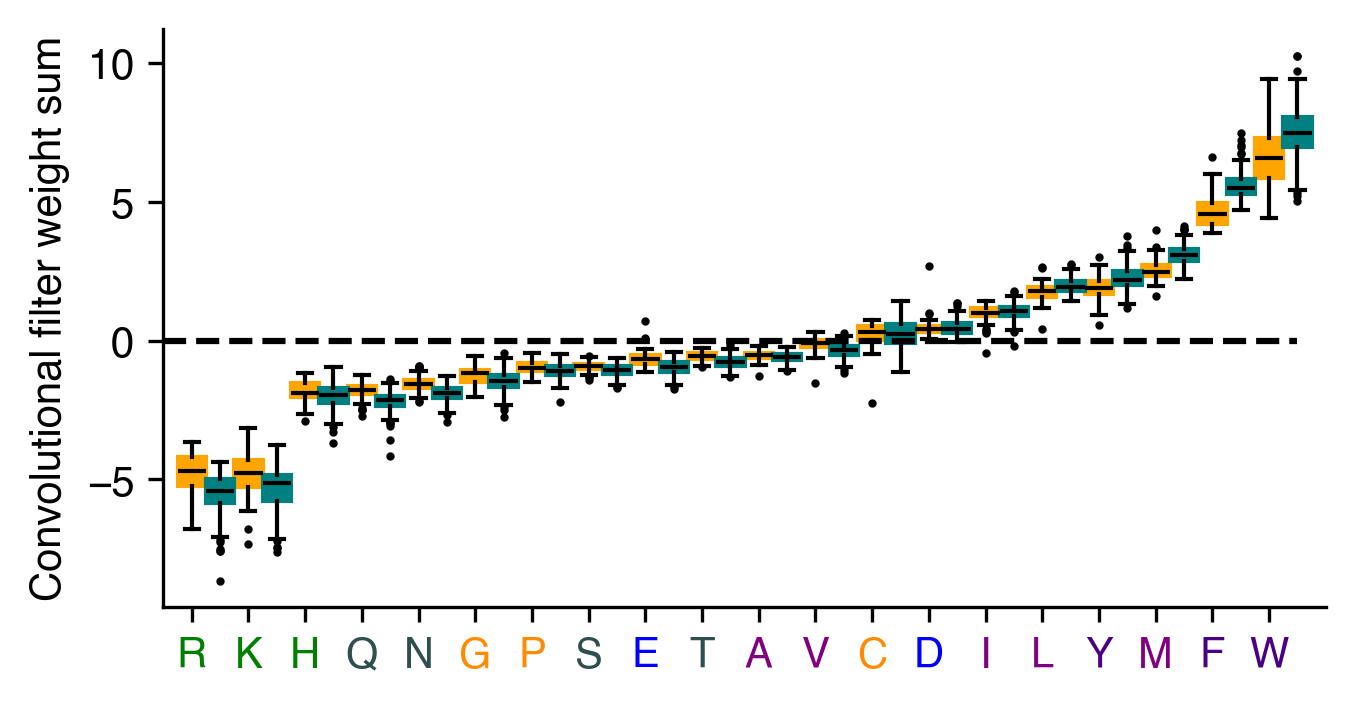

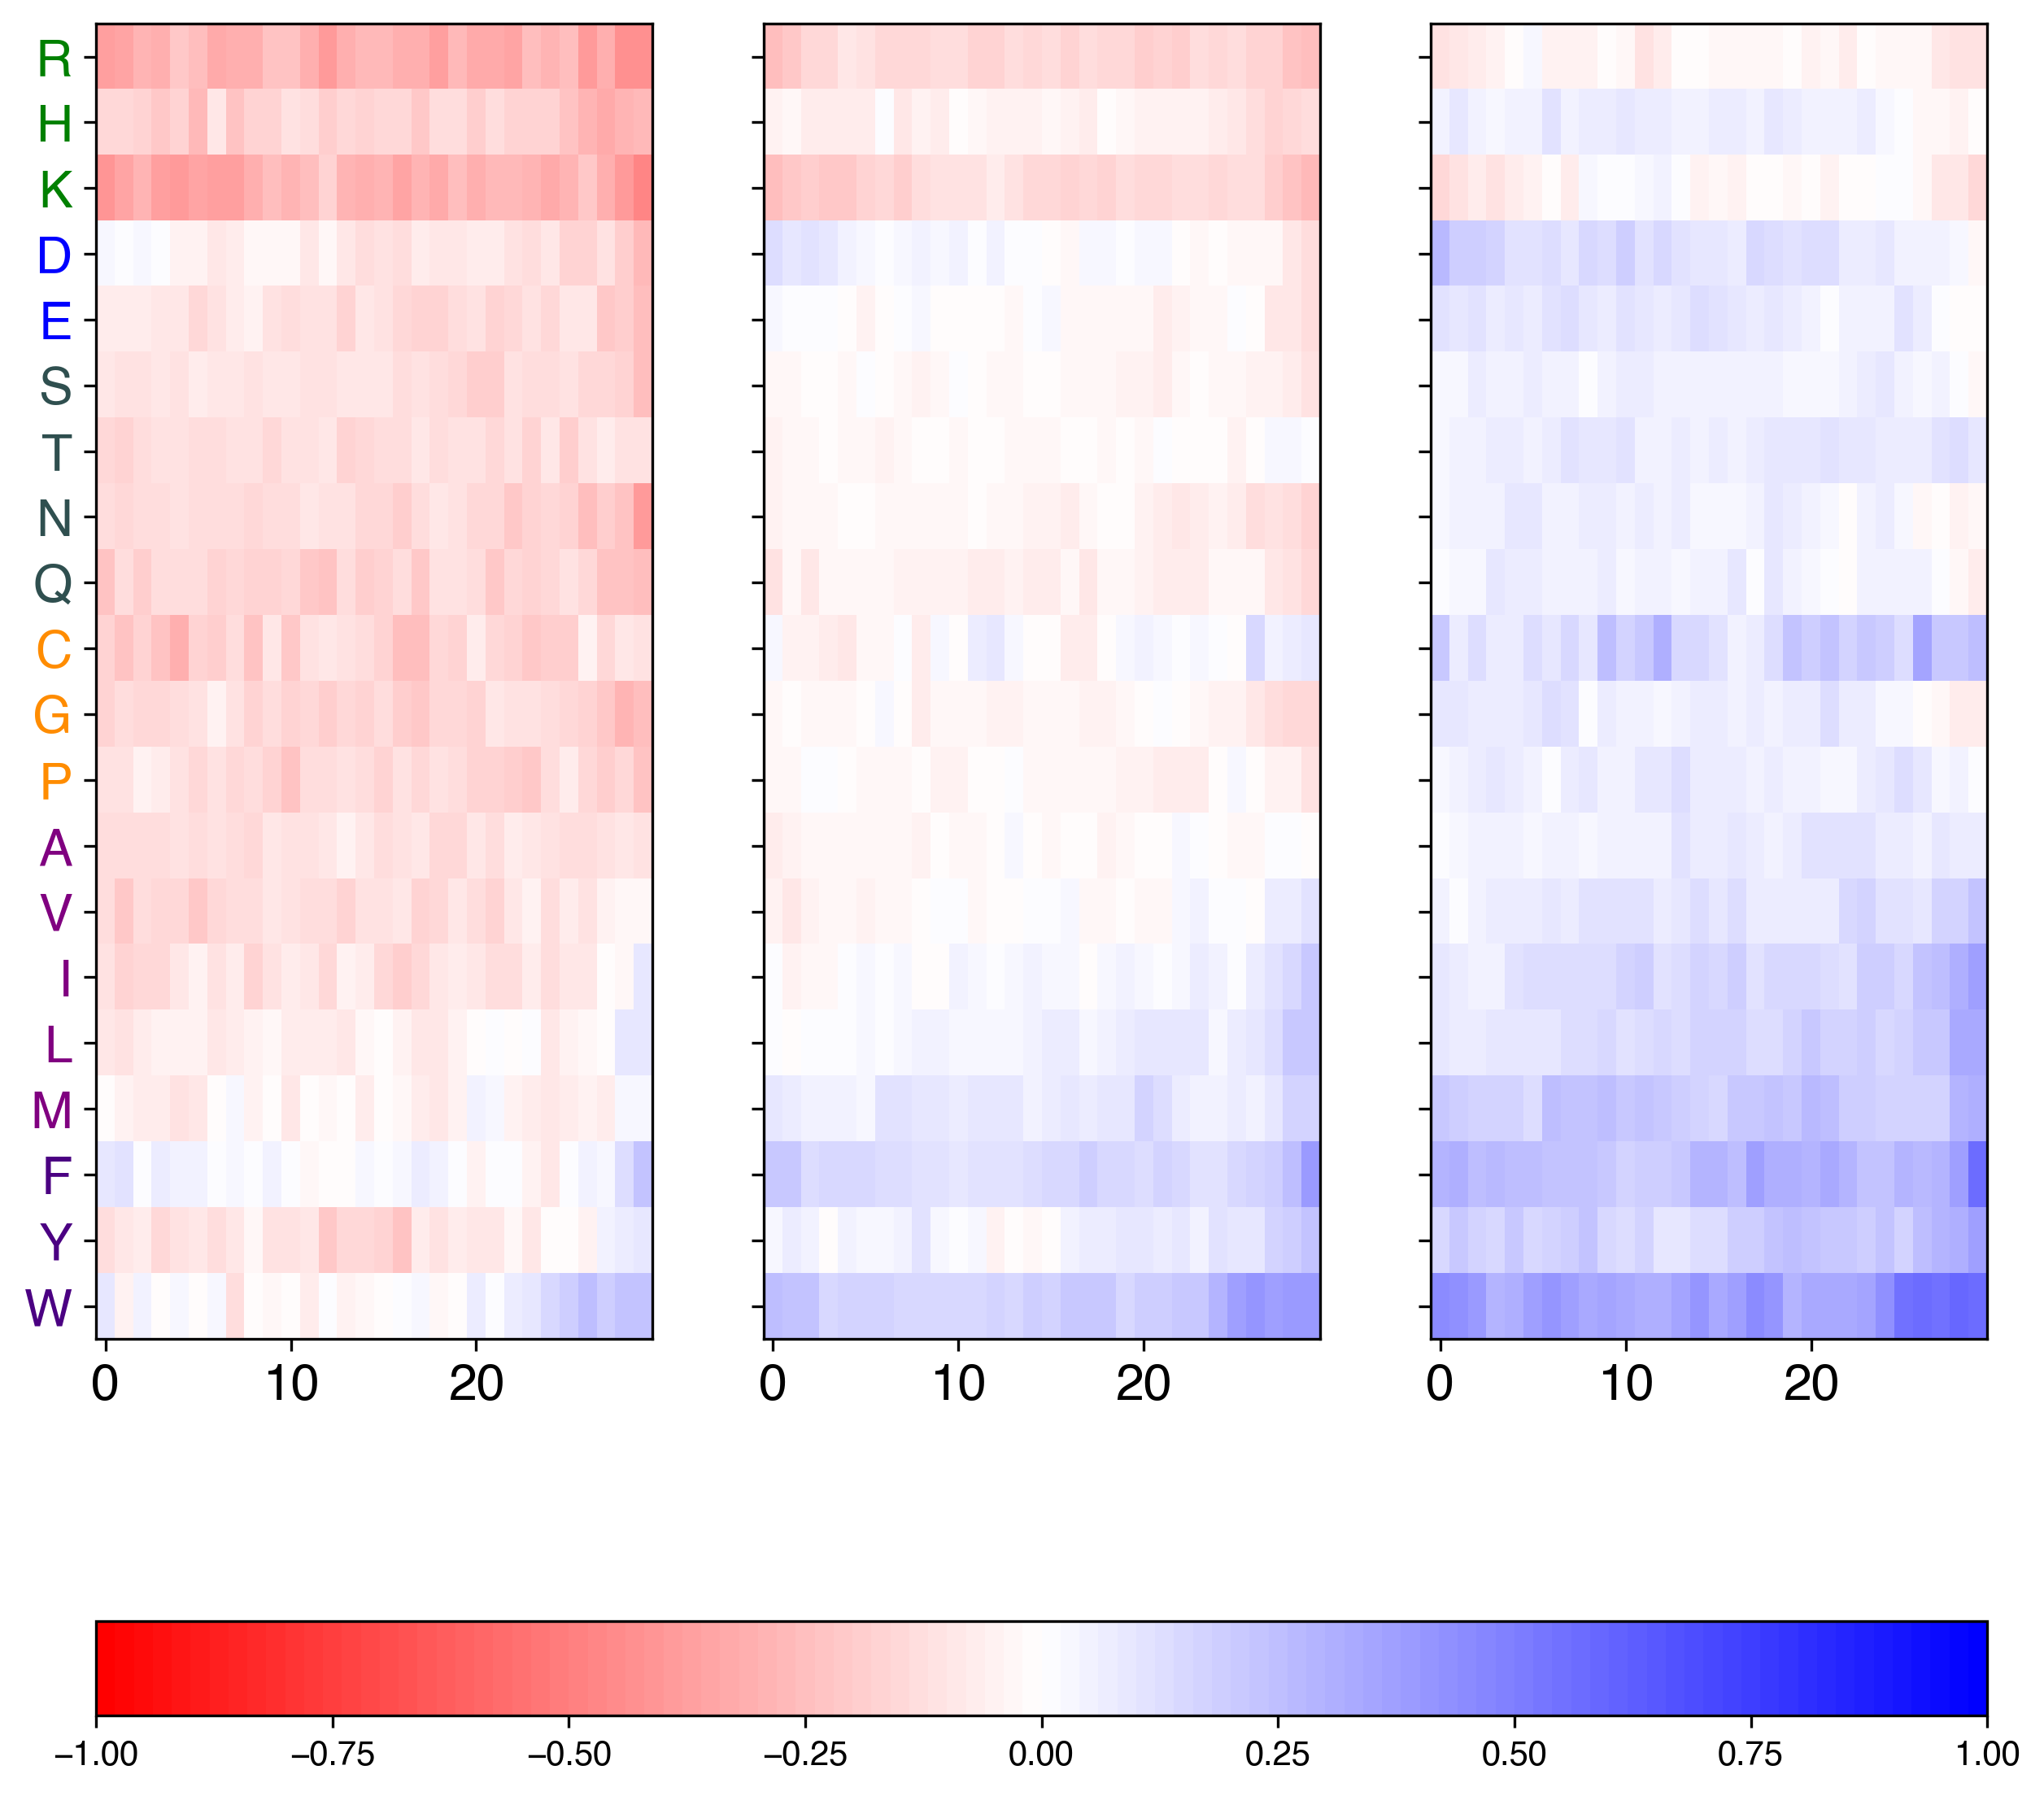

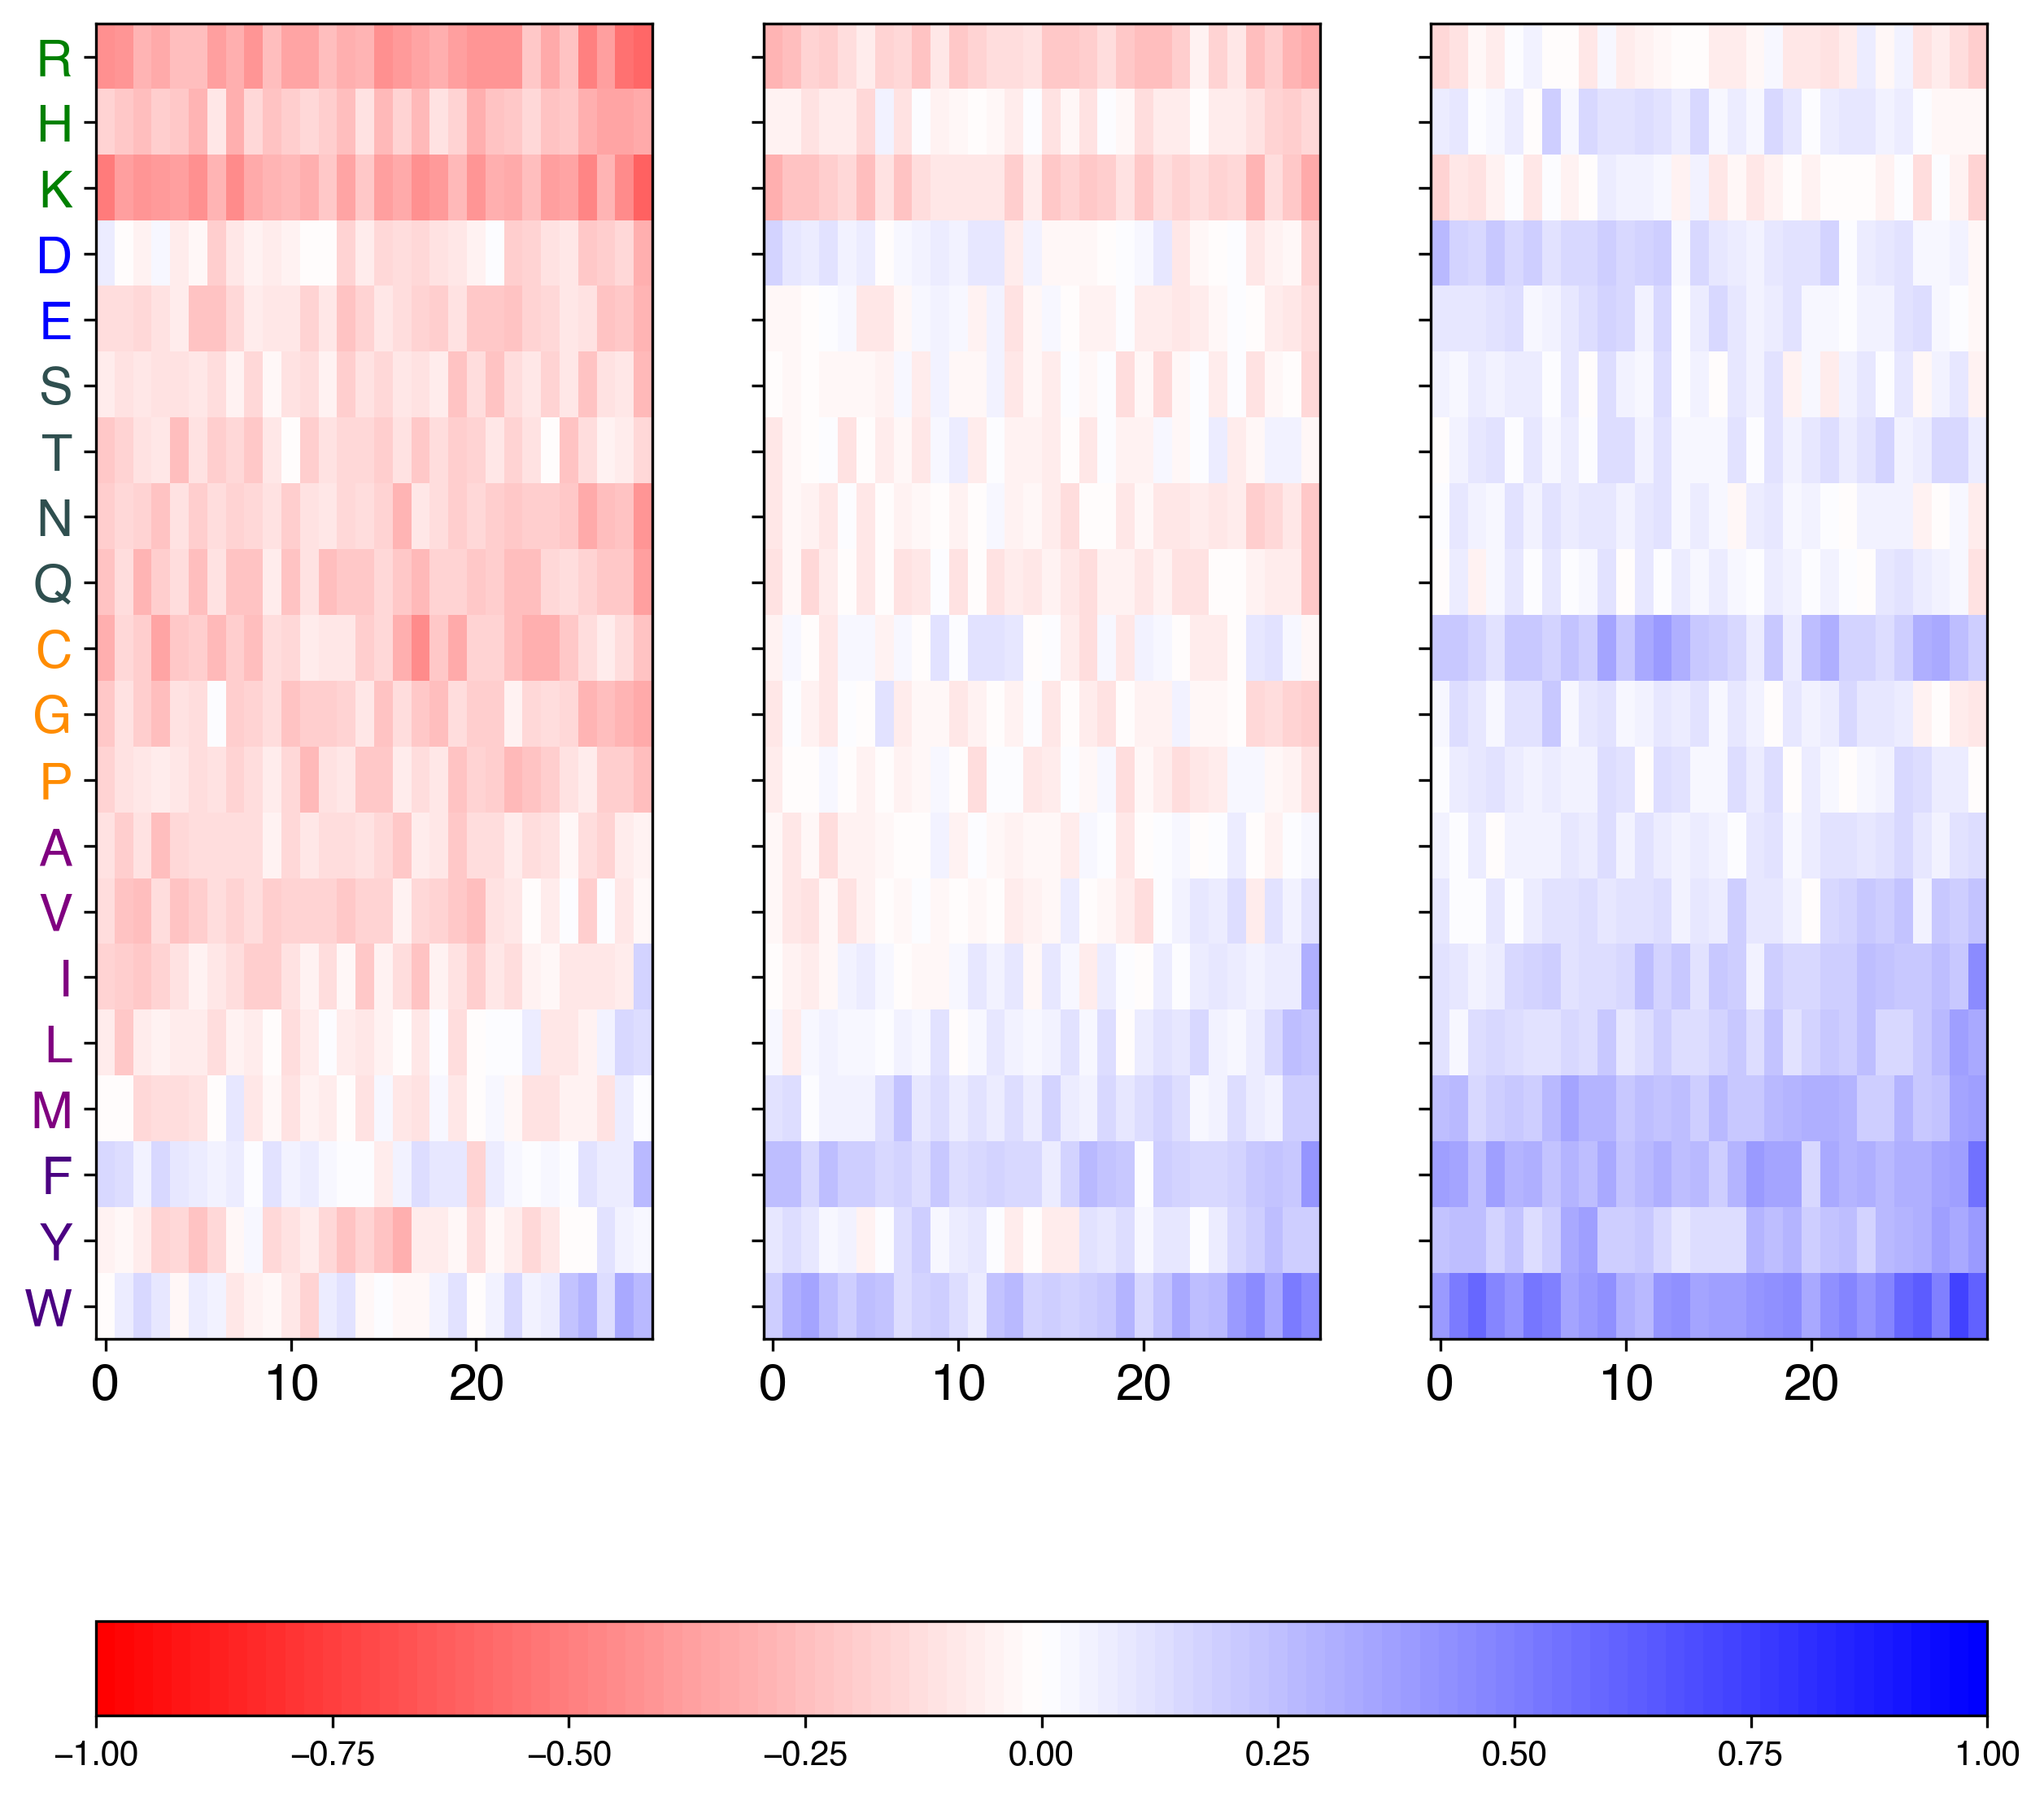

In [162]:
run_analysis(30, outfile_name="k30")

# K = 40

In [24]:
model_results['pearson_abund_test'].min()

0.3172572319690388

In [ ]:
run_analysis(40, outfile_name="k40")

# Make all weight heatmaps

In [10]:
def make_all_weight_heatmaps(k, model_results, bootstrap_results): 
    aa_order= ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    # Seed weight arrays
    seed_conv1_arr, seed_linear1_arr = get_weights_array(model_results, k_size=k, num_bootstraps=1, num_seeds=60, two_state=True, abund_k=False, layer1='conv1.weight', layer2='linear1.weight')

    neg1_mask = (seed_linear1_arr < 0).any(axis=-1)
    neg1_mask = neg1_mask.reshape(60)


    negative1_conv1_filters = seed_conv1_arr[:, neg1_mask, :, :]

    pos_conv1_filters = seed_conv1_arr[:, ~neg1_mask, :, :]

    lim = max(seed_conv1_arr.min(), seed_conv1_arr.max())

    # First plot -- Seed K1
    fig, axs = plt.subplots(2, 20, figsize=(20, 4), gridspec_kw={'height_ratios': [3, 1]})

    for i in range(0, 20):
        cax = axs[0, i].imshow(np.concatenate([pos_conv1_filters[0, :, :, i], negative1_conv1_filters[0, :, :, i]]), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
        axs[0, i].set_xticks([])
        axs[0, i].set_xlabel(aa_order[i])

        sim_matrix = cosine_similarity(seed_conv1_arr[0, :, :, i])
        lower_vals = sim_matrix[np.tril_indices(sim_matrix.shape[0], k=-1)]
        axs[1, i].hist(lower_vals)
        axs[1, i].text(0.05, 0.7, f"{np.abs(lower_vals).mean():.2}", transform=axs[1, i].transAxes)
        axs[1, i].set_xlabel(aa_order[i])
        if i != 0:
            axs[0, i].tick_params(labelleft=False)
            axs[1,i].sharey(axs[1,0])
            axs[1,i].sharex(axs[1,0])
            # axs[1, i].set_yticks([])
            axs[1, i].tick_params(labelleft=False)
        else:
            axs[0, 0].set_ylabel("NNs")
            axs[1, 0].set_ylabel("Count")
            axs[1, 0].set_xlim(-1, 1)


    fig.supxlabel("Cosine similarity between weights per amino acid", y=-0.1)
    fig.suptitle(r"NN weights per amino acid for predicting $K_{bound}$. NNs were trained with different seeds")

    # fig.tight_layout()
    plt.savefig(f"figures/for_revision/k{k}_conv1_two_state_seed_all_weights.pdf", format='pdf', bbox_inches='tight')


    # bootstrap weight arrays
    boostrap_conv1_arr, bootstrap_linear1_arr = get_weights_array(bootstrap_results[bootstrap_results['seed'] == 1298091], k_size=k, num_bootstraps=200, num_seeds=1, two_state=True, abund_k=False, layer1='conv1.weight', layer2='linear1.weight')

    neg1_mask = (bootstrap_linear1_arr < 0).any(axis=-1)
    neg1_mask = neg1_mask.reshape(200)

    negative1_conv1_filters = boostrap_conv1_arr[neg1_mask, :, :, :]
    pos_conv1_filters = boostrap_conv1_arr[~neg1_mask, :, :, :]

    lim = max(boostrap_conv1_arr.min(), boostrap_conv1_arr.max())

    # Plotting bootstrap K1
    fig, axs = plt.subplots(2, 20, figsize=(20, 4), gridspec_kw={'height_ratios': [3, 1]})

    for i in range(0, 20):
        cax = axs[0, i].imshow(np.concatenate([pos_conv1_filters[:, 0, :, i], negative1_conv1_filters[:, 0, :, i]]), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
        axs[0, i].set_xticks([])
        axs[0, i].set_xlabel(aa_order[i])

        sim_matrix = cosine_similarity(boostrap_conv1_arr[:, 0, :, i])
        lower_vals = sim_matrix[np.tril_indices(sim_matrix.shape[0], k=-1)]
        axs[1, i].hist(lower_vals)
        axs[1, i].text(0.05, .7, f"{np.abs(lower_vals).mean():.2}", transform=axs[1, i].transAxes)
        axs[1, i].set_xlabel(aa_order[i])
        if i != 0:
            axs[0, i].tick_params(labelleft=False)
            axs[1,i].sharey(axs[1,0])
            axs[1,i].sharex(axs[1,0])
            # axs[1, i].set_yticks([])
            axs[1, i].tick_params(labelleft=False)
        else:
            axs[0, 0].set_ylabel("NNs")
            axs[1, 0].set_ylabel("Count")
            axs[1, 0].set_xlim(-1, 1)


    fig.supxlabel("Cosine similarity between weights per amino acid", y=-0.1)
    fig.suptitle(r"NN weights per amino acid for predicting $K_{bound}$. NNs were trained with bootstrapped data")

    # fig.tight_layout()
    plt.savefig(f"figures/for_revision/k{k}_conv1_two_state_bootstrap_all_weights.pdf", format='pdf', bbox_inches='tight')

    # Plotting all histograms
    fig, axs = plt.subplots(1, 20, figsize=(20, 1))
    bins = np.arange(-1.1, 1.1, 0.1)
    for i in range(0, 20):
        sim_matrix = cosine_similarity(boostrap_conv1_arr[:, 0, :, i])
        lower_vals = sim_matrix[np.tril_indices(sim_matrix.shape[0], k=-1)]
        axs[i].hist(lower_vals, density=True, bins=bins, color='teal')
        axs[i].text(0.05, .6, f"{np.abs(lower_vals).mean():.2}", transform=axs[i].transAxes, color='teal')
        axs[i].set_xlabel(aa_order[i])
        if i != 0:
            axs[i].tick_params(labelleft=False)
            axs[i].sharey(axs[0])
            axs[i].sharex(axs[0])
            # axs[1, i].set_yticks([])
            axs[i].tick_params(labelleft=False)
        else:
            axs[0].set_ylabel("Count")
            axs[0].set_xlim(-1, 1)

        sim_matrix = cosine_similarity(seed_conv1_arr[0, :, :, i])
        lower_vals = sim_matrix[np.tril_indices(sim_matrix.shape[0], k=-1)]
        axs[i].hist(lower_vals, density=True, bins=bins, color='orange', alpha=0.5)
        axs[i].text(0.05, .8, f"{np.abs(lower_vals).mean():.2}", transform=axs[i].transAxes, color='orange')
        axs[i].set_xlabel(aa_order[i])
        if i != 0:
            axs[i].tick_params(labelleft=False)
            axs[i].sharey(axs[0])
            axs[i].sharex(axs[0])
            # axs[1, i].set_yticks([])
            axs[i].tick_params(labelleft=False)
        else:
            axs[0].set_ylabel("Count")
            axs[0].set_xlim(-1, 1)


    fig.supxlabel("Cosine similarity between weights per amino acid", y=-0.5)
    fig.suptitle(f"Filter size = {k}", y=1.1)

    # fig.tight_layout()
    plt.savefig(f"figures/for_revision/k{k}_two_state_conv1_histograms.pdf", format='pdf', bbox_inches='tight')



100%|██████████| 60/60 [00:00<00:00, 431.25it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
100%|██████████| 200/200 [00:00<00:00, 559.08it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


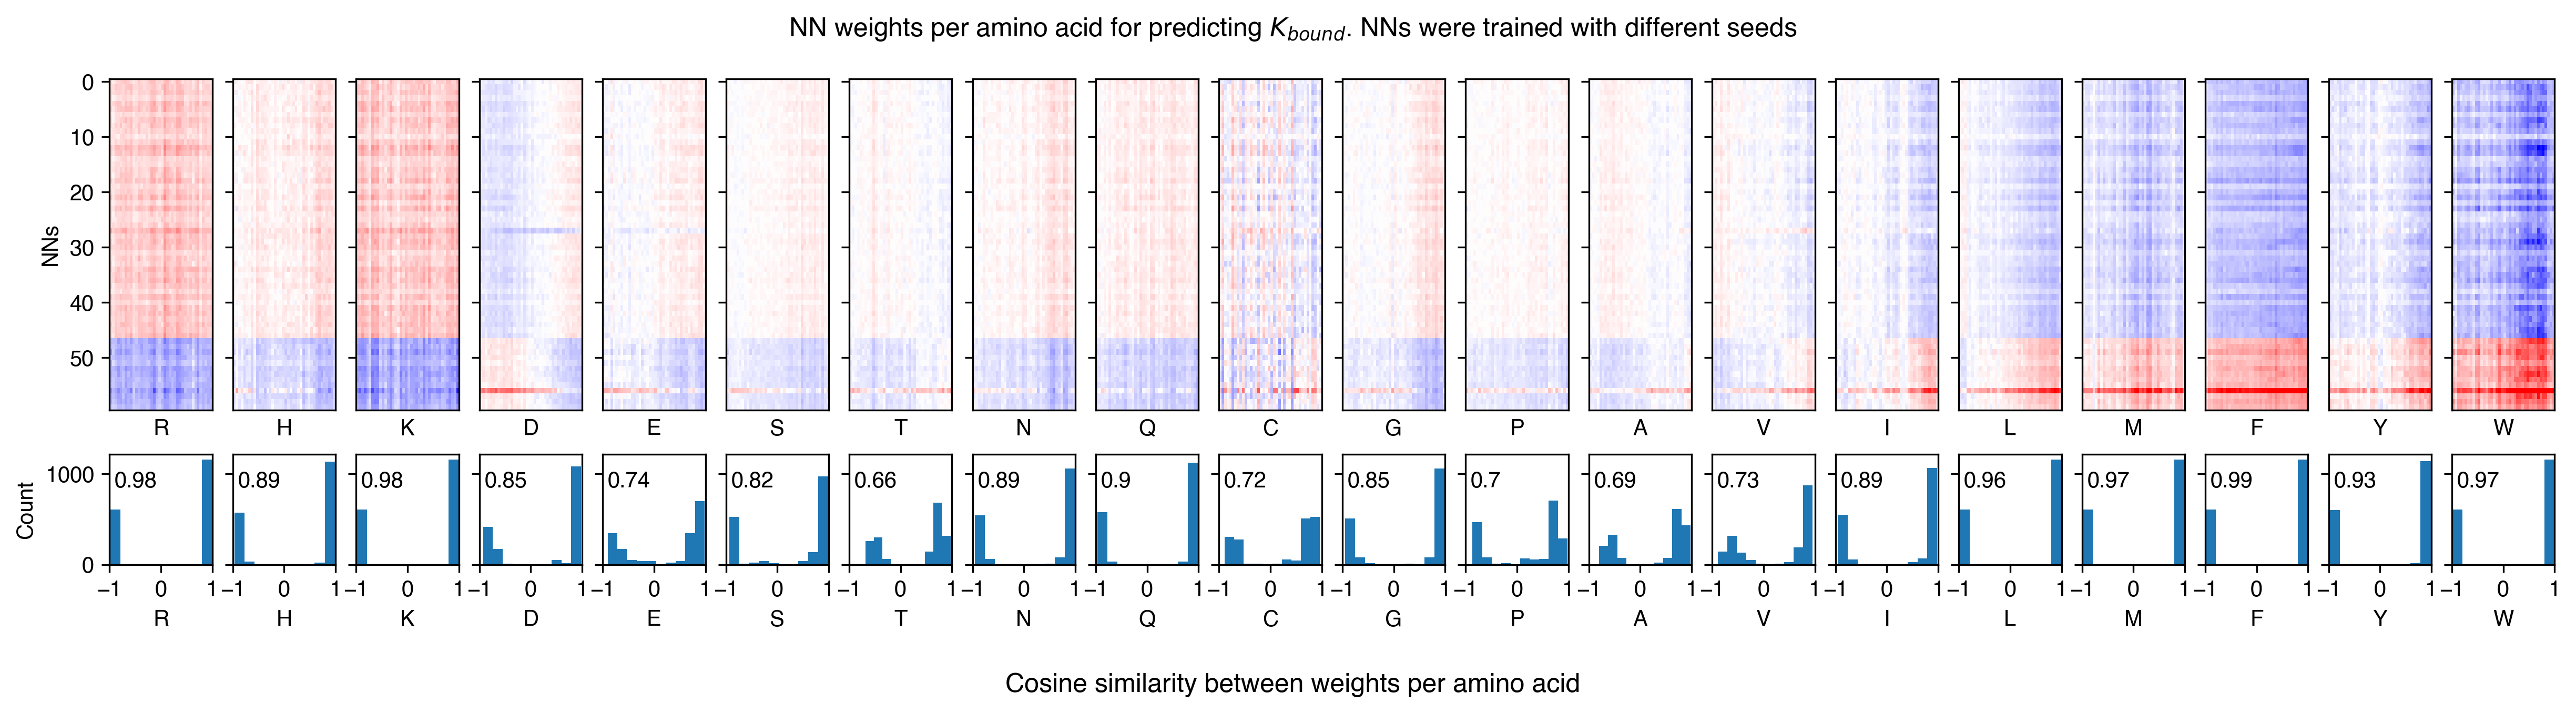

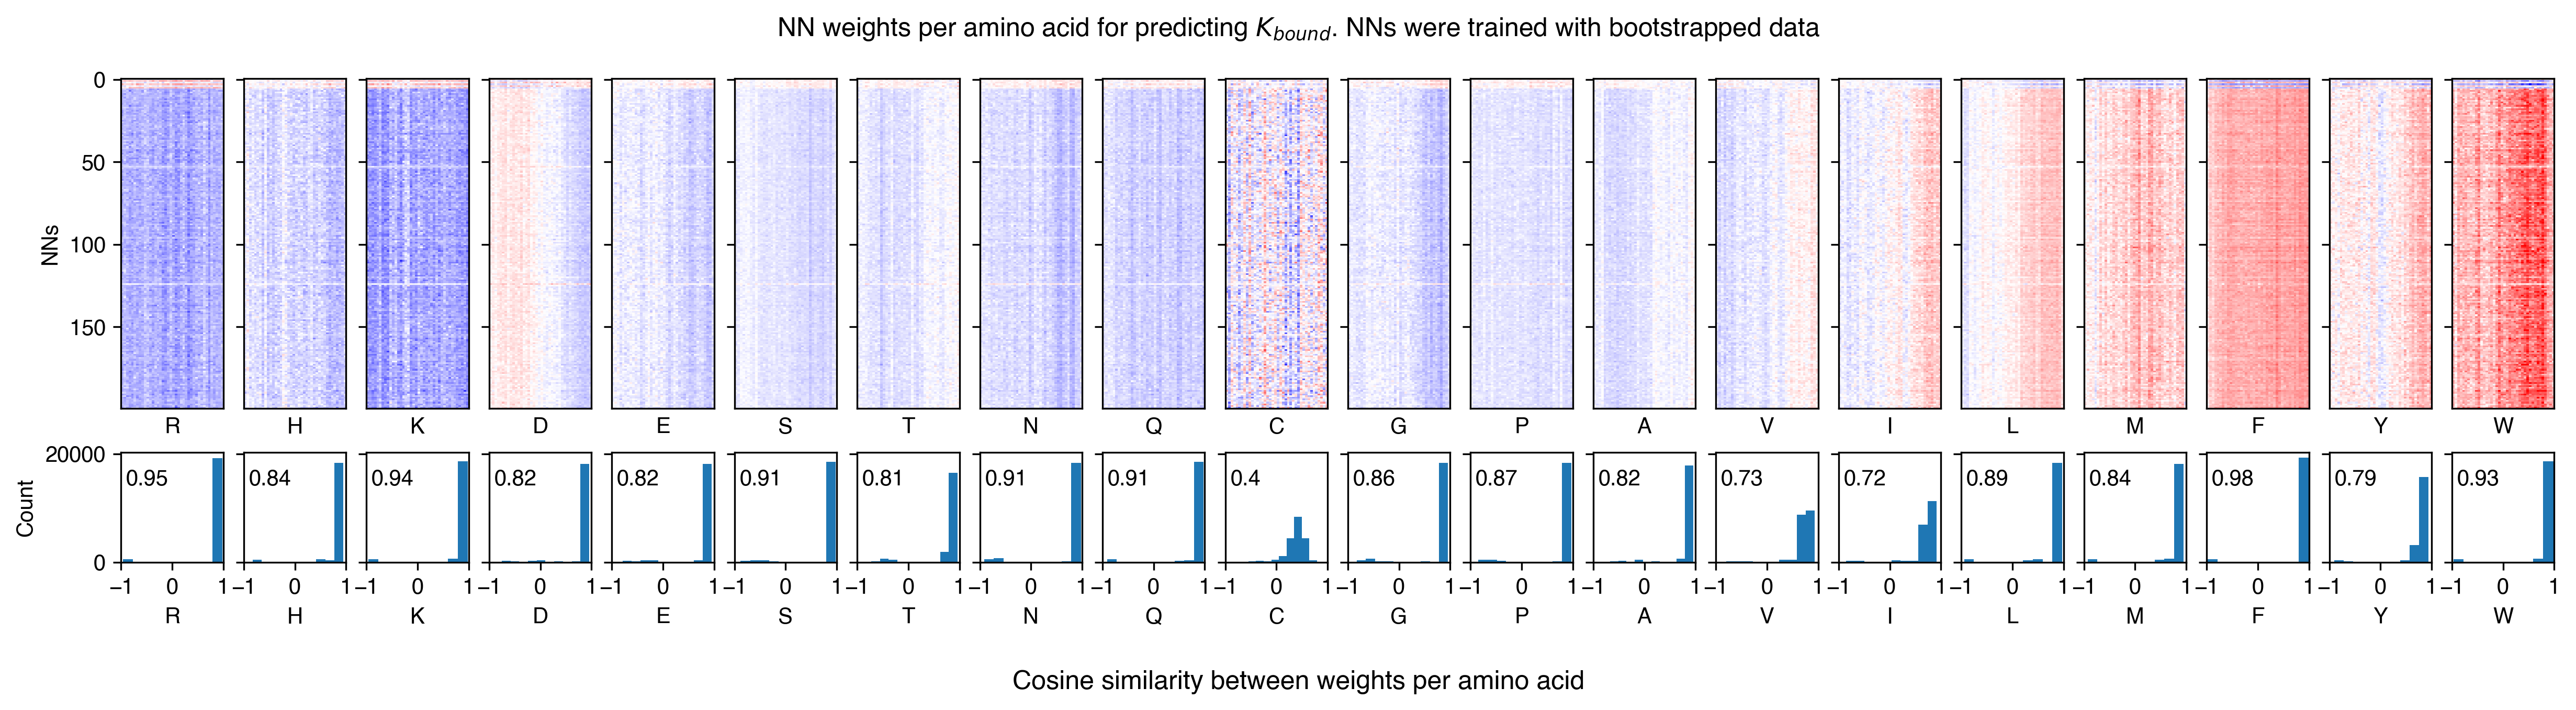

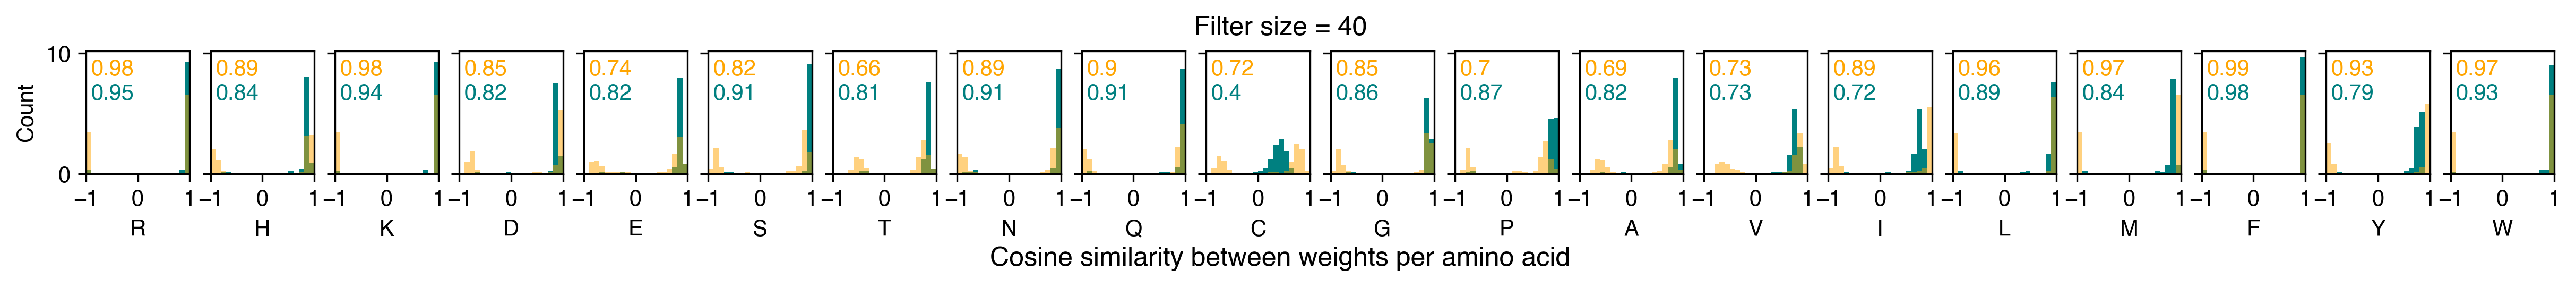

In [11]:
# TO DO: SAVE WEIGHTS so we don't have to reload every time
make_all_weight_heatmaps(40, model_results, bootstrap_results)

100%|██████████| 60/60 [00:00<00:00, 481.59it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
100%|██████████| 200/200 [00:00<00:00, 584.26it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


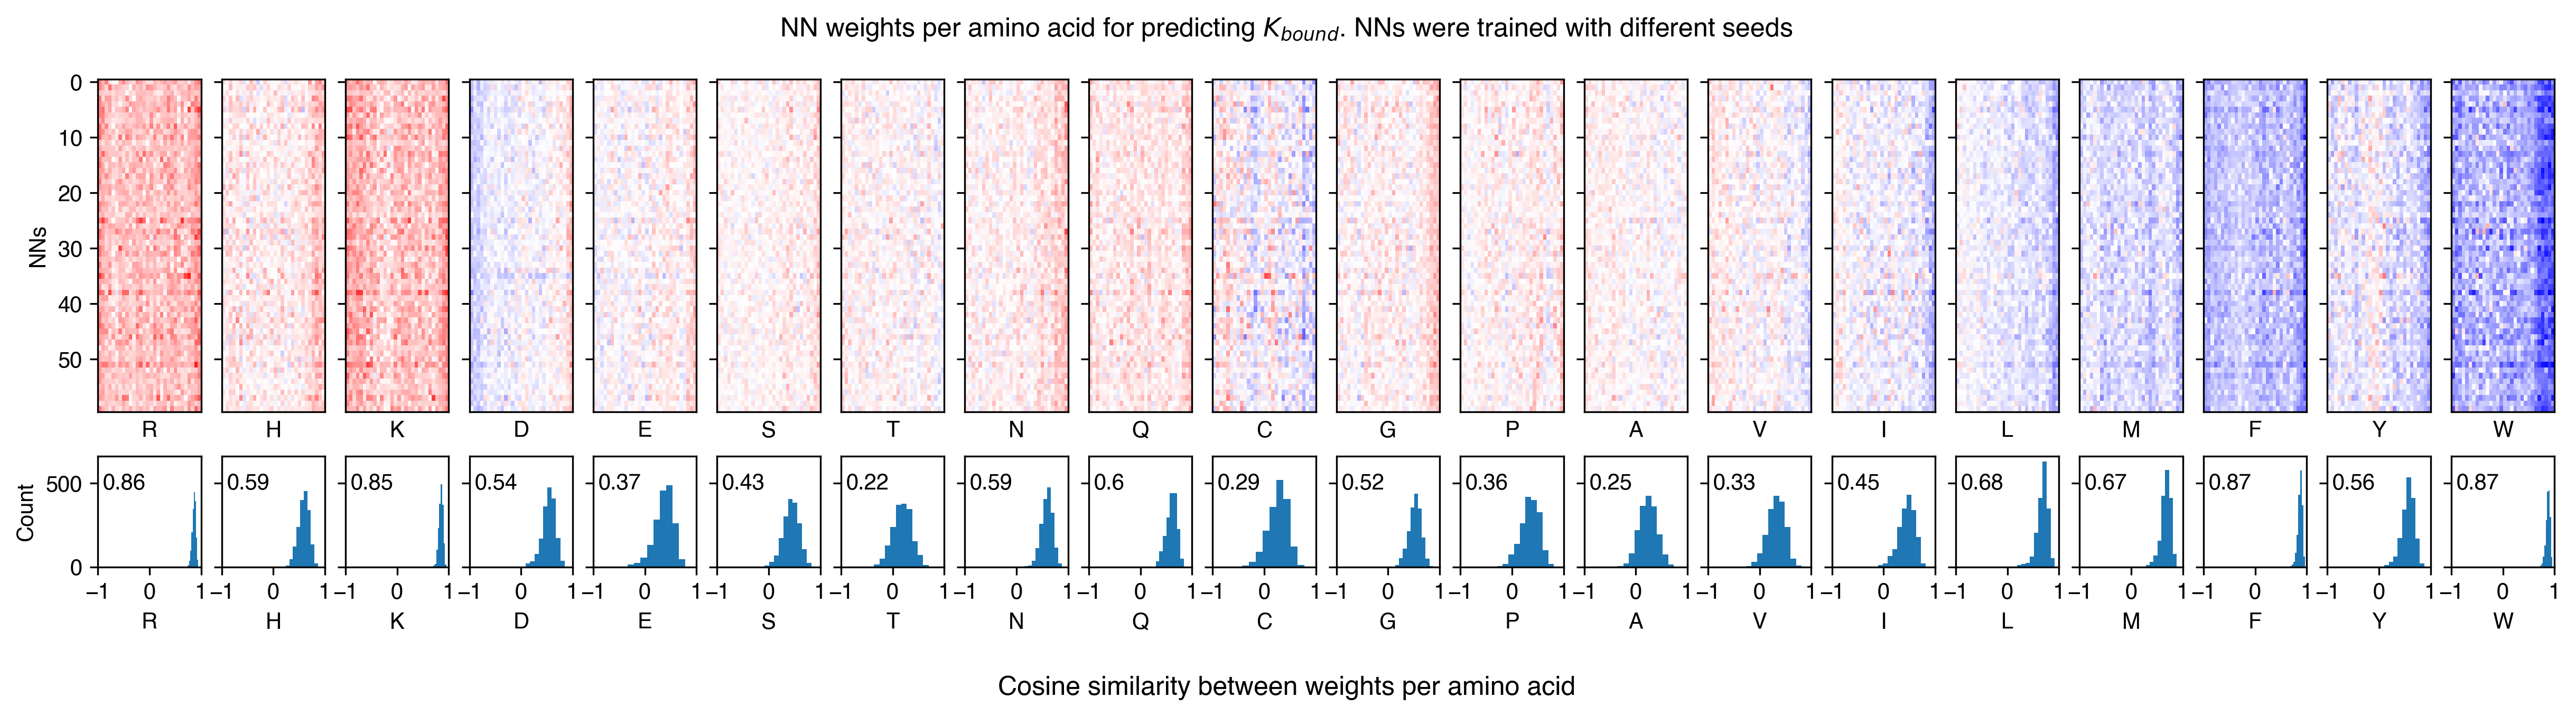

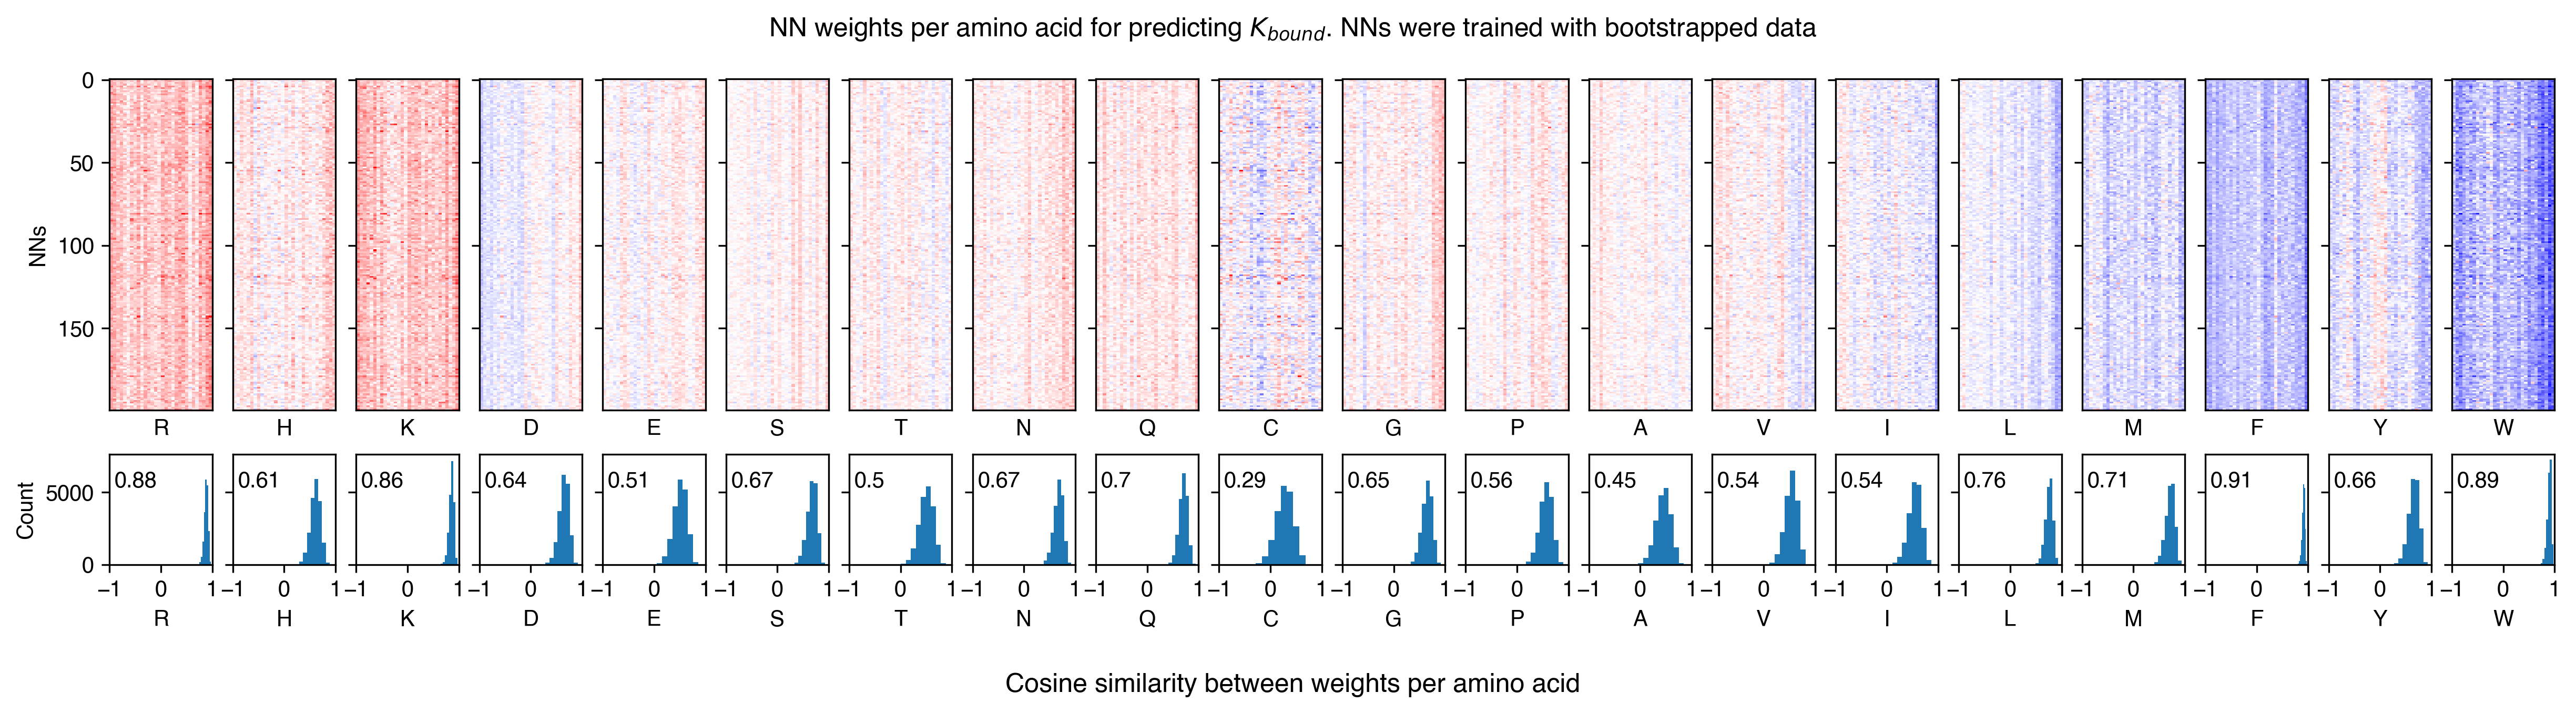

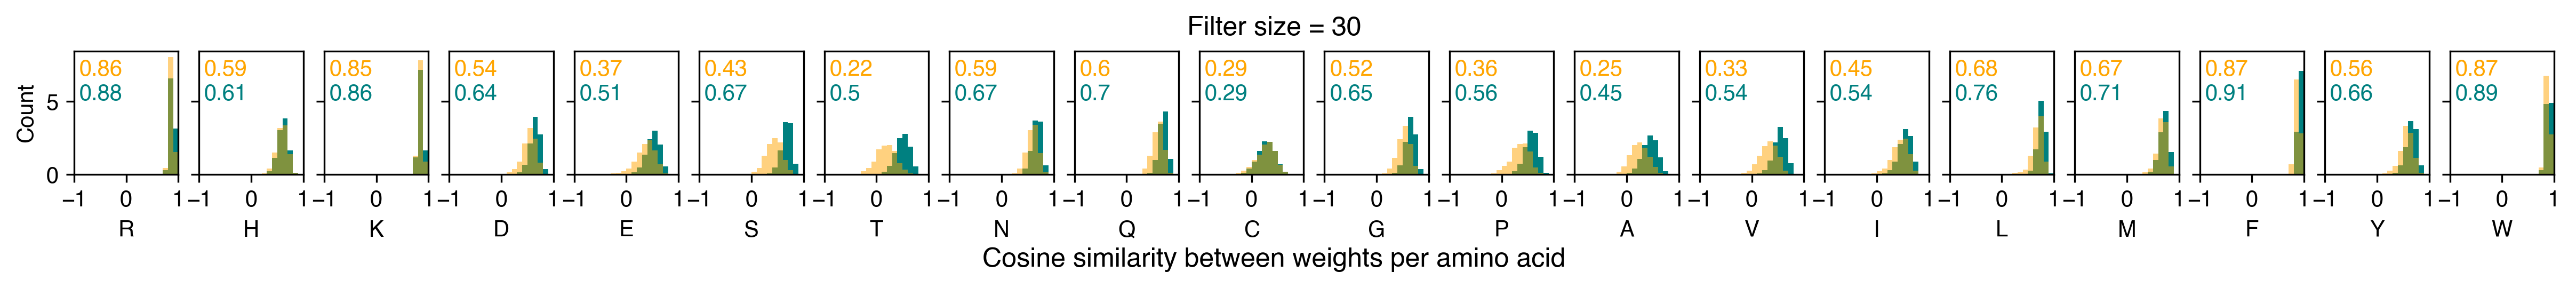

In [12]:
make_all_weight_heatmaps(30, model_results, bootstrap_results)

100%|██████████| 60/60 [00:00<00:00, 501.18it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
100%|██████████| 200/200 [00:00<00:00, 564.62it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


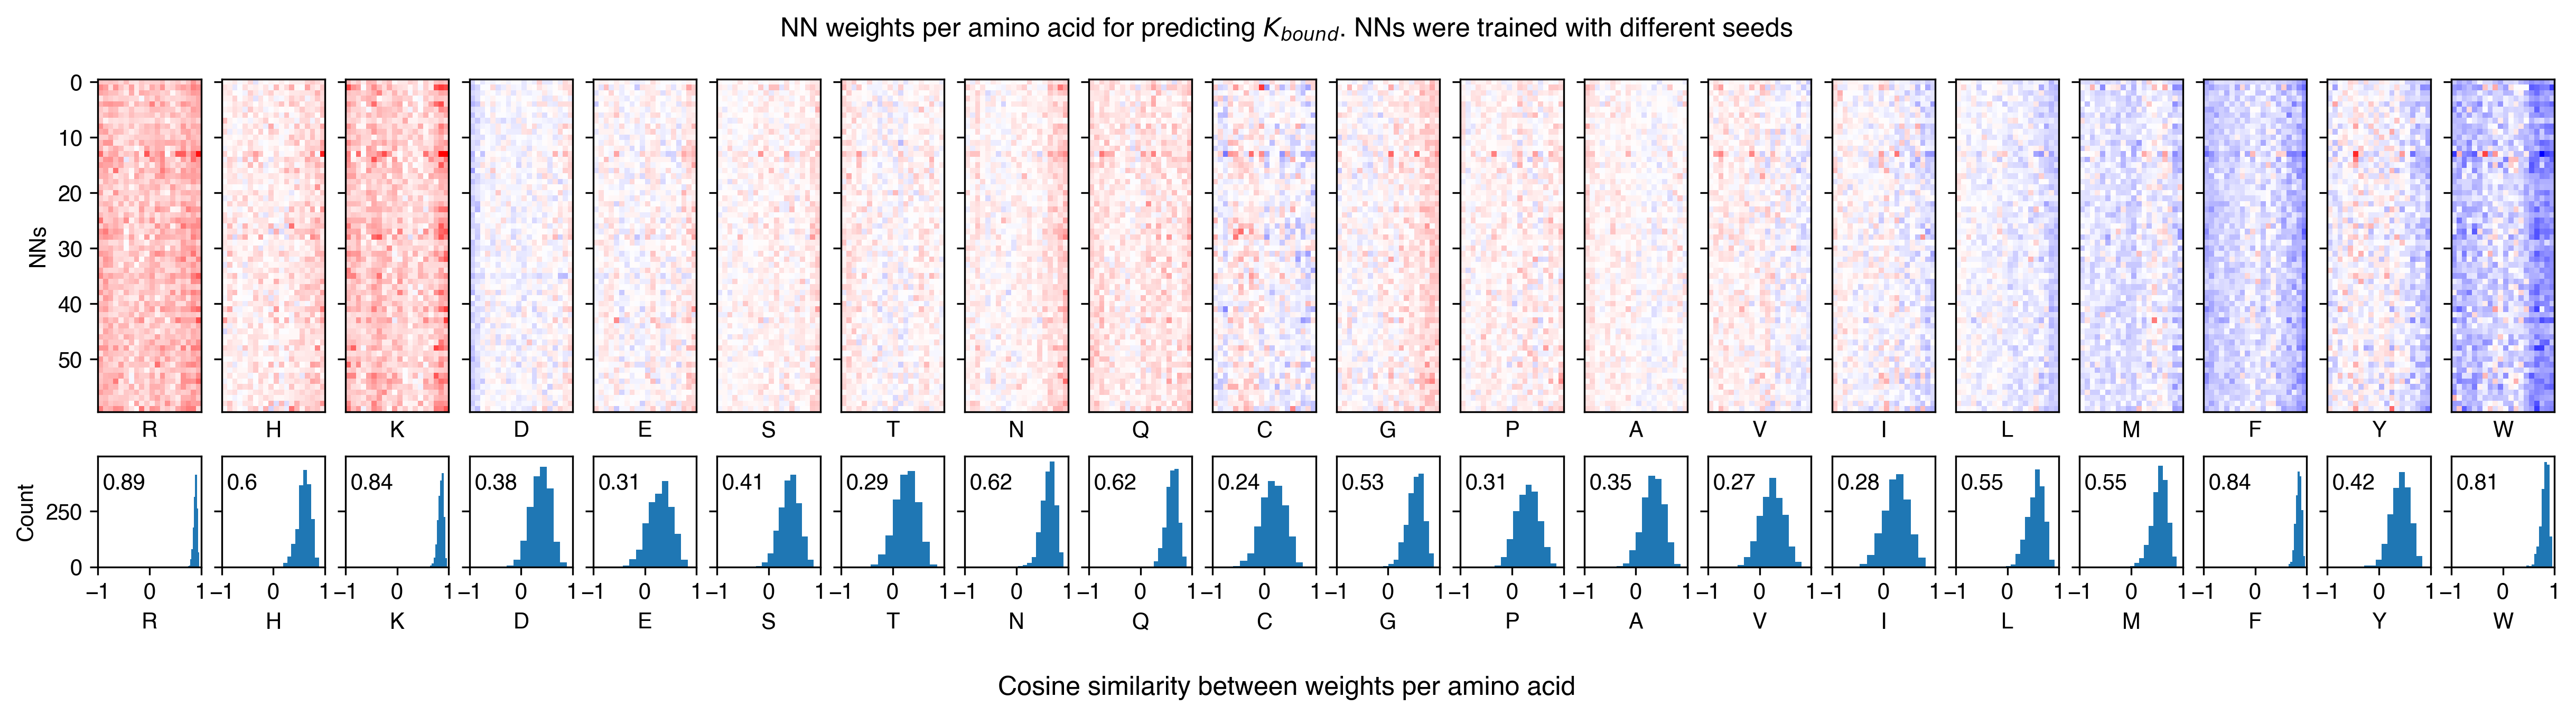

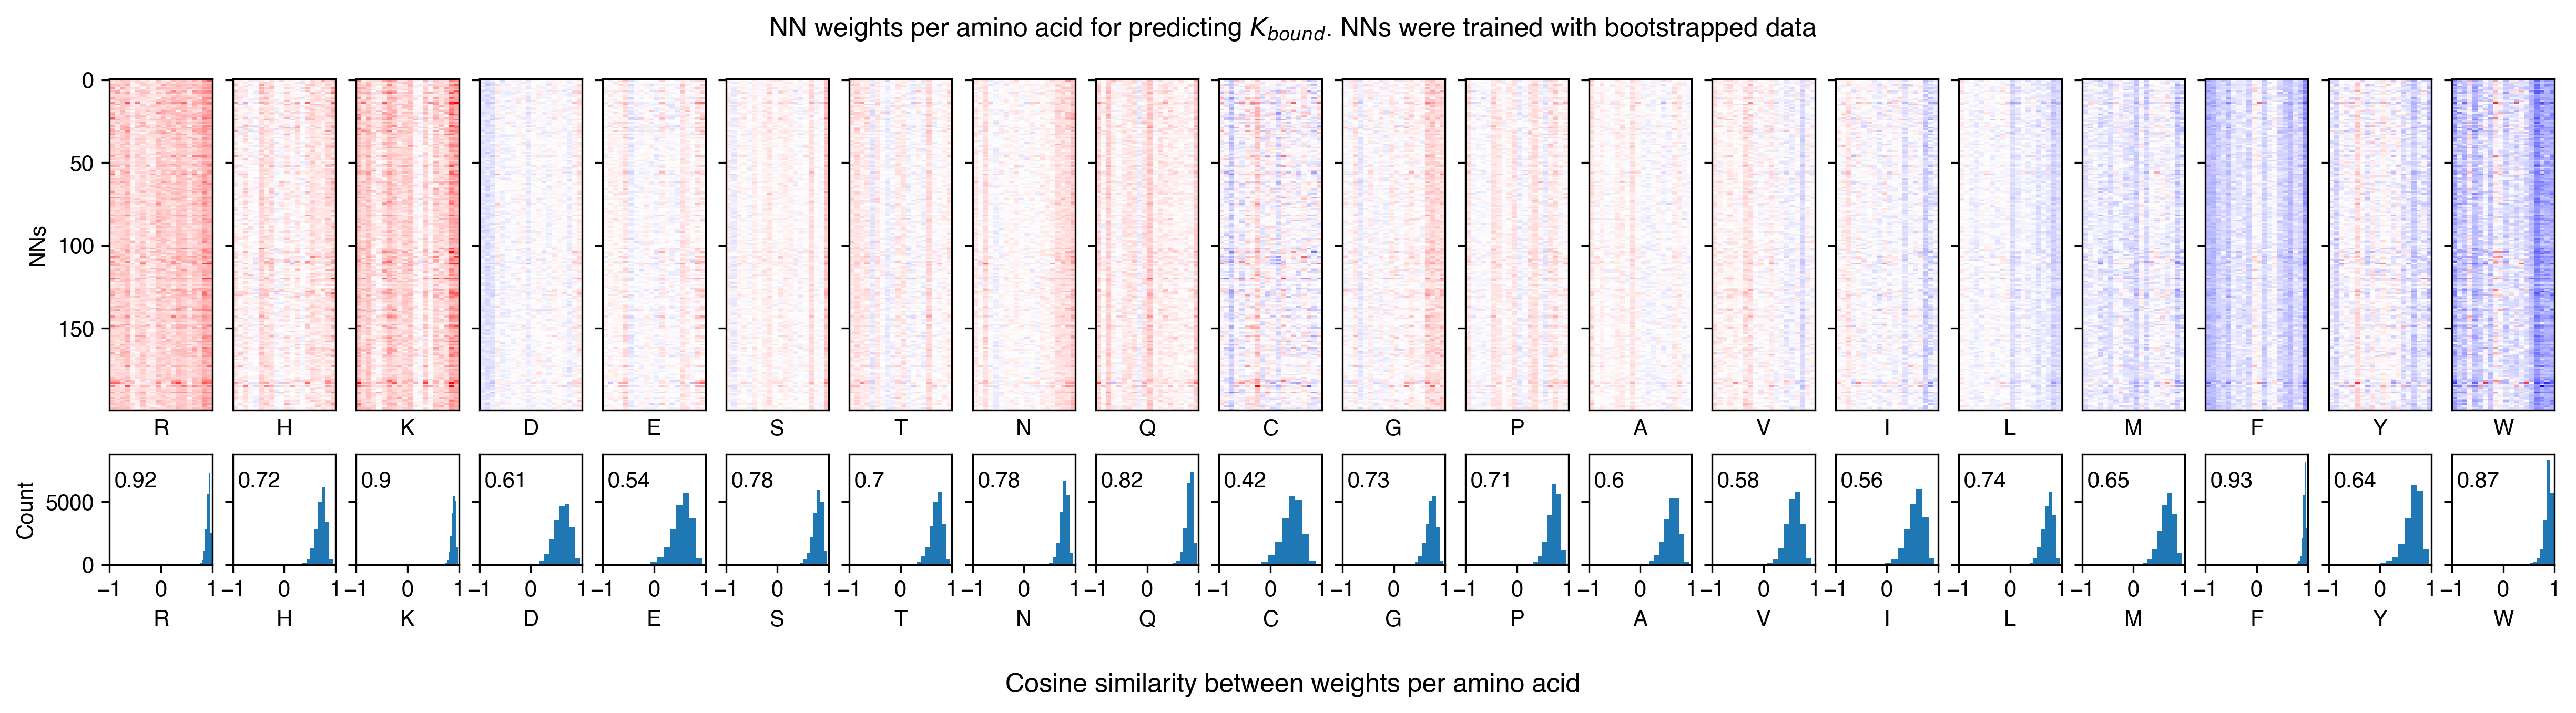

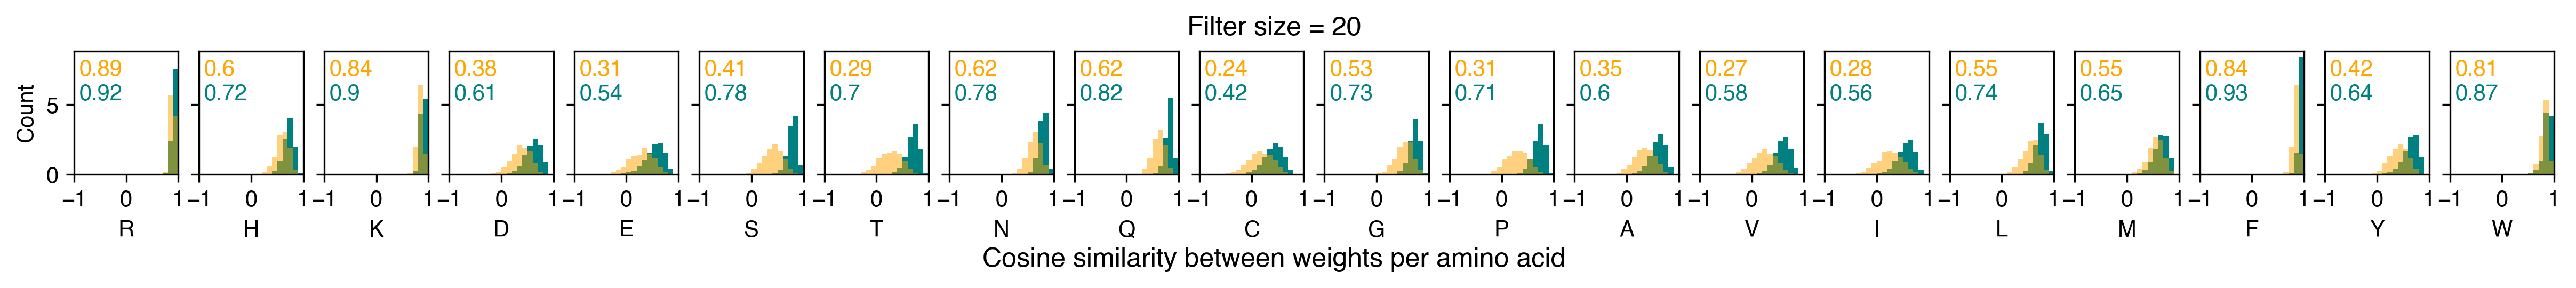

In [13]:
make_all_weight_heatmaps(20, model_results, bootstrap_results)

100%|██████████| 60/60 [00:00<00:00, 430.99it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
100%|██████████| 200/200 [00:00<00:00, 554.85it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


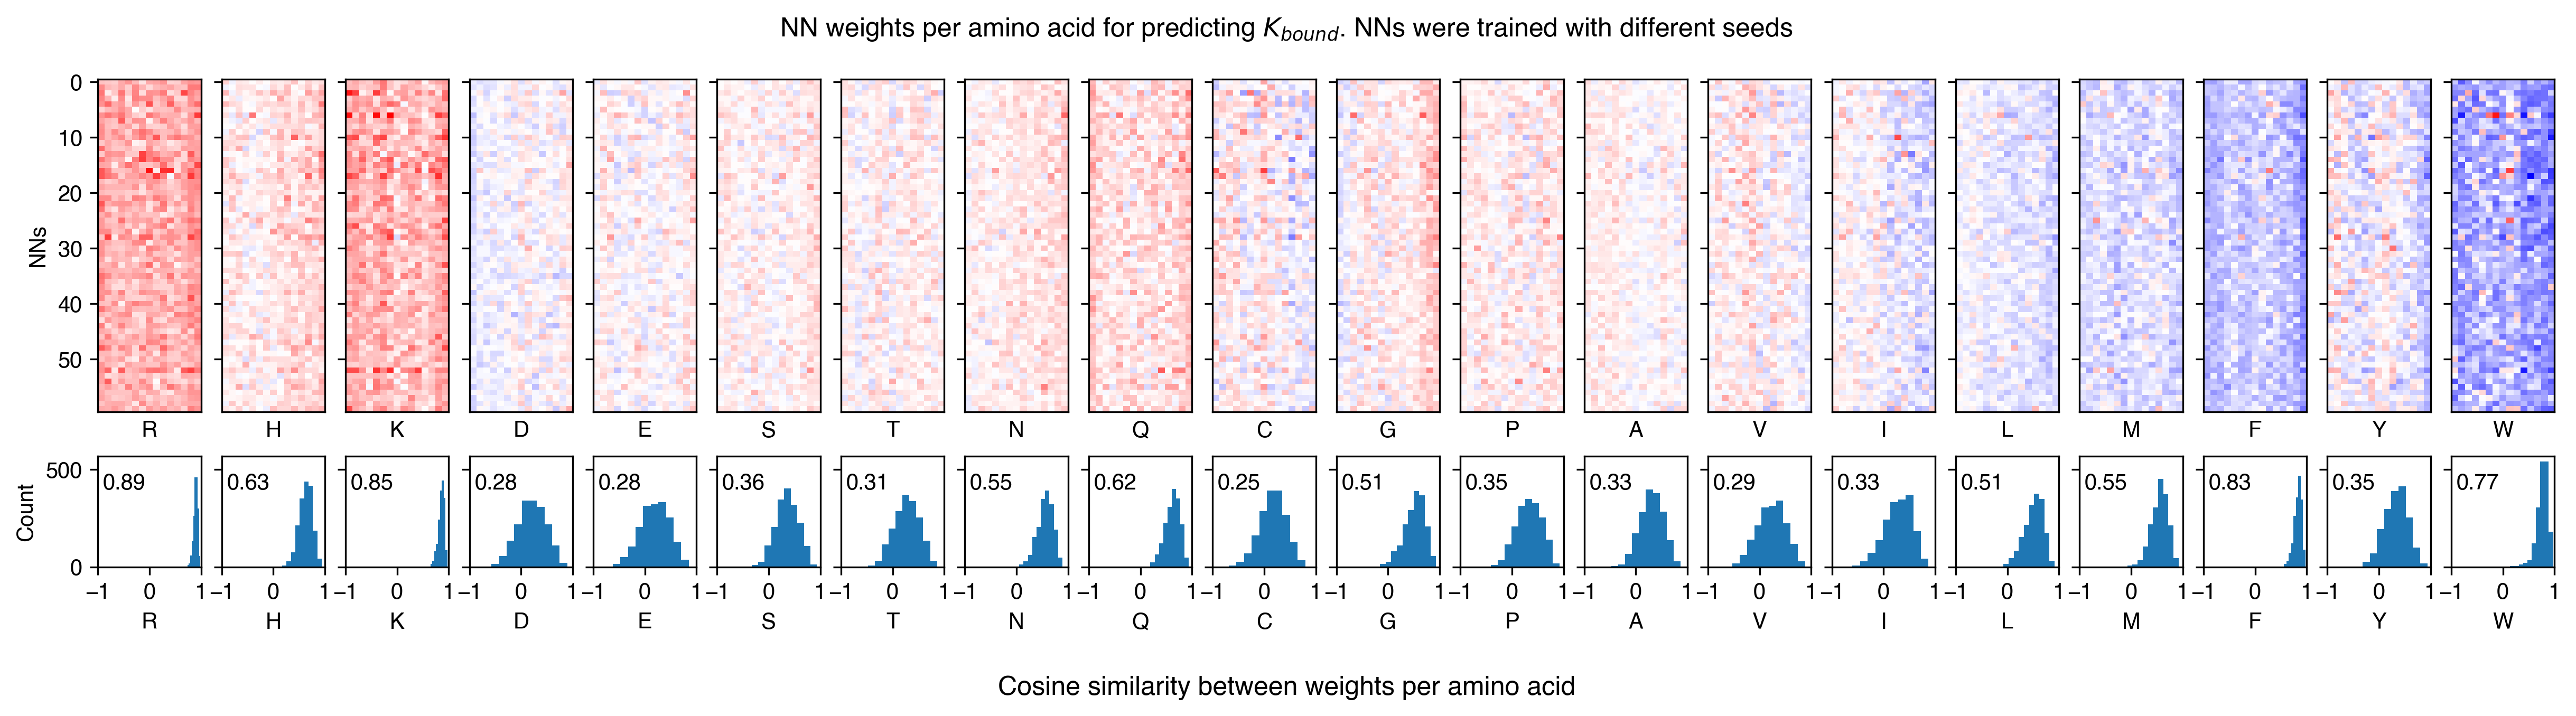

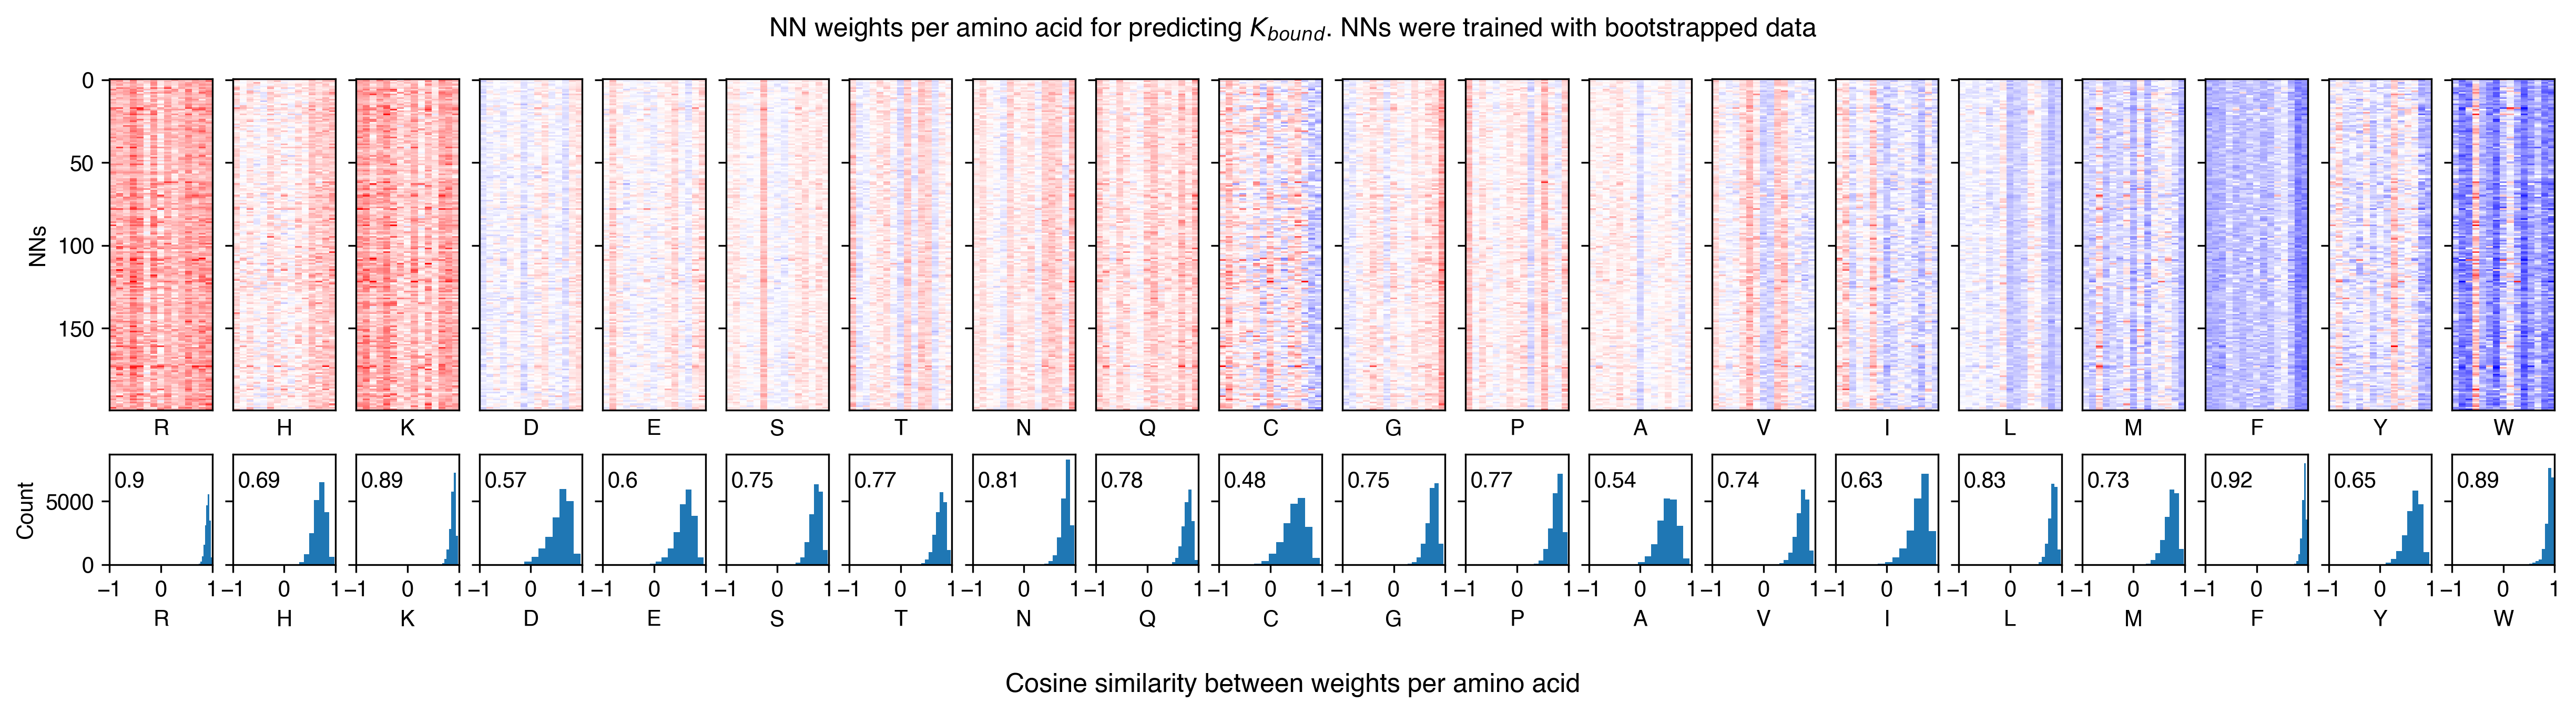

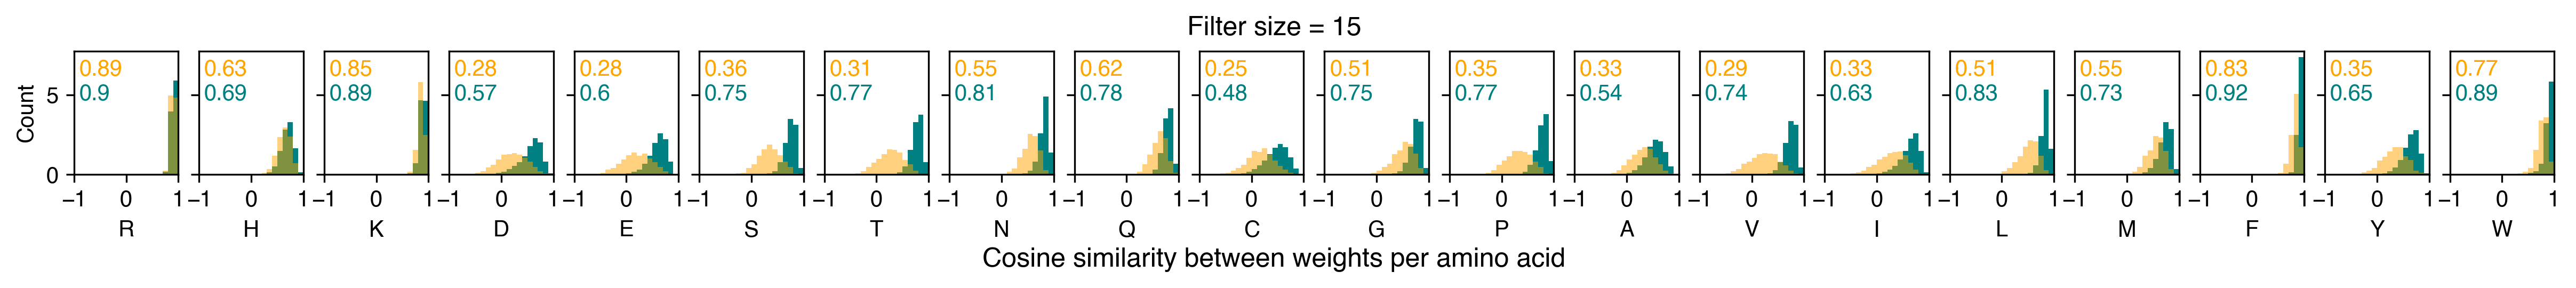

In [14]:
make_all_weight_heatmaps(15, model_results, bootstrap_results)

100%|██████████| 60/60 [00:00<00:00, 497.32it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
100%|██████████| 200/200 [00:00<00:00, 537.17it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


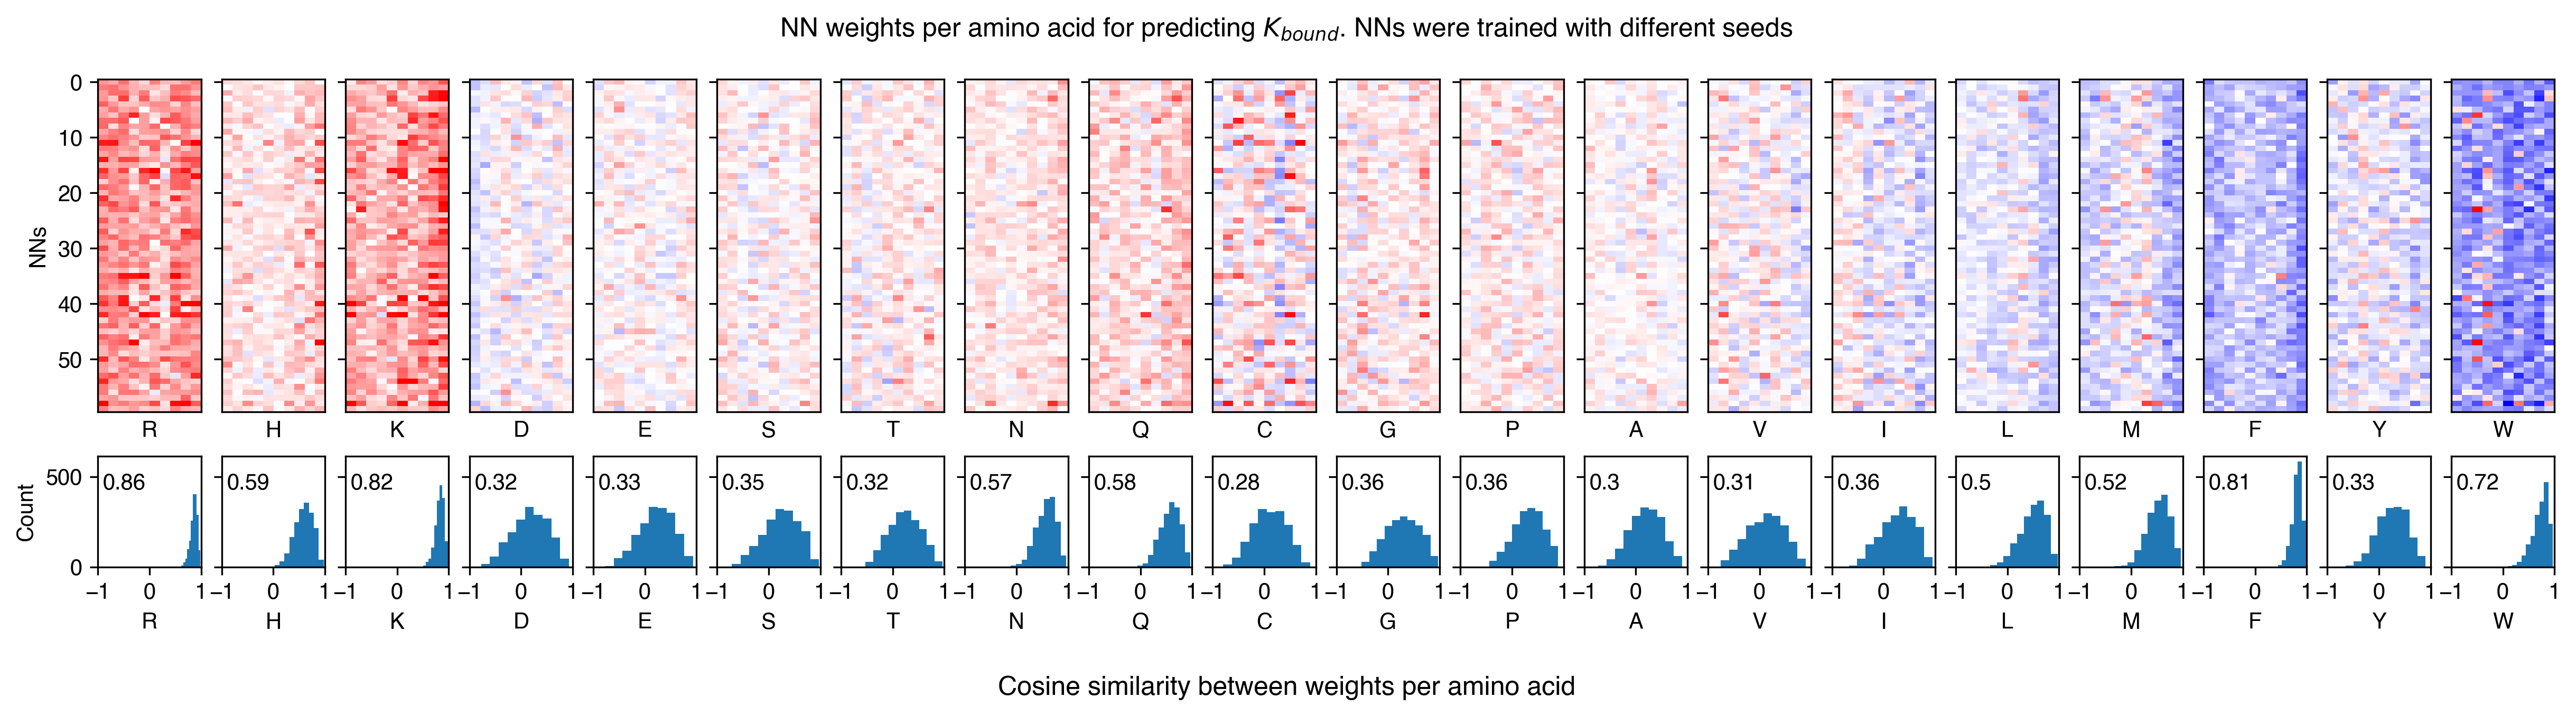

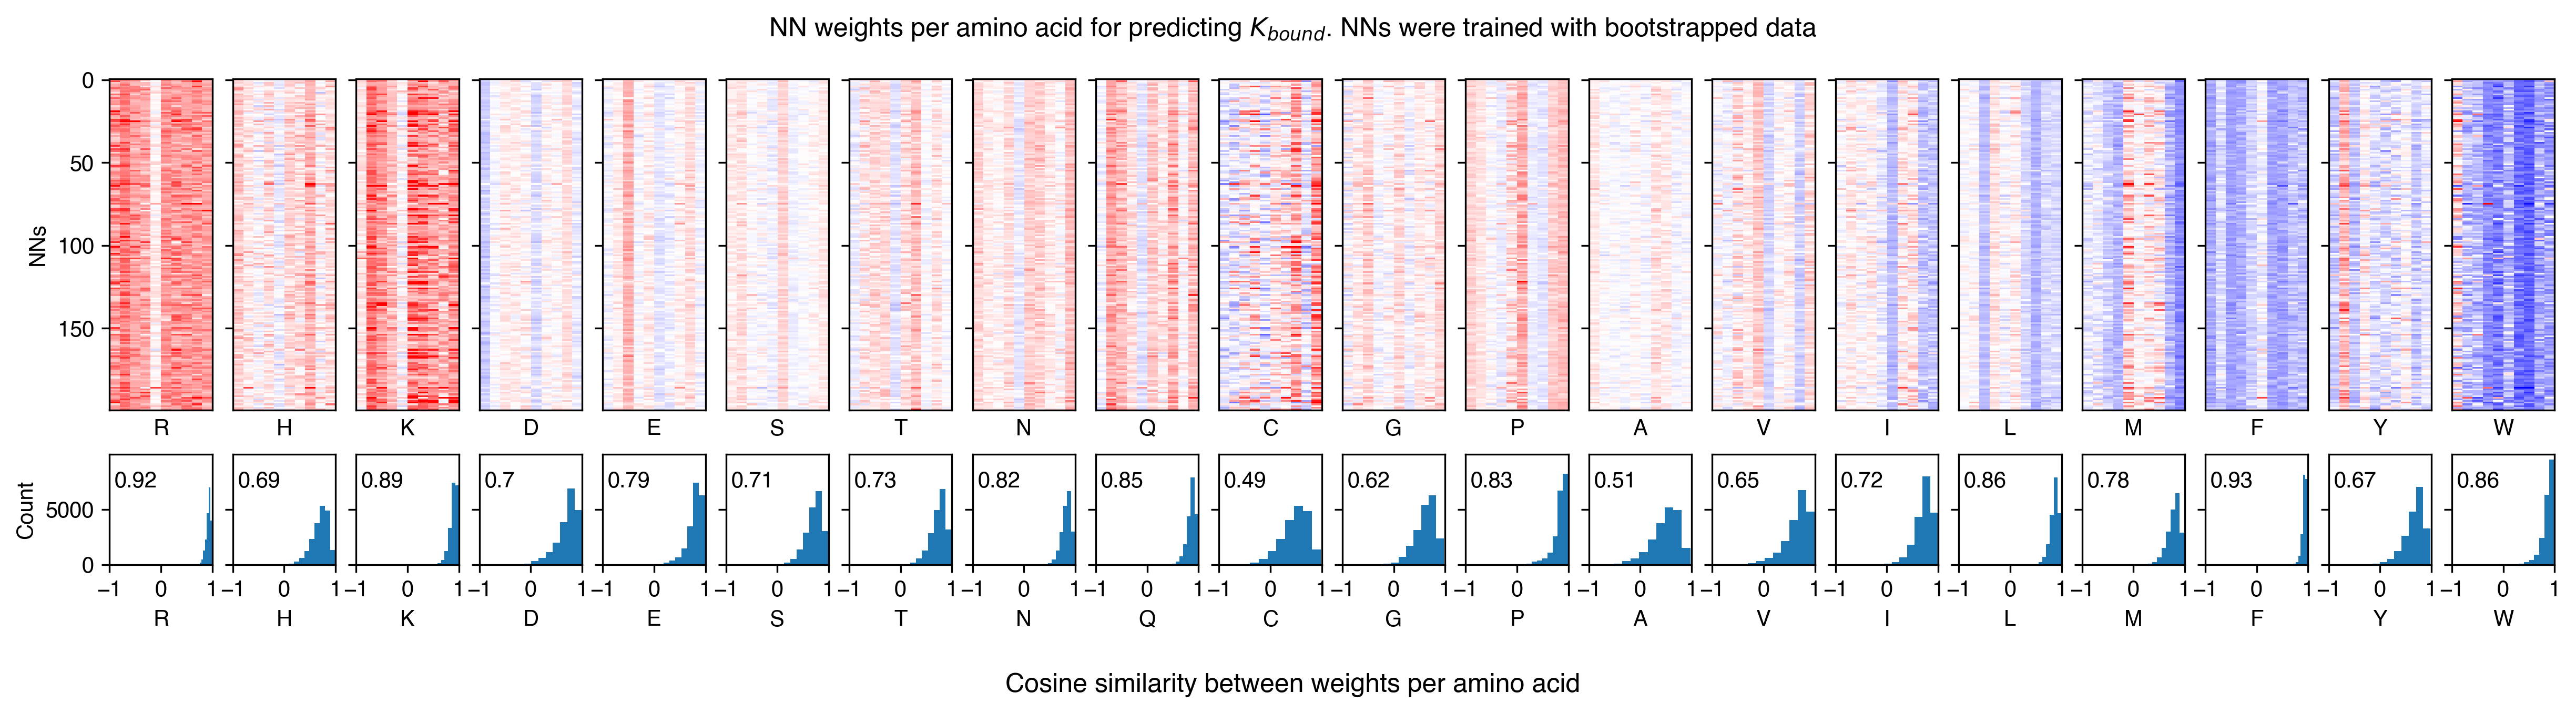

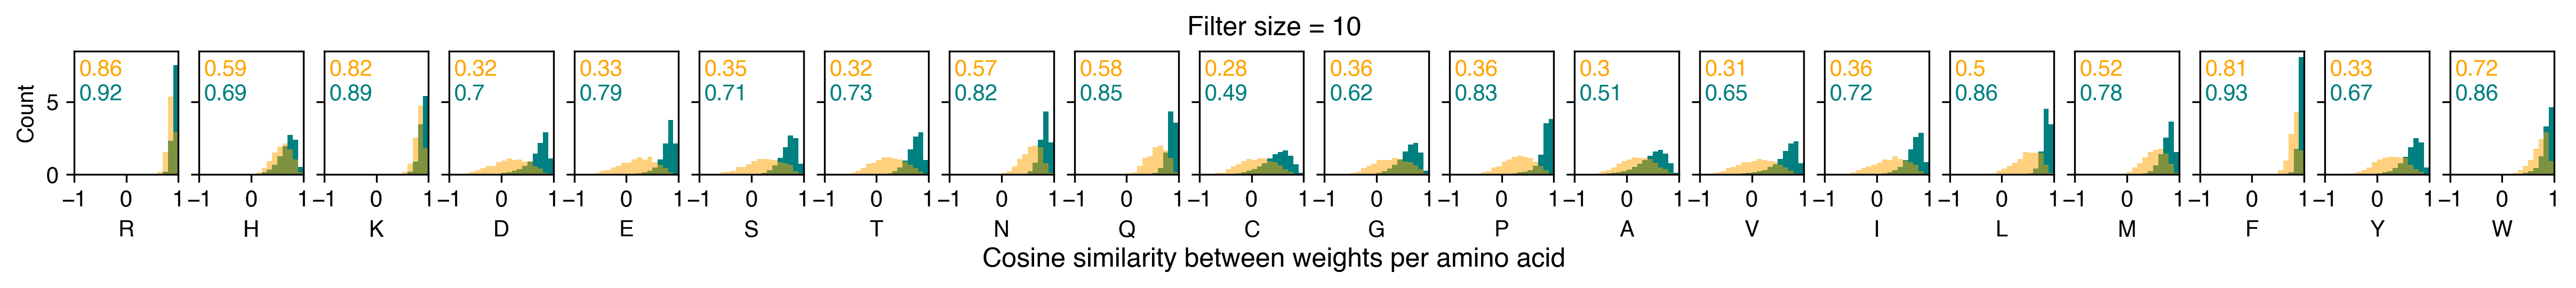

In [15]:
make_all_weight_heatmaps(10, model_results, bootstrap_results)

100%|██████████| 60/60 [00:00<00:00, 467.09it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
100%|██████████| 200/200 [00:00<00:00, 545.66it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


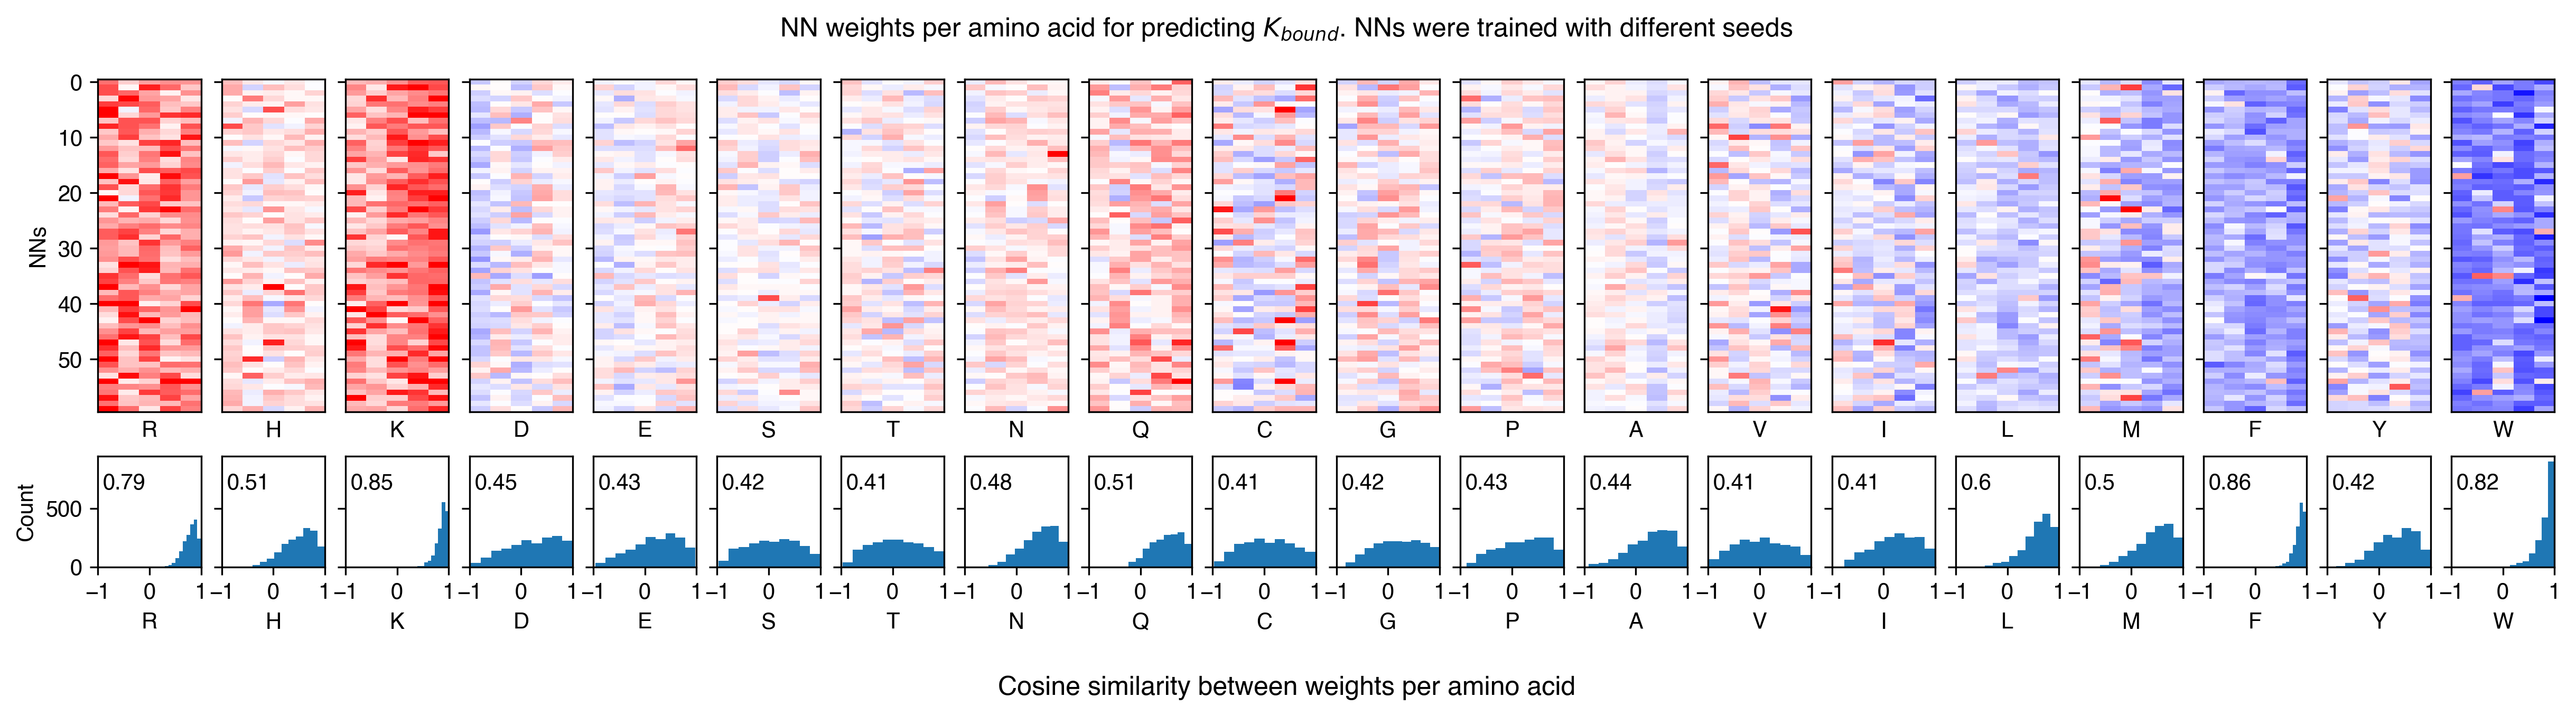

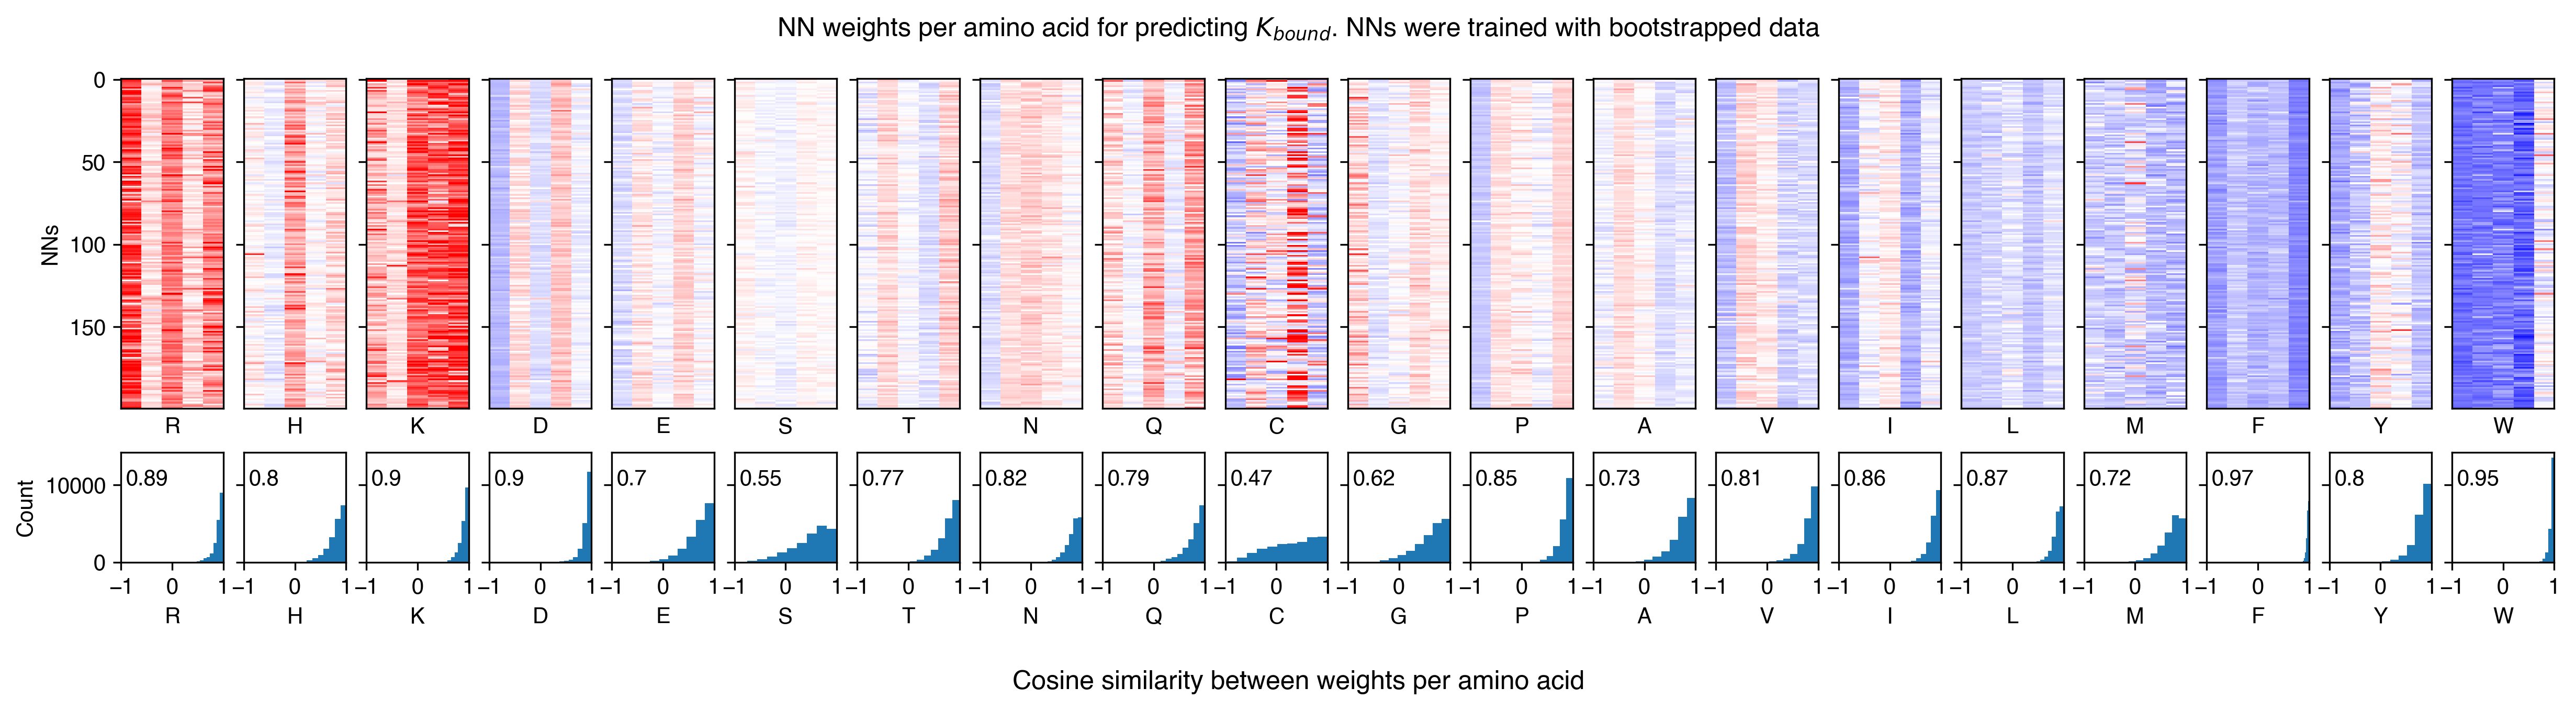

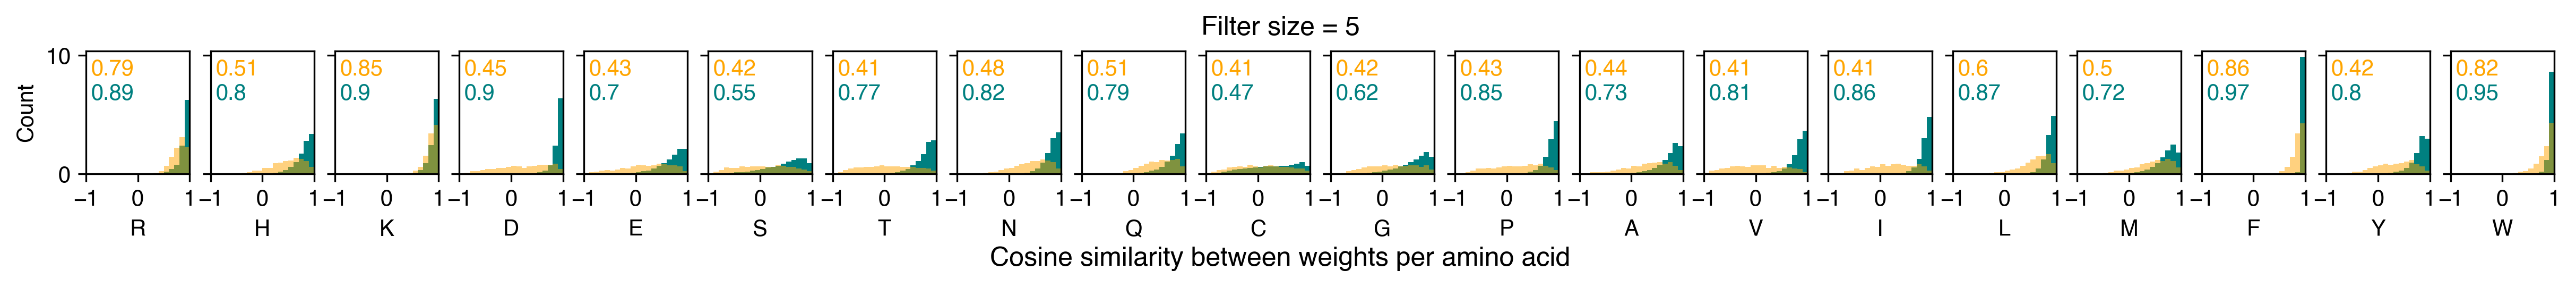

In [16]:
make_all_weight_heatmaps(5, model_results, bootstrap_results)